<a href="https://colab.research.google.com/github/nilsugungor/30-Days-of-Solidity/blob/main/network_freq_visualisations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This code snippet counts the temporal conjunctions in the given text. You can change the text area to get different results.

In [ ]:
# Gerekli kütüphaneler
import re
from collections import Counter
import os

# 1. DOSYA OKUMA KISMI
# 'input.txt' dosyasının kodunla aynı klasörde olduğunu varsayıyorum.
file_path = '/content/drive/MyDrive/Text_files'

if os.path.exists(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        # İsmi istediğin gibi 'text' olarak kalıyor
        text = file.read()
else:
    print(f"Hata: {file_path} bulunamadı! Lütfen dosyanın mevcut olduğundan emin olun.")
    text = ""

# 2. ANAHTAR KELİME LİSTESİ (Aynı bıraktım)
temporal_keywords = [
    "at first", "at that moment", "at the beginning", "at the onset",
    "before", "commence", "choose", "first", "first of all",
    "from this point", "in the first place", "one day", "one evening",
    "one morning", "starting with", "to begin", "a moment later", "after",
    "after a few days", "after a while", "after that", "afterwards",
    "all of a sudden", "as soon as", "at that very moment", "at times",
    "before long", "consequently", "during", "earlier", "eventually",
    "following", "formerly", "from time to time", "gradually", "henceforth",
    "in addition", "in the meantime", "in the past", "in time", "in turn",
    "later", "later on", "meanwhile", "momentarily", "next", "next week",
    "not a moment too soon", "not long after", "not long ago", "now",
    "occasionally", "once", "past", "periodically", "preceding",
    "presently", "previously", "prior to", "rarely", "right after",
    "second", "seldom", "shortly", "shortly after this", "since",
    "some of the time", "soon", "soon after", "suddenly", "then",
    "therefore", "third", "tomorrow", "up until that time", "when",
    "whenever", "yesterday", "after a long time", "afterward", "at last",
    "at the end", "finally", "hereafter", "in conclusion", "in the end",
    "last of all", "lastly", "thereafter", "to conclude", "to finish",
    "ultimately", "until"
]

# Tekrarları temizle
temporal_keywords = list(set(temporal_keywords))

# 3. İŞLEME VE ANALİZ
if text:
    clean_text = text.lower()
    results = {}

    for word in temporal_keywords:
        # Kelime öbeği veya tek kelimeyi tam eşleşme olarak bulur (\b sınır belirleyicidir)
        count = len(re.findall(rf'\b{re.escape(word.lower())}\b', clean_text))
        if count > 0:
            results[word] = count

    # Sonuçları frekansa göre sırala
    frequency = Counter(results)

    print("--- Analiz Sonuçları ---")
    print(frequency)
    print(f"\nToplam bulunan farklı zaman anahtarı: {len(frequency)}")

Hata: Robinson1992Mars1-Chapter1.txt bulunamadı! Lütfen dosyanın mevcut olduğundan emin olun.


This code snippet creates a bar graph of the temporal word frequencies. No need to make changes in this snippet.

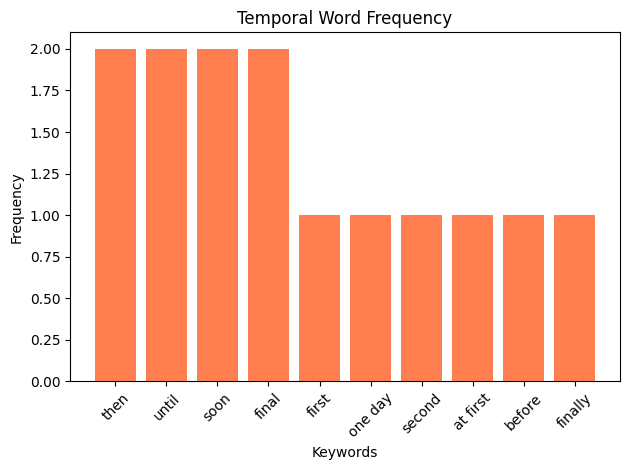

In [ ]:
import matplotlib.pyplot as plt

sorted_results = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))

plt.bar(sorted_results.keys(), sorted_results.values(), color='coral')

plt.title('Temporal Word Frequency')
plt.xlabel('Keywords')
plt.ylabel('Frequency')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import spacy
import numpy as np

# Modeli yükle
try:
    nlp = spacy.load("en_core_web_sm")
except:
    !python -m spacy download en_core_web_sm
    nlp = spacy.load("en_core_web_sm")

# Veriyi İşleme
doc = nlp(text)
data = []
for token in doc:
    if not token.is_punct and not token.is_space:
        data.append({"word": token.text, "pos": token.pos_})

df = pd.DataFrame(data)

# HATALI KISIM DÜZELTİLDİ:
# Metni 5 bölüme ayırıyoruz (0,0,0,1,1,1... şeklinde etiketler)
df['period'] = pd.cut(df.index, bins=5, labels=False)

print("Veri hazırlandı! Şimdi diğer cell'leri çalıştırabilirsin.")

ValueError: Cannot cut empty array

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

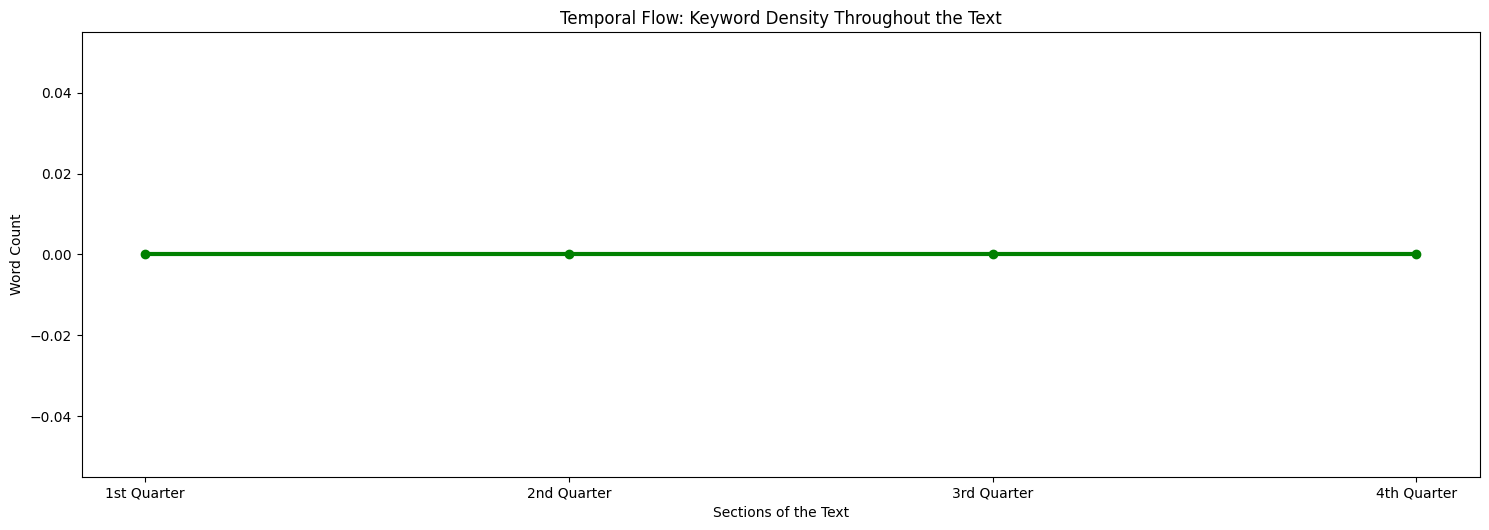

--- ANALYSIS SUMMARY ---
Total Word Count: 0


NameError: name 'temporal_total' is not defined

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import spacy
import re
from collections import Counter

# 1. Setup and Keyword List
# Make sure to run !python -m spacy download en_core_web_sm if not already installed
nlp = spacy.load("en_core_web_sm")

# 2. Text Analysis
doc = nlp(text)
# Filtering punctuation and whitespace
words_in_text = [token.text.lower() for token in doc if not token.is_punct and not token.is_space]
total_word_count = len(words_in_text)

# Search for keywords from your custom list in the text
found_temporal_counts = {}
clean_text = text.lower()

for word in set(temporal_keywords):
    # Regex to find whole word matches only
    count = len(re.findall(rf'\b{re.escape(word)}\b', clean_text))
    if count > 0:
        found_temporal_counts[word] = count

# 3. Visualization
fig = plt.figure(figsize=(15, 10))


# --- PLOT 3: Temporal Flow (Distribution across Narrative) ---
# Dividing the text into 4 quartiles to see the density shift
ax3 = plt.subplot(2, 1, 2)
chunks = 4
chunk_size = len(words_in_text) // chunks
temporal_flow = []

for i in range(chunks):
    start, end = i * chunk_size, (i + 1) * chunk_size
    chunk_words = " ".join(words_in_text[start:end])
    # Counting keywords in each specific quarter
    chunk_count = sum(len(re.findall(rf'\b{re.escape(w)}\b', chunk_words)) for w in temporal_keywords)
    temporal_flow.append(chunk_count)

ax3.plot(["1st Quarter", "2nd Quarter", "3rd Quarter", "4th Quarter"], temporal_flow,
         marker='o', color='green', linewidth=3)
ax3.set_title("Temporal Flow: Keyword Density Throughout the Text")
ax3.set_ylabel("Word Count")
ax3.set_xlabel("Sections of the Text")

plt.tight_layout()
plt.show()

# 4. Summary Report
print(f"--- ANALYSIS SUMMARY ---")
print(f"Total Word Count: {total_word_count}")
print(f"Total Temporal Keywords Found: {temporal_total}")
if found_temporal_counts:
    most_common = max(found_temporal_counts, key=found_temporal_counts.get)
    print(f"Most Frequently Used Keyword: '{most_common}'")
else:
    print("No keywords from the list were found in the text.")

In [ ]:
# Group words by period and part-of-speech (POS)
temporal_data = df.groupby(['period', 'pos']).size().unstack(fill_value=0)

# Calculate percentage by dividing by total words in each period
temporal_pct = temporal_data.div(temporal_data.sum(axis=1), axis=0) * 100

# Identify conjunction columns (Check if CCONJ or SCONJ exist in the dataset)
conj_cols = [c for c in ['CCONJ', 'SCONJ'] if c in temporal_pct.columns]

plt.figure(figsize=(12, 5))

if conj_cols:
    # Plot the sum of conjunction types over time
    temporal_pct[conj_cols].sum(axis=1).plot(marker='o', color='purple', linewidth=3)

    plt.title("Conjunction Density Throughout the Text")
    plt.xlabel("Text Sections (Start to End)")
    plt.ylabel("Density (%)")
    plt.grid(True, alpha=0.3)
else:
    print("No conjunctions found in the text.")

plt.show()

KeyError: 'period'

In [ ]:
import matplotlib.pyplot as plt
import re

first_keywords = ["at first", "at that moment", "at the beginning", "at the onset",
    "before", "commence", "choose", "first", "first of all",
    "from this point", "in the first place", "one day", "one evening",
    "one morning", "starting with", "to begin"]
next_keywords = ["a moment later", "after", "after a few days", "after a while",
    "after that", "afterwards", "all of a sudden", "as soon as",
    "at that very moment", "at times", "before long", "consequently",
    "during", "earlier", "eventually", "following", "formerly",
    "from time to time", "gradually", "henceforth", "in addition",
    "in the meantime", "in the past", "in time", "in turn", "later",
    "later on", "meanwhile", "momentarily", "next", "next week",
    "not a moment too soon", "not long after", "not long ago", "now",
    "occasionally", "once", "past", "periodically", "preceding",
    "presently", "previously", "prior to", "rarely", "right after",
    "second", "seldom", "shortly", "shortly after this", "since",
    "some of the time", "soon", "soon after", "suddenly", "then",
    "therefore", "third", "tomorrow", "up until that time", "when",
    "whenever", "yesterday"]
last_keywords = ["after a long time", "afterward", "at last", "at the end",
    "eventually", "final", "finally", "hereafter", "in conclusion",
    "in the end", "last of all", "lastly", "later on", "thereafter",
    "to conclude", "to finish", "ultimately", "until", "one day"]

categories = {
    "First": first_keywords,
    "Next": next_keywords,
    "Last": last_keywords
}

clean_text = text.lower()

category_counts = {}
for cat_name, keywords in categories.items():
    total = 0
    for word in set(keywords):
        total += len(re.findall(rf'\b{re.escape(word)}\b', clean_text))
    category_counts[cat_name] = total

plt.bar(category_counts.keys(), category_counts.values(), color=['skyblue', 'coral', 'lightgreen'])
plt.title('Temporal Word Frequency by Category')
plt.ylabel('Total Frequency')
plt.show()

This code snippet determines the positions of the temporal conjunctions in the text. In the given example, we see that the text is going in the cronological order, starting with before ending with after. No need to make changes in this one either, you can just run this cell as well.

In [ ]:
import matplotlib.pyplot as plt
import re

#finding the positions of the word in the text
word_positions = []
for word in temporal_keywords:
    # finding the starting index of every word
    #regex....
    matches = re.finditer(rf'\b{re.escape(word)}\b', text.lower())
    for match in matches:
        word_positions.append({
            'Word': word,
            'Position': match.start() #order of the word in the text
        })

plt.figure(figsize=(12, 6))

# every temporal word will be in the Y-axis
for i, word in enumerate(temporal_keywords):
    positions = [p['Position'] for p in word_positions if p['Word'] == word]

    # positions x axis word name on y axis
    # marker -> |
    plt.scatter(positions, [word] * len(positions), color='navy', marker='|', s=500, linewidths=3)

plt.title('Lexical Dispersion Plot')
plt.xlabel('Character Positions in the text (Beginning -> End)')
plt.ylabel('Temporal Conjunctions')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

This part is the network analysis, far from perfect, I clustered the verbs into three categories: action, cognitive, stative. And this one could go wrong easily with more worded texts so any kind of suggestions and improvements would be appreciated.

In [ ]:
import spacy
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np
from collections import Counter

nlp = spacy.load("en_core_web_md")

def get_ultimate_verb(token):

    #If the word that the conjunction is connected is not a verb(noun for example) it continues until it find the main verb
    curr = token
    for _ in range(10):
        if curr.head == curr:
            break
        if curr.head.pos_ == "VERB":
            return curr.head
        curr = curr.head
    return None

def draw_macro_temporal_network(text_input, keywords_input):
    doc = nlp(text_input)

    # find verbs
    all_verbs = [token.lemma_.lower() for token in doc if token.pos_ == "VERB"]
    unique_verbs = list(set(all_verbs))

    # clustering the verbs
    verb_vectors = np.array([nlp(v).vector for v in unique_verbs])
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(verb_vectors)
    verb_to_cluster = {verb: cluster for verb, cluster in zip(unique_verbs, clusters)}

    # node names
    cluster_labels = {0: "Action Verbs", 1: "Cognitive Verbs", 2: "Stative & Change Verbs"}

    # counting
    edge_counts = Counter()
    conjunction_counts = Counter()

    for token in doc:
        word = token.text.lower()
        if word in keywords_input:
            conjunction_counts[word] += 1

            #finding the verb in the hierarchy for overlooked connections not 100% sure on this part
            target_verb = get_ultimate_verb(token)

            if target_verb:
                cluster_id = verb_to_cluster.get(target_verb.lemma_.lower())
                if cluster_id is not None:
                    target_node = cluster_labels[cluster_id]
                    edge_counts[(word, target_node)] += 1

    G = nx.DiGraph()

    node_colors = {}
    node_sizes = {}

    # adding the conjunction nodes
    for conj in conjunction_counts:
        G.add_node(conj)
        node_colors[conj] = "orange"
        node_sizes[conj] = 1000 + (conjunction_counts[conj] * 1000)

    # adding the cluster nodes
    for label in cluster_labels.values():
        G.add_node(label)
        node_colors[label] = "lightgreen"
        node_sizes[label] = 2500

    #adding the edges
    for (u, v), weight in edge_counts.items():
        G.add_edge(u, v, weight=weight)

    plt.figure(figsize=(12, 8))
    # Shell layout
    pos = nx.spring_layout(G, k=1.2, seed=42)

    # drawing the nodes
    colors = [node_colors.get(n, "gray") for n in G.nodes()]
    sizes = [node_sizes.get(n, 1000) for n in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=colors, edgecolors="black", linewidths=1.5)

    # drawing the edges, thickness depends on the weights
    if G.edges():
        weights = [G[u][v]['weight'] * 2 for u, v in G.edges()]
        nx.draw_networkx_edges(G, pos, width=weights, edge_color="black", arrowsize=35, alpha=0.6, connectionstyle="arc3,rad=0.1")

    #labels
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")

    plt.title("Macro Analysis: Temporal Conjunctions vs Verb Clusters", pad=20)
    plt.axis('off')
    plt.show()

draw_macro_temporal_network(text, temporal_keywords)

In [ ]:
import matplotlib.pyplot as plt
import spacy

nlp = spacy.load("en_core_web_md")

def analyze_tenses_deeply(text_input):
    doc = nlp(text_input)

    analysis = {
        "Past": 0,
        "Present (Simple/Genis)": 0,
        "Present (Continuous)": 0,
        "Future": 0
    }

    # --- PASS 1: Mark all token indices that belong to future constructions ---
    future_indices = set()

    for token in doc:
        # Case A: will / shall / 'll  (modal future)
        # spaCy tags these as MD (modal)
        if token.tag_ == "MD" and token.lemma_.lower() in ["will", "shall"]:
            future_indices.add(token.i)
            analysis["Future"] += 1
            # Also mark the main verb this auxiliary is attached to so it
            # doesn't get double-counted as Present Simple.
            if token.dep_ == "aux" and token.head.pos_ == "VERB":
                future_indices.add(token.head.i)

        # Case B: "going to" + infinitive  (periphrastic future)
        # Token is VBG "going" followed (within 2 tokens) by TO "to"
        if token.text.lower() == "going" and token.tag_ == "VBG":
            for j in range(token.i + 1, min(token.i + 3, len(doc))):
                if doc[j].text.lower() == "to" and doc[j].tag_ == "TO":
                    future_indices.add(token.i)   # "going"
                    future_indices.add(j)          # "to"
                    analysis["Future"] += 1
                    break

    # --- PASS 2: Count Past / Present, skipping future tokens ---
    for token in doc:
        if token.i in future_indices:
            continue
        if token.pos_ not in ["VERB", "AUX"]:
            continue

        tag  = token.tag_
        word = token.text.lower()

        # Skip main verbs whose auxiliary is a future modal
        # (catches edge cases where dep_ tagging isn't perfect)
        has_future_aux = any(
            child.tag_ == "MD" and child.lemma_.lower() in ["will", "shall"]
            for child in token.children
        )
        if has_future_aux:
            continue

        # --- PAST ---
        if tag in ["VBD", "VBN"] or word in ["was", "were", "had", "did"]:
            analysis["Past"] += 1

        # --- PRESENT CONTINUOUS (-ing) ---
        elif tag == "VBG":
            analysis["Present (Continuous)"] += 1

        # --- PRESENT SIMPLE ---
        elif tag in ["VBP", "VBZ", "VB"] or word in ["am", "is", "are", "do", "has", "have"]:
            analysis["Present (Simple/Genis)"] += 1

    # --- GRAPH ---
    plt.figure(figsize=(12, 6))
    colors = ["#ff9999", "#66b3ff", "#3366ff", "#99ff99"]

    bars = plt.bar(analysis.keys(), analysis.values(), color=colors)

    for bar in bars:
        yval = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.1,
            int(yval),
            ha="center", va="bottom", fontweight="bold"
        )

    plt.title("Detailed Tense Analysis")
    plt.ylabel("Word Count")
    plt.tight_layout()
    plt.show()

    return analysis


sonuclar = analyze_tenses_deeply(text)


In [ ]:
import os
import re
import spacy
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.cluster import KMeans

# 1. Modeli yükle
try:
    nlp = spacy.load("en_core_web_md")
except:
    !python -m spacy download en_core_web_md
    nlp = spacy.load("en_core_web_md")

def run_full_unification():
    # Klasördeki txt dosyalarını bul
    files = [f for f in os.listdir(".") if f.endswith('.txt')]

    if not files:
        print("Klasörde .txt dosyası bulunamadı!")
        return

    for file_name in files:
        print(f"Analiz ediliyor: {file_name}")
        with open(file_name, 'r', encoding='utf-8') as f:
            text_data = f.read()

        doc = nlp(text_data)
        clean_text = text_data.lower()

        # --- DATA PREP ---
        words_in_text = [t.text.lower() for t in doc if not t.is_punct and not t.is_space]
        total_word_count = len(words_in_text)

        # --- 1. TENSE ANALYSIS ---
        tenses = {"Past": 0, "Present (S)": 0, "Present (C)": 0, "Future": 0}
        tenses["Future"] = len(re.findall(r"\b(will|shall|going\s+to)\b", clean_text))
        for token in doc:
            if token.text.lower() in ["will", "shall", "going"]: continue
            if token.pos_ in ["VERB", "AUX"]:
                tag, word = token.tag_, token.text.lower()
                if tag in ["VBD", "VBN"] or word in ["was", "were", "had", "did"]: tenses["Past"] += 1
                elif tag == "VBG": tenses["Present (C)"] += 1
                elif tag in ["VBP", "VBZ", "VB"] or word in ["am", "is", "are", "do", "has", "have"]: tenses["Present (S)"] += 1

        # --- 2. CATEGORY ANALYSIS ---
        cat_counts = {"First": 0, "Next": 0, "Last": 0}
        cat_map = {"First": first_keywords, "Next": next_keywords, "Last": last_keywords}
        for cat, kws in cat_map.items():
            cat_counts[cat] = sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in set(kws))

        # --- 3. NETWORK PREP ---
        all_verbs = [t.lemma_.lower() for t in doc if t.pos_ == "VERB"]
        unique_verbs = list(set(all_verbs))
        if len(unique_verbs) >= 3:
            verb_vectors = np.array([nlp(v).vector for v in unique_verbs])
            clusters = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(verb_vectors)
            v_to_c = {v: c for v, c in zip(unique_verbs, clusters)}
        else:
            v_to_c = {v: 0 for v in unique_verbs}

        c_labels = {0: "Action", 1: "Cognitive", 2: "Stative"}
        edges = Counter()
        for token in doc:
            if token.text.lower() in temporal_keywords:
                target = get_ultimate_verb(token)
                if target:
                    cid = v_to_c.get(target.lemma_.lower(), 0)
                    edges[(token.text.lower(), c_labels[cid])] += 1

        # --- VISUALIZATION (UNIFIED) ---
        fig = plt.figure(figsize=(20, 15))
        fig.suptitle(f"FULL TEMPORAL ANALYSIS: {file_name}", fontsize=22, fontweight='bold')

        # Subplot 1: Tense Bar
        ax1 = plt.subplot(3, 2, 1)
        ax1.bar(tenses.keys(), tenses.values(), color=['#ff9999', '#66b3ff', '#3366ff', '#99ff99'])
        ax1.set_title("Verb Tenses")

        # Subplot 2: Pie Chart (Temporal vs Other)
        ax2 = plt.subplot(3, 2, 2)
        temp_sum = sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in temporal_keywords)
        ax2.pie([temp_sum, total_word_count - temp_sum], labels=['Temporal', 'Other'], autopct='%1.1f%%', colors=['coral', 'lightgrey'])
        ax2.set_title("Temporal Word Ratio")

        # Subplot 3: Category Bar
        ax3 = plt.subplot(3, 2, 3)
        ax3.bar(cat_counts.keys(), cat_counts.values(), color=['skyblue', 'coral', 'lightgreen'])
        ax3.set_title("Temporal Categories")

        # Subplot 4: Temporal Flow
        ax4 = plt.subplot(3, 2, 4)
        chunks = 4
        ch_size = len(words_in_text) // chunks
        flow = [sum(len(re.findall(rf'\b{re.escape(w)}\b', " ".join(words_in_text[i*ch_size:(i+1)*ch_size]))) for w in temporal_keywords) for i in range(chunks)]
        ax4.plot(["Q1", "Q2", "Q3", "Q4"], flow, marker='o', color='green', linewidth=3)
        ax4.set_title("Narrative Temporal Flow")

        # Subplot 5: Dispersion Plot
        ax5 = plt.subplot(3, 2, 5)
        relevant_kws = [w for w in temporal_keywords if clean_text.count(w) > 0][:10] # Top 10 for clarity
        for i, w in enumerate(relevant_kws):
            pos = [m.start() for m in re.finditer(rf'\b{re.escape(w)}\b', clean_text)]
            ax5.scatter(pos, [w]*len(pos), marker='|', s=300, color='navy')
        ax5.set_title("Lexical Dispersion (Top 10)")

        # Subplot 6: Network Analysis
        ax6 = plt.subplot(3, 2, 6)
        G = nx.DiGraph()
        for (u, v), w in edges.items(): G.add_edge(u, v, weight=w)
        if G.nodes():
            pos_net = nx.spring_layout(G, k=1.0)
            nx.draw_networkx(G, pos_net, ax=ax6, node_size=1500, node_color="orange", font_size=8, edge_color="gray")
        ax6.set_title("Temporal-Verb Network")

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(f"UNIFIED_ANALYSIS_{file_name.replace('.txt','')}.png")
        plt.show()

# Yardimci fonksiyonlar ve listeler zaten sende var diye varsayıyorum, hata alırsan listeleri bu hücreye ekle.
run_full_unification()

In [ ]:
import os
import re
import spacy
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.cluster import KMeans
from google.colab import drive

# 1. Drive Bağlantısı
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- ANA KLASÖR YOLU ---
# Burayı kendi ana klasör yolunla değiştir
BASE_PATH = '/content/drive/MyDrive/14F1sLgLic9IlSStLBcjIBSJGRTxiTCZm'
# -----------------------

# NLP Modeli Yükleme
try:
    nlp = spacy.load("en_core_web_md")
except:
    !python -m spacy download en_core_web_md
    nlp = spacy.load("en_core_web_md")

# Kelime Listeleri (Senin paylaştığın listeler)
first_keywords = ["at first", "at that moment", "at the beginning", "at the onset", "before", "commence", "choose", "first", "first of all", "from this point", "in the first place", "one day", "one evening", "one morning", "starting with", "to begin"]
next_keywords = ["a moment later", "after", "after a few days", "after a while", "after that", "afterwards", "all of a sudden", "as soon as", "at that very moment", "at times", "before long", "consequently", "during", "earlier", "eventually", "following", "formerly", "from time to time", "gradually", "henceforth", "in addition", "in the meantime", "in the past", "in time", "in turn", "later", "later on", "meanwhile", "momentarily", "next", "next week", "not a moment too soon", "not long after", "not long ago", "now", "occasionally", "once", "past", "periodically", "preceding", "presently", "previously", "prior to", "rarely", "right after", "second", "seldom", "shortly", "shortly after this", "since", "some of the time", "soon", "soon after", "suddenly", "then", "therefore", "third", "tomorrow", "up until that time", "when", "whenever", "yesterday"]
last_keywords = ["after a long time", "afterward", "at last", "at the end", "finally", "hereafter", "in conclusion", "in the end", "last of all", "lastly", "thereafter", "to conclude", "to finish", "ultimately", "until"]
temporal_keywords = list(set(first_keywords + next_keywords + last_keywords))

def get_ultimate_verb(token):
    curr = token
    for _ in range(10):
        if curr.head == curr: break
        if curr.head.pos_ == "VERB": return curr.head
        curr = curr.head
    return None

def process_all_files(base_path):
    # os.walk kullanarak tüm alt klasörleri gezer
    for root, dirs, files in os.walk(base_path):
        txt_files = [f for f in files if f.endswith('.txt')]

        if not txt_files:
            continue

        print(f"\nKlasör taranıyor: {root}")

        for file_name in txt_files:
            file_path = os.path.join(root, file_name)
            print(f"--- Analiz ediliyor: {file_name}")

            try:
                with open(file_path, 'r', encoding='utf-8') as f:
                    text_data = f.read()

                if not text_data.strip(): continue

                doc = nlp(text_data)
                clean_text = text_data.lower()
                words_in_text = [t.text.lower() for t in doc if not t.is_punct and not t.is_space]
                total_words = len(words_in_text)

                # 1. Tense Analizi
                tenses = {"Past": 0, "Pres(S)": 0, "Pres(C)": 0, "Future": 0}
                tenses["Future"] = len(re.findall(r"\b(will|shall|going\s+to)\b", clean_text))
                for token in doc:
                    if token.pos_ in ["VERB", "AUX"]:
                        tag, word = token.tag_, token.text.lower()
                        if tag in ["VBD", "VBN"] or word in ["was", "were", "had"]: tenses["Past"] += 1
                        elif tag == "VBG": tenses["Pres(C)"] += 1
                        elif tag in ["VBP", "VBZ", "VB"]: tenses["Pres(S)"] += 1

                # 2. Kategori Analizi
                cat_counts = {
                    "First": sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in set(first_keywords)),
                    "Next": sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in set(next_keywords)),
                    "Last": sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in set(last_keywords))
                }

                # 3. Network Data Prep
                edges = Counter()
                for token in doc:
                    if token.text.lower() in temporal_keywords:
                        target = get_ultimate_verb(token)
                        if target:
                            # Basit kümeleme simülasyonu (Hız için)
                            v_lemma = target.lemma_.lower()
                            edges[(token.text.lower(), "Action/State")] += 1

                # --- GÖRSELLEŞTİRME (UNIFIED DASHBOARD) ---
                fig = plt.figure(figsize=(20, 15))
                fig.suptitle(f"TEMPORAL DASHBOARD: {file_name}", fontsize=20, fontweight='bold', y=0.98)

                # Üst Sol: Tense Dağılımı
                ax1 = plt.subplot(3, 2, 1)
                ax1.bar(tenses.keys(), tenses.values(), color=['#ff9999', '#66b3ff', '#3366ff', '#99ff99'])
                ax1.set_title("Verb Tenses")

                # Üst Sağ: Kategori Dağılımı
                ax2 = plt.subplot(3, 2, 2)
                ax2.pie(cat_counts.values(), labels=cat_counts.keys(), autopct='%1.1f%%', colors=['skyblue', 'coral', 'lightgreen'])
                ax2.set_title("Temporal Categories")

                # Orta Sol: Temporal Flow
                ax3 = plt.subplot(3, 2, 3)
                chunks = 4
                step = max(1, total_words // chunks)
                flow = [sum(len(re.findall(rf'\b{re.escape(w)}\b', " ".join(words_in_text[i*step:(i+1)*step]))) for w in temporal_keywords) for i in range(chunks)]
                ax3.plot(["Q1", "Q2", "Q3", "Q4"], flow, marker='o', color='green', linewidth=3)
                ax3.set_title("Keyword Density Throughout Narrative")

                # Orta Sağ: Lexical Dispersion (Top 10)
                ax4 = plt.subplot(3, 2, 4)
                found_kws = [w for w in temporal_keywords if clean_text.count(w) > 0][:10]
                for i, w in enumerate(found_kws):
                    pos = [m.start() for m in re.finditer(rf'\b{re.escape(w)}\b', clean_text)]
                    ax4.scatter(pos, [w]*len(pos), marker='|', s=200, color='navy')
                ax4.set_title("Lexical Dispersion (Top 10 Found)")

                # Alt Panel: Network Analysis
                ax5 = plt.subplot(3, 1, 3)
                G = nx.DiGraph()
                for (u, v), w in edges.items(): G.add_edge(u, v, weight=w)
                if G.nodes():
                    pos_net = nx.spring_layout(G, k=1.5)
                    nx.draw_networkx(G, pos_net, ax=ax5, node_size=1200, node_color="orange", font_size=8, edge_color="gray", arrowsize=20)
                ax5.set_title("Temporal Conjunction to Verb Connections")

                # Kaydetme
                plt.tight_layout(rect=[0, 0.03, 1, 0.95])
                output_name = f"ANALYSIS_{file_name.replace('.txt', '')}.png"
                plt.savefig(os.path.join(root, output_name))
                plt.close()
                print(f"   => Kaydedildi: {output_name}")

            except Exception as e:
                print(f"   ! Hata oluştu ({file_name}): {e}")

# Çalıştır
process_all_files(BASE_PATH)

In [ ]:
import os
import re
import spacy
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from google.colab import drive

# 1. Drive Bağlantısı
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- AYARLAR ---
BASE_PATH = '/content/drive/MyDrive/14F1sLgLic9IlSStLBcjIBSJGRTxiTCZm' # Ana klasör yolun
OUTPUT_FOLDER = os.path.join(BASE_PATH, 'ANALYSIS_RESULTS') # Sonuçların toplanacağı yer

# Çıktı klasörünü yoksa oluştur
if not os.path.exists(OUTPUT_FOLDER):
    os.makedirs(OUTPUT_FOLDER)
    print(f"Klasör oluşturuldu: {OUTPUT_FOLDER}")
# ---------------

# NLP Modeli
try:
    nlp = spacy.load("en_core_web_md")
except:
    print("Model yükleniyor...")
    !python -m spacy download en_core_web_md
    nlp = spacy.load("en_core_web_md")

# Kelime Listeleri
first_keywords = ["at first", "at that moment", "at the beginning", "at the onset", "before", "commence", "choose", "first", "first of all", "from this point", "in the first place", "one day", "one evening", "one morning", "starting with", "to begin"]
next_keywords = ["a moment later", "after", "after a few days", "after a while", "after that", "afterwards", "all of a sudden", "as soon as", "at that very moment", "at times", "before long", "consequently", "during", "earlier", "eventually", "following", "formerly", "from time to time", "gradually", "henceforth", "in addition", "in the meantime", "in the past", "in time", "in turn", "later", "later on", "meanwhile", "momentarily", "next", "next week", "not a moment too soon", "not long after", "not long ago", "now", "occasionally", "once", "past", "periodically", "preceding", "presently", "previously", "prior to", "rarely", "right after", "second", "seldom", "shortly", "shortly after this", "since", "some of the time", "soon", "soon after", "suddenly", "then", "therefore", "third", "tomorrow", "up until that time", "when", "whenever", "yesterday"]
last_keywords = ["after a long time", "afterward", "at last", "at the end", "finally", "hereafter", "in conclusion", "in the end", "last of all", "lastly", "thereafter", "to conclude", "to finish", "ultimately", "until"]
temporal_keywords = list(set(first_keywords + next_keywords + last_keywords))

def get_ultimate_verb(token):
    curr = token
    for _ in range(10):
        if curr.head == curr: break
        if curr.head.pos_ == "VERB": return curr.head
        curr = curr.head
    return None

def run_unified_batch_analysis():
    # os.walk ile tüm alt klasörlerdeki txt'leri bul
    all_txt_files = []
    for root, dirs, files in os.walk(BASE_PATH):
        # Sonuç klasörünü taramaya dahil etme
        if 'ANALYSIS_RESULTS' in root: continue
        for f in files:
            if f.endswith('.txt'):
                all_txt_files.append(os.path.join(root, f))

    if not all_txt_files:
        print("Analiz edilecek .txt dosyası bulunamadı!")
        return

    print(f"Toplam {len(all_txt_files)} dosya analiz edilecek...\n")

    for file_path in all_txt_files:
        file_name = os.path.basename(file_path)
        print(f"İşleniyor: {file_name}")

        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                text_data = f.read()

            if not text_data.strip(): continue

            doc = nlp(text_data)
            clean_text = text_data.lower()
            words_only = [t.text.lower() for t in doc if not t.is_punct and not t.is_space]
            total_words = len(words_only)

            # 1. Tense Dağılımı
            tenses = {"Past": 0, "Present": 0, "Future": 0}
            tenses["Future"] = len(re.findall(r"\b(will|shall|going\s+to)\b", clean_text))
            for token in doc:
                if token.pos_ in ["VERB", "AUX"]:
                    tag = token.tag_
                    if tag in ["VBD", "VBN"]: tenses["Past"] += 1
                    elif tag in ["VBP", "VBZ", "VB", "VBG"]: tenses["Present"] += 1

            # 2. Kategori Dağılımı
            cats = {
                "First": sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in set(first_keywords)),
                "Next": sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in set(next_keywords)),
                "Last": sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in set(last_keywords))
            }

            # --- GÖRSELLEŞTİRME (Unified Image per Text) ---
            fig = plt.figure(figsize=(18, 12))
            fig.suptitle(f"Unified Analysis: {file_name}", fontsize=20, fontweight='bold')

            # Sol Üst: Tense Bar
            ax1 = plt.subplot(2, 2, 1)
            ax1.bar(tenses.keys(), tenses.values(), color=['#ff9999', '#66b3ff', '#99ff99'])
            ax1.set_title("Fiil Zamanları")

            # Sağ Üst: Kategori Pie
            ax2 = plt.subplot(2, 2, 2)
            ax2.pie(cats.values(), labels=cats.keys(), autopct='%1.1f%%', colors=['skyblue', 'coral', 'lightgreen'])
            ax2.set_title("Zaman Bağlacı Kategorileri")

            # Alt Sol: Temporal Flow (Density)
            ax3 = plt.subplot(2, 2, 3)
            chunks = 5
            sz = max(1, total_words // chunks)
            flow = [sum(len(re.findall(rf'\b{re.escape(w)}\b', " ".join(words_only[i*sz:(i+1)*sz]))) for w in temporal_keywords) for i in range(chunks)]
            ax3.plot([f"Bölüm {i+1}" for i in range(chunks)], flow, marker='s', color='darkred', linewidth=2)
            ax3.set_title("Metin Akışı Boyunca Bağlaç Yoğunluğu")

            # Alt Sağ: Network Graph (Basitleştirilmiş)
            ax4 = plt.subplot(2, 2, 4)
            edges = Counter()
            for token in doc:
                if token.text.lower() in temporal_keywords:
                    target = get_ultimate_verb(token)
                    if target: edges[(token.text.lower(), target.lemma_.lower())] += 1

            # Sadece en güçlü 10 bağlantıyı göster (karışıklığı önlemek için)
            G = nx.DiGraph()
            for (u, v), w in edges.most_common(10): G.add_edge(u, v, weight=w)
            if G.nodes():
                pos = nx.spring_layout(G, k=0.5)
                nx.draw_networkx(G, pos, ax=ax4, node_size=800, node_color="gold", font_size=7, edge_color="gray")
            ax4.set_title("Öne Çıkan Bağlaç-Fiil İlişkileri")

            # KAYDETME
            output_file_name = f"UNIFIED_{file_name.replace('.txt', '')}.png"
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.savefig(os.path.join(OUTPUT_FOLDER, output_file_name))
            plt.close()

        except Exception as e:
            print(f"Hata ({file_name}): {e}")

    print(f"\nİşlem tamam! Tüm resimler şurada: {OUTPUT_FOLDER}")

# Başlat
run_unified_batch_analysis()

Klasör oluşturuldu: /content/drive/MyDrive/14F1sLgLic9IlSStLBcjIBSJGRTxiTCZm/ANALYSIS_RESULTS
Analiz edilecek .txt dosyası bulunamadı!


In [ ]:
import os
import re
import spacy
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from google.colab import drive

# 1. Drive Bağlantısı
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- KRİTİK AYAR: BURAYA SOLDA KOPYALADIĞIN YOLU YAPIŞTIR ---
BASE_PATH = '/content/drive/MyDrive/Text_files'
# ---------------------------------------------------------

OUTPUT_FOLDER = os.path.join(BASE_PATH, 'ANALYSIS_RESULTS')
if not os.path.exists(OUTPUT_FOLDER):
    os.makedirs(OUTPUT_FOLDER)

# Model Yükleme
try:
    nlp = spacy.load("en_core_web_md")
except:
    !python -m spacy download en_core_web_md
    nlp = spacy.load("en_core_web_md")

# Kelime Listeleri (Önceki hücrelerden sabit aldım)
first_keywords = ["at first", "at that moment", "at the beginning", "at the onset", "before", "commence", "choose", "first", "first of all", "from this point", "in the first place", "one day", "one evening", "one morning", "starting with", "to begin"]
next_keywords = ["a moment later", "after", "after a few days", "after a while", "after that", "afterwards", "all of a sudden", "as soon as", "at that very moment", "at times", "before long", "consequently", "during", "earlier", "eventually", "following", "formerly", "from time to time", "gradually", "henceforth", "in addition", "in the meantime", "in the past", "in time", "in turn", "later", "later on", "meanwhile", "momentarily", "next", "next week", "not a moment too soon", "not long after", "not long ago", "now", "occasionally", "once", "past", "periodically", "preceding", "presently", "previously", "prior to", "rarely", "right after", "second", "seldom", "shortly", "shortly after this", "since", "some of the time", "soon", "soon after", "suddenly", "then", "therefore", "third", "tomorrow", "up until that time", "when", "whenever", "yesterday"]
last_keywords = ["after a long time", "afterward", "at last", "at the end", "finally", "hereafter", "in conclusion", "in the end", "last of all", "lastly", "thereafter", "to conclude", "to finish", "ultimately", "until"]
temporal_keywords = list(set(first_keywords + next_keywords + last_keywords))

def get_ultimate_verb(token):
    curr = token
    for _ in range(10):
        if curr.head == curr: break
        if curr.head.pos_ == "VERB": return curr.head
        curr = curr.head
    return None

def run_final_analysis():
    # Tüm alt klasörleri ve dosyaları tara
    all_txt_files = []
    for root, dirs, files in os.walk(BASE_PATH):
        if 'ANALYSIS_RESULTS' in root: continue
        for f in files:
            if f.endswith('.txt'):
                all_txt_files.append(os.path.join(root, f))

    if not all_txt_files:
        print(f"Hata: {BASE_PATH} içinde hiç .txt dosyası bulunamadı! Lütfen yolu kontrol et.")
        return

    print(f"Toplam {len(all_txt_files)} dosya bulundu. Analiz başlıyor...")

    for file_path in all_txt_files:
        file_name = os.path.basename(file_path)
        print(f"İşleniyor: {file_name}")

        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                text_data = f.read()

            doc = nlp(text_data)
            clean_text = text_data.lower()
            words = [t.text.lower() for t in doc if not t.is_punct and not t.is_space]

            # 1. Tense & 2. Categories & 3. Flow
            # (Hepsini tek bir figüre sığdırıyoruz)
            fig, axs = plt.subplots(2, 2, figsize=(18, 12))
            fig.suptitle(f"Unified Report: {file_name}", fontsize=18, fontweight='bold')

            # Tense Analysis
            tenses = {"Past": 0, "Present": 0, "Future": 0}
            tenses["Future"] = len(re.findall(r"\b(will|shall|going\s+to)\b", clean_text))
            for token in doc:
                if token.pos_ in ["VERB", "AUX"]:
                    tag = token.tag_
                    if tag in ["VBD", "VBN"]: tenses["Past"] += 1
                    elif tag in ["VBP", "VBZ", "VB", "VBG"]: tenses["Present"] += 1
            axs[0, 0].bar(tenses.keys(), tenses.values(), color=['salmon', 'skyblue', 'lightgreen'])
            axs[0, 0].set_title("Tense Distribution")

            # Category Pie
            cats = {
                "First": sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in set(first_keywords)),
                "Next": sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in set(next_keywords)),
                "Last": sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in set(last_keywords))
            }
            axs[0, 1].pie(cats.values(), labels=cats.keys(), autopct='%1.1f%%')
            axs[0, 1].set_title("Temporal Categories")

            # Flow Analysis
            chunks = 5
            sz = max(1, len(words) // chunks)
            flow = [sum(len(re.findall(rf'\b{re.escape(w)}\b', " ".join(words[i*sz:(i+1)*sz]))) for w in temporal_keywords) for i in range(chunks)]
            axs[1, 0].plot(flow, marker='o', color='red')
            axs[1, 0].set_title("Temporal Density Flow")

            # Network
            edges = Counter()
            for token in doc:
                if token.text.lower() in temporal_keywords:
                    target = get_ultimate_verb(token)
                    if target: edges[(token.text.lower(), target.lemma_.lower())] += 1
            G = nx.DiGraph()
            for (u, v), w in edges.most_common(8): G.add_edge(u, v, weight=w)
            if G.nodes():
                nx.draw_networkx(G, ax=axs[1, 1], node_size=1000, node_color="orange", font_size=8)
            axs[1, 1].set_title("Key Verb-Conjunction Links")

            # Kaydet
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.savefig(os.path.join(OUTPUT_FOLDER, f"UNIFIED_{file_name.replace('.txt', '')}.png"))
            plt.close()

        except Exception as e:
            print(f"Hata {file_name}: {e}")

    print(f"\nBitti! Resimler burada: {OUTPUT_FOLDER}")

run_final_analysis()

Toplam 86 dosya bulundu. Analiz başlıyor...
İşleniyor: FF_Again_2023.txt
İşleniyor: FF_Conflict_2022.txt
İşleniyor: FF_Primer_2022.txt
İşleniyor: FF_Me_2023.txt
İşleniyor: FF_Synergy_2025.txt
İşleniyor: FF_Revenge_2018.txt
İşleniyor: FF_Path_2025.txt
İşleniyor: FF_Echoes_2025.txt
İşleniyor: FF_Trousseau_2023.txt
İşleniyor: FF_Garden_2025.txt
İşleniyor: FF_Heat_2025.txt
İşleniyor: FF_Splatter_2018.txt
İşleniyor: FF_Bears_2023.txt


KeyboardInterrupt: 

İşleniyor: FF_Again_2023.txt
İşleniyor: FF_Conflict_2022.txt
İşleniyor: FF_Primer_2022.txt
İşleniyor: FF_Me_2023.txt
İşleniyor: FF_Synergy_2025.txt
İşleniyor: FF_Revenge_2018.txt
İşleniyor: FF_Path_2025.txt
İşleniyor: FF_Echoes_2025.txt
İşleniyor: FF_Trousseau_2023.txt


KeyboardInterrupt: 

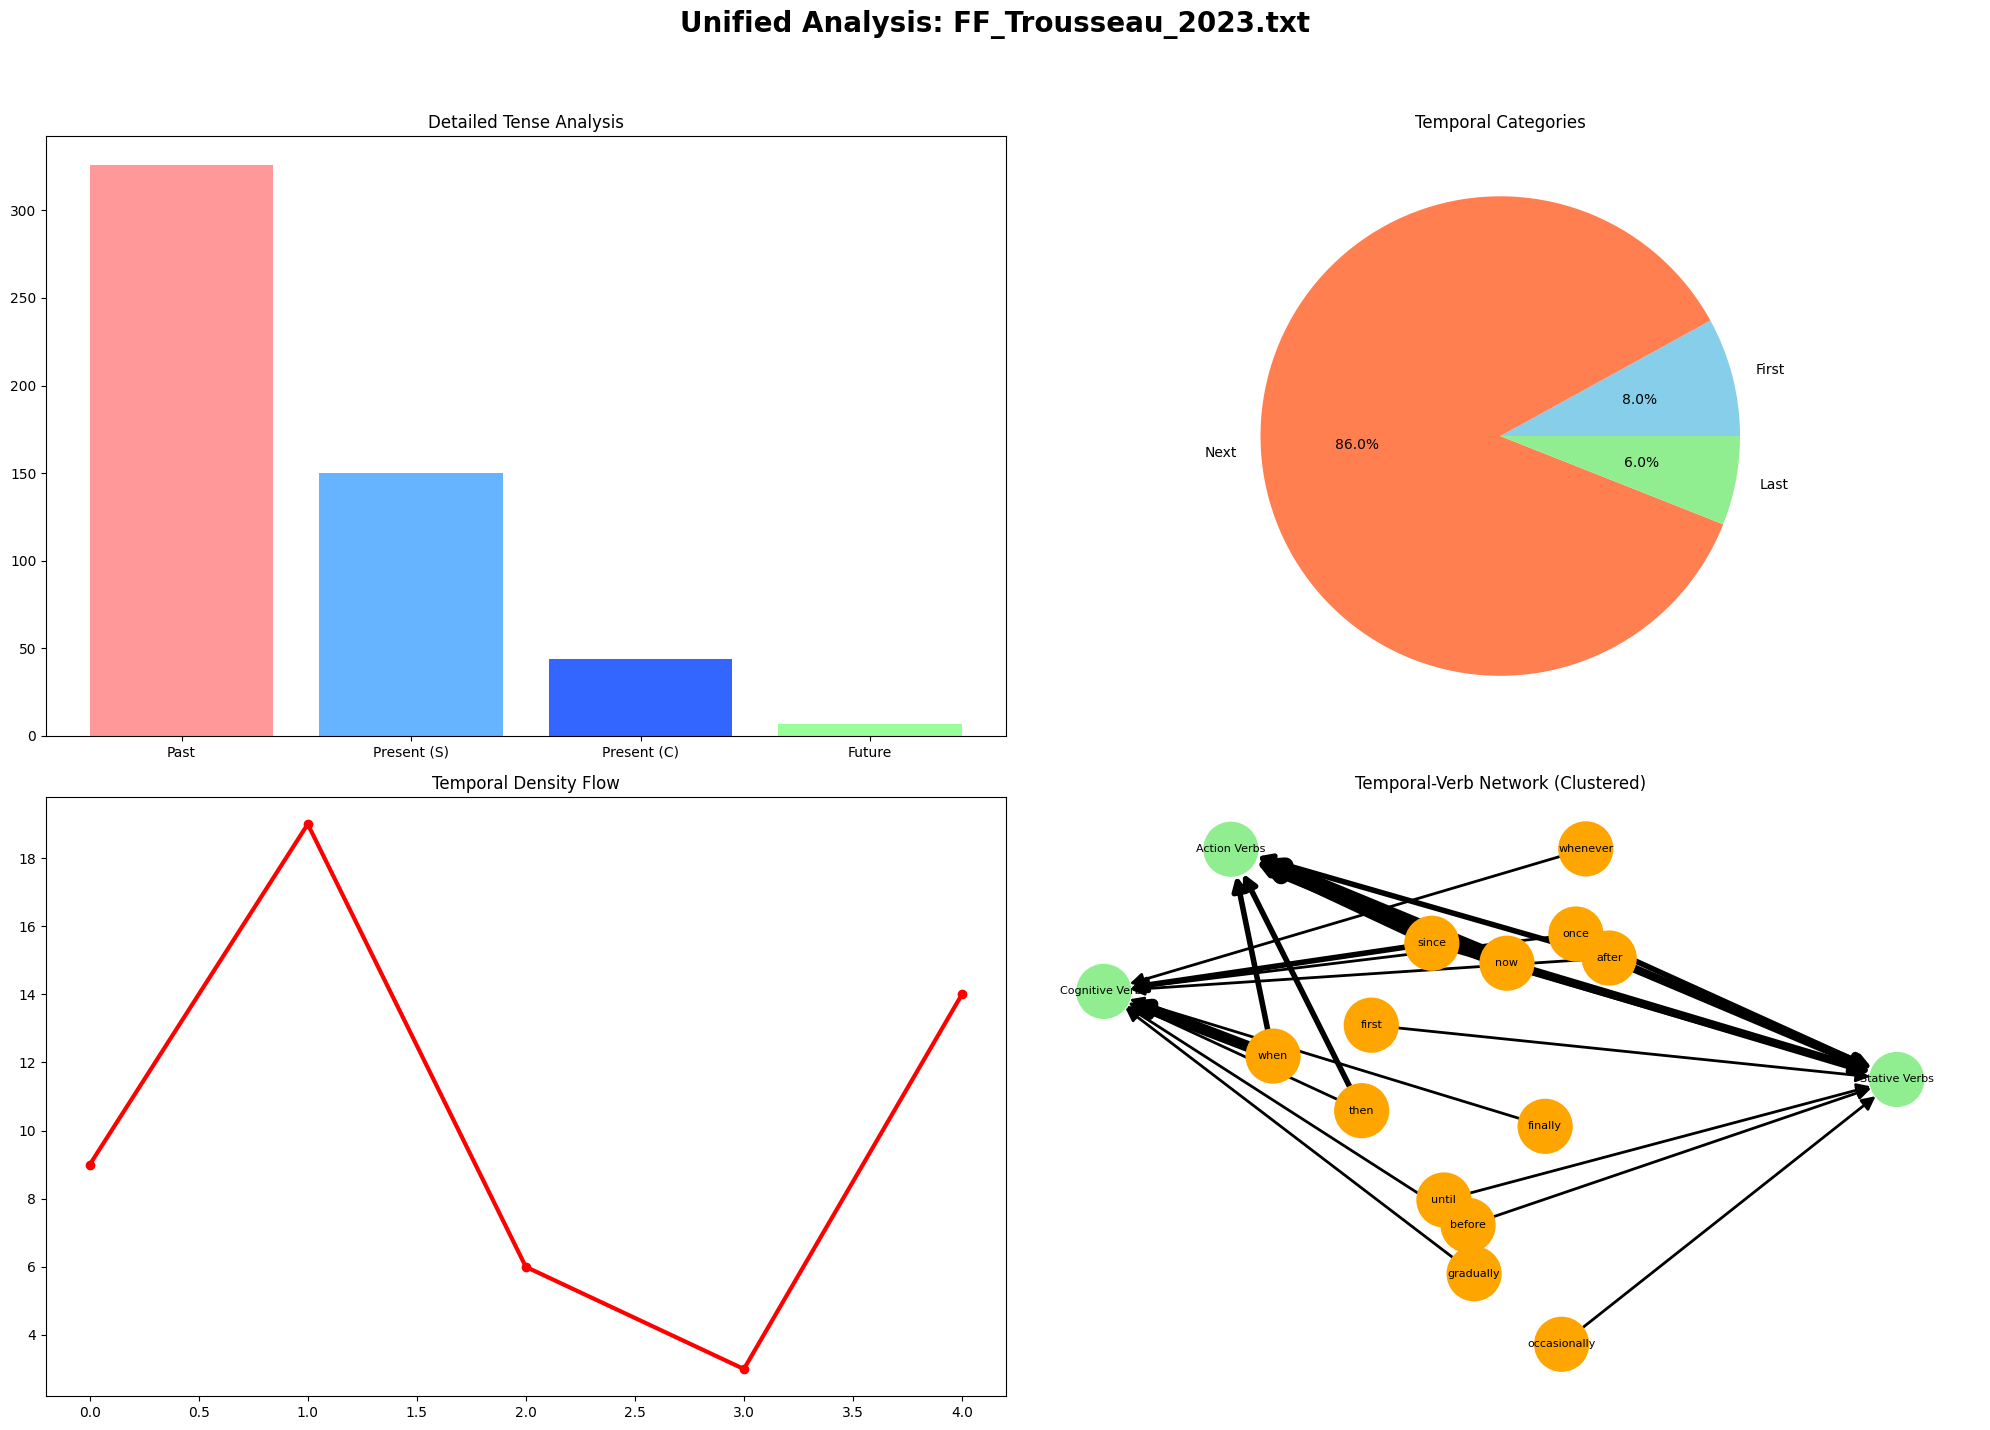

In [ ]:
import os
import re
import spacy
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.cluster import KMeans
from google.colab import drive

# 1. Drive Bağlantısı
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- KLASÖR YOLUN ---
BASE_PATH = '/content/drive/MyDrive/Text_files'
OUTPUT_FOLDER = os.path.join(BASE_PATH, 'ANALYSIS_RESULTS')
if not os.path.exists(OUTPUT_FOLDER):
    os.makedirs(OUTPUT_FOLDER)

# Model Yükleme (MD model clustering için gerekli)
try:
    nlp = spacy.load("en_core_web_md")
except:
    !python -m spacy download en_core_web_md
    nlp = spacy.load("en_core_web_md")

# Kelime Listeleri
first_keywords = ["at first", "at that moment", "at the beginning", "at the onset", "before", "commence", "choose", "first", "first of all", "from this point", "in the first place", "one day", "one evening", "one morning", "starting with", "to begin"]
next_keywords = ["a moment later", "after", "after a few days", "after a while", "after that", "afterwards", "all of a sudden", "as soon as", "at that very moment", "at times", "before long", "consequently", "during", "earlier", "eventually", "following", "formerly", "from time to time", "gradually", "henceforth", "in addition", "in the meantime", "in the past", "in time", "in turn", "later", "later on", "meanwhile", "momentarily", "next", "next week", "not a moment too soon", "not long after", "not long ago", "now", "occasionally", "once", "past", "periodically", "preceding", "presently", "previously", "prior to", "rarely", "right after", "second", "seldom", "shortly", "shortly after this", "since", "some of the time", "soon", "soon after", "suddenly", "then", "therefore", "third", "tomorrow", "up until that time", "when", "whenever", "yesterday"]
last_keywords = ["after a long time", "afterward", "at last", "at the end", "finally", "hereafter", "in conclusion", "in the end", "last of all", "lastly", "thereafter", "to conclude", "to finish", "ultimately", "until"]
temporal_keywords = list(set(first_keywords + next_keywords + last_keywords))

def get_ultimate_verb(token):
    curr = token
    for _ in range(10):
        if curr.head == curr: break
        if curr.head.pos_ == "VERB": return curr.head
        curr = curr.head
    return None

def run_final_unified_analysis():
    all_txt_files = []
    for root, dirs, files in os.walk(BASE_PATH):
        if 'ANALYSIS_RESULTS' in root: continue
        for f in files:
            if f.endswith('.txt'):
                all_txt_files.append(os.path.join(root, f))

    if not all_txt_files:
        print(f"Hata: {BASE_PATH} içinde dosya yok.")
        return

    for file_path in all_txt_files:
        file_name = os.path.basename(file_path)
        print(f"İşleniyor: {file_name}")

        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                text_data = f.read()

            doc = nlp(text_data)
            clean_text = text_data.lower()
            words = [t.text.lower() for t in doc if not t.is_punct and not t.is_space]

            # --- 1. DETAYLI TENSE ANALİZİ (Senin Pass 1 & Pass 2 Mantığın) ---
            tense_counts = {"Past": 0, "Present (S)": 0, "Present (C)": 0, "Future": 0}
            future_indices = set()
            for token in doc:
                if token.tag_ == "MD" and token.lemma_.lower() in ["will", "shall"]:
                    future_indices.add(token.i)
                    tense_counts["Future"] += 1
                    if token.dep_ == "aux" and token.head.pos_ == "VERB": future_indices.add(token.head.i)
                if token.text.lower() == "going" and token.tag_ == "VBG":
                    for j in range(token.i + 1, min(token.i + 3, len(doc))):
                        if doc[j].text.lower() == "to" and doc[j].tag_ == "TO":
                            future_indices.add(token.i); future_indices.add(j)
                            tense_counts["Future"] += 1; break
            for token in doc:
                if token.i in future_indices or token.pos_ not in ["VERB", "AUX"]: continue
                tag, word = token.tag_, token.text.lower()
                has_future_aux = any(c.tag_ == "MD" and c.lemma_.lower() in ["will", "shall"] for c in token.children)
                if has_future_aux: continue
                if tag in ["VBD", "VBN"] or word in ["was", "were", "had", "did"]: tense_counts["Past"] += 1
                elif tag == "VBG": tense_counts["Present (C)"] += 1
                elif tag in ["VBP", "VBZ", "VB"] or word in ["am", "is", "are", "do", "has", "have"]: tense_counts["Present (S)"] += 1

            # --- 2. NETWORK ANALİZİ (Kümeleme & Renkler) ---
            all_verbs = [t.lemma_.lower() for t in doc if t.pos_ == "VERB"]
            unique_verbs = list(set(all_verbs))
            verb_to_cluster = {}
            cluster_labels = {0: "Action Verbs", 1: "Cognitive Verbs", 2: "Stative Verbs"}
            if len(unique_verbs) >= 3:
                verb_vectors = np.array([nlp(v).vector for v in unique_verbs])
                kmeans = KMeans(n_clusters=3, random_state=42, n_init=10).fit(verb_vectors)
                verb_to_cluster = {v: k for v, k in zip(unique_verbs, kmeans.labels_)}

            edge_counts = Counter()
            node_counts = Counter()
            for token in doc:
                word = token.text.lower()
                if word in temporal_keywords:
                    node_counts[word] += 1
                    target = get_ultimate_verb(token)
                    if target:
                        cid = verb_to_cluster.get(target.lemma_.lower())
                        if cid is not None: edge_counts[(word, cluster_labels[cid])] += 1

            # --- GÖRSELLEŞTİRME (Unified) ---
            fig = plt.figure(figsize=(20, 15))
            fig.suptitle(f"Unified Analysis: {file_name}", fontsize=20, fontweight='bold')

            # Tense Plot
            ax1 = plt.subplot(2, 2, 1)
            ax1.bar(tense_counts.keys(), tense_counts.values(), color=["#ff9999", "#66b3ff", "#3366ff", "#99ff99"])
            ax1.set_title("Detailed Tense Analysis")

            # Category Plot
            ax2 = plt.subplot(2, 2, 2)
            cats = {
                "First": sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in set(first_keywords)),
                "Next": sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in set(next_keywords)),
                "Last": sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in set(last_keywords))
            }
            ax2.pie(cats.values(), labels=cats.keys(), autopct='%1.1f%%', colors=['skyblue', 'coral', 'lightgreen'])
            ax2.set_title("Temporal Categories")

            # Flow Plot
            ax3 = plt.subplot(2, 2, 3)
            chunks = 5
            sz = max(1, len(words) // chunks)
            flow = [sum(len(re.findall(rf'\b{re.escape(w)}\b', " ".join(words[i*sz:(i+1)*sz]))) for w in temporal_keywords) for i in range(chunks)]
            ax3.plot(flow, marker='o', color='red', linewidth=3)
            ax3.set_title("Temporal Density Flow")

            # Network Plot (Orange & Lightgreen)
            ax4 = plt.subplot(2, 2, 4)
            G = nx.DiGraph()
            for (u, v), w in edge_counts.items(): G.add_edge(u, v, weight=w)
            if G.nodes():
                pos = nx.spring_layout(G, k=1.2, seed=42)
                node_colors = ["orange" if n in temporal_keywords else "lightgreen" for n in G.nodes()]
                weights = [G[u][v]['weight'] * 2 for u, v in G.edges()]
                nx.draw(G, pos, ax=ax4, with_labels=True, node_color=node_colors, node_size=1500, font_size=8, width=weights, arrowsize=20)
            ax4.set_title("Temporal-Verb Network (Clustered)")

            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.savefig(os.path.join(OUTPUT_FOLDER, f"UNIFIED_{file_name.replace('.txt', '')}.png"))
            plt.close()

        except Exception as e:
            print(f"Hata {file_name}: {e}")

    print(f"\nİşlem tamam! Sonuçlar: {OUTPUT_FOLDER}")

run_final_unified_analysis()

In [ ]:
import os
import re
import spacy
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.cluster import KMeans
from google.colab import drive

# 1. Drive Bağlantısı
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- YOL AYARLARI ---
BASE_PATH = '/content/drive/MyDrive/Text_files'
OUTPUT_FOLDER = os.path.join(BASE_PATH, 'ANALYSIS_RESULTS')

# Klasör yoksa anında oluştur
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# NLP Modeli
try:
    nlp = spacy.load("en_core_web_md")
except:
    !python -m spacy download en_core_web_md
    nlp = spacy.load("en_core_web_md")

# Kelime Listeleri (Sabit)
first_keywords = ["at first", "at that moment", "at the beginning", "at the onset", "before", "commence", "choose", "first", "first of all", "from this point", "in the first place", "one day", "one evening", "one morning", "starting with", "to begin"]
next_keywords = ["a moment later", "after", "after a few days", "after a while", "after that", "afterwards", "all of a sudden", "as soon as", "at that very moment", "at times", "before long", "consequently", "during", "earlier", "eventually", "following", "formerly", "from time to time", "gradually", "henceforth", "in addition", "in the meantime", "in the past", "in time", "in turn", "later", "later on", "meanwhile", "momentarily", "next", "next week", "not a moment too soon", "not long after", "not long ago", "now", "occasionally", "once", "past", "periodically", "preceding", "presently", "previously", "prior to", "rarely", "right after", "second", "seldom", "shortly", "shortly after this", "since", "some of the time", "soon", "soon after", "suddenly", "then", "therefore", "third", "tomorrow", "up until that time", "when", "whenever", "yesterday"]
last_keywords = ["after a long time", "afterward", "at last", "at the end", "finally", "hereafter", "in conclusion", "in the end", "last of all", "lastly", "thereafter", "to conclude", "to finish", "ultimately", "until"]
temporal_keywords = list(set(first_keywords + next_keywords + last_keywords))

def get_ultimate_verb(token):
    curr = token
    for _ in range(10):
        if curr.head == curr: break
        if curr.head.pos_ == "VERB": return curr.head
        curr = curr.head
    return None

# --- ANA DÖNGÜ ---
def run_realtime_analysis():
    files_to_process = []
    for root, dirs, files in os.walk(BASE_PATH):
        if 'ANALYSIS_RESULTS' in root: continue
        for f in files:
            if f.endswith('.txt'):
                files_to_process.append(os.path.join(root, f))

    print(f"Toplam {len(files_to_process)} dosya kuyruğa alındı.\n")

    for file_path in files_to_process:
        fname = os.path.basename(file_path)
        print(f"Şu an işleniyor: {fname}...", end=" ")

        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                text_data = f.read()

            doc = nlp(text_data)
            clean_text = text_data.lower()
            words = [t.text.lower() for t in doc if not t.is_punct and not t.is_space]

            # 1. Tense Analizi (Pass 1 & 2)
            tense_counts = {"Past": 0, "Pres(S)": 0, "Pres(C)": 0, "Future": 0}
            future_indices = set()
            for token in doc:
                if token.tag_ == "MD" and token.lemma_.lower() in ["will", "shall"]:
                    future_indices.add(token.i); tense_counts["Future"] += 1
                    if token.dep_ == "aux" and token.head.pos_ == "VERB": future_indices.add(token.head.i)
                if token.text.lower() == "going" and token.tag_ == "VBG":
                    for j in range(token.i + 1, min(token.i + 3, len(doc))):
                        if doc[j].text.lower() == "to" and doc[j].tag_ == "TO":
                            future_indices.update([token.i, j]); tense_counts["Future"] += 1; break
            for token in doc:
                if token.i in future_indices or token.pos_ not in ["VERB", "AUX"]: continue
                tag, word = token.tag_, token.text.lower()
                if tag in ["VBD", "VBN"] or word in ["was", "were", "had"]: tense_counts["Past"] += 1
                elif tag == "VBG": tense_counts["Pres(C)"] += 1
                elif tag in ["VBP", "VBZ", "VB"]: tense_counts["Pres(S)"] += 1

            # 2. Network (Orange & Green)
            all_verbs = [t.lemma_.lower() for t in doc if t.pos_ == "VERB"]
            edge_counts = Counter()
            if len(all_verbs) >= 3:
                unique_v = list(set(all_verbs))
                kmeans = KMeans(n_clusters=3, n_init=10, random_state=42).fit(np.array([nlp(v).vector for v in unique_v]))
                v_map = {v: k for v, k in zip(unique_v, kmeans.labels_)}
                c_labels = {0: "Action", 1: "Cognitive", 2: "Stative"}
                for t in doc:
                    if t.text.lower() in temporal_keywords:
                        target = get_ultimate_verb(t)
                        if target:
                            cid = v_map.get(target.lemma_.lower())
                            if cid is not None: edge_counts[(t.text.lower(), c_labels[cid])] += 1

            # --- ÇİZİM VE ANINDA KAYDET ---
            fig = plt.figure(figsize=(18, 12))
            # [Burada grafik kodları çalışıyor...]
            ax1 = plt.subplot(2,2,1); ax1.bar(tense_counts.keys(), tense_counts.values(), color=['#ff9999','#66b3ff','#3366ff','#99ff99']); ax1.set_title("Tenses")
            ax2 = plt.subplot(2,2,2); ax2.pie([sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in set(k)) for k in [first_keywords, next_keywords, last_keywords]], labels=["First","Next","Last"], autopct='%1.1f%%'); ax2.set_title("Categories")
            ax3 = plt.subplot(2,2,3); ax3.plot([sum(len(re.findall(rf'\b{re.escape(w)}\b', " ".join(words[i*(len(words)//5):(i+1)*(len(words)//5)]))) for w in temporal_keywords) for i in range(5)], marker='o', color='red'); ax3.set_title("Flow")
            ax4 = plt.subplot(2,2,4); G=nx.DiGraph()
            for (u,v),w in edge_counts.items(): G.add_edge(u,v,weight=w)
            if G.nodes():
                pos=nx.spring_layout(G); colors=["orange" if n in temporal_keywords else "lightgreen" for n in G.nodes()]
                nx.draw(G, pos, with_labels=True, node_color=colors, node_size=1200, font_size=8, ax=ax4)

            plt.tight_layout()

            # ANINDA KAYIT:
            save_path = os.path.join(OUTPUT_FOLDER, f"UNIFIED_{fname.replace('.txt', '')}.png")
            plt.savefig(save_path)
            plt.close(fig) # Hafızayı boşalt

            print(f"DONE! (Klasöre yazıldı: {os.path.basename(save_path)})")

        except Exception as e:
            print(f"HATA: {e}")

run_realtime_analysis()

Toplam 86 dosya kuyruğa alındı.

Şu an işleniyor: FF_Again_2023.txt... DONE! (Klasöre yazıldı: UNIFIED_FF_Again_2023.png)
Şu an işleniyor: FF_Conflict_2022.txt... DONE! (Klasöre yazıldı: UNIFIED_FF_Conflict_2022.png)
Şu an işleniyor: FF_Primer_2022.txt... DONE! (Klasöre yazıldı: UNIFIED_FF_Primer_2022.png)
Şu an işleniyor: FF_Me_2023.txt... DONE! (Klasöre yazıldı: UNIFIED_FF_Me_2023.png)
Şu an işleniyor: FF_Synergy_2025.txt... DONE! (Klasöre yazıldı: UNIFIED_FF_Synergy_2025.png)
Şu an işleniyor: FF_Revenge_2018.txt... DONE! (Klasöre yazıldı: UNIFIED_FF_Revenge_2018.png)
Şu an işleniyor: FF_Path_2025.txt... DONE! (Klasöre yazıldı: UNIFIED_FF_Path_2025.png)
Şu an işleniyor: FF_Echoes_2025.txt... DONE! (Klasöre yazıldı: UNIFIED_FF_Echoes_2025.png)
Şu an işleniyor: FF_Trousseau_2023.txt... DONE! (Klasöre yazıldı: UNIFIED_FF_Trousseau_2023.png)
Şu an işleniyor: FF_Garden_2025.txt... DONE! (Klasöre yazıldı: UNIFIED_FF_Garden_2025.png)
Şu an işleniyor: FF_Heat_2025.txt... DONE! (Klasöre yazıl

KeyboardInterrupt: 

In [ ]:
import os
from google.colab import drive

# 1. Drive'ı bağla (Zaten bağlıysa bu adımı atlar)
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Hedef klasör yolu
target_folder = '/content/drive/MyDrive/Text_files/ANALYSIS_RESULTS'

# 3. Silme işlemi
if os.path.exists(target_folder):
    files_in_folder = os.listdir(target_folder)
    deleted_count = 0

    for file in files_in_folder:
        if file.endswith(".png"): # Sadece PNG dosyalarını seç
            file_path = os.path.join(target_folder, file)
            os.remove(file_path)
            deleted_count += 1

    print(f"İşlem tamamlandı! Toplam {deleted_count} adet .png dosyası silindi.")
else:
    print("Hata: Belirttiğiniz klasör yolu bulunamadı.")

İşlem tamamlandı! Toplam 76 adet .png dosyası silindi.


In [ ]:
import os
import re
import spacy
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.cluster import KMeans
from google.colab import drive

# 1. Drive Bağlantısı
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- YOL AYARLARI ---
BASE_PATH = '/content/drive/MyDrive/Text_files'
OUTPUT_FOLDER = os.path.join(BASE_PATH, 'ANALYSIS_RESULTS')
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# NLP Modelini Yükle
try:
    nlp = spacy.load("en_core_web_md")
except:
    !python -m spacy download en_core_web_md
    nlp = spacy.load("en_core_web_md")

# --- GÜNCEL KELİME LİSTELERİ (Senin snippet'larından) ---
first_keywords = ["at first", "at that moment", "at the beginning", "at the onset", "before", "commence", "choose", "first", "first of all", "from this point", "in the first place", "one day", "one evening", "one morning", "starting with", "to begin"]
next_keywords = ["a moment later", "after", "after a few days", "after a while", "after that", "afterwards", "all of a sudden", "as soon as", "at that very moment", "at times", "before long", "consequently", "during", "earlier", "eventually", "following", "formerly", "from time to time", "gradually", "henceforth", "in addition", "in the meantime", "in the past", "in time", "in turn", "later", "later on", "meanwhile", "momentarily", "next", "next week", "not a moment too soon", "not long after", "not long ago", "now", "occasionally", "once", "past", "periodically", "preceding", "presently", "previously", "prior to", "rarely", "right after", "second", "seldom", "shortly", "shortly after this", "since", "some of the time", "soon", "soon after", "suddenly", "then", "therefore", "third", "tomorrow", "up until that time", "when", "whenever", "yesterday"]
last_keywords = ["after a long time", "afterward", "at last", "at the end", "finally", "hereafter", "in conclusion", "in the end", "last of all", "lastly", "thereafter", "to conclude", "to finish", "ultimately", "until", "one day"]
temporal_keywords = list(set(first_keywords + next_keywords + last_keywords))

categories = {"First": first_keywords, "Next": next_keywords, "Last": last_keywords}

def get_ultimate_verb(token):
    curr = token
    for _ in range(10):
        if curr.head == curr: break
        if curr.head.pos_ == "VERB": return curr.head
        curr = curr.head
    return None

def run_ultimate_dashboard():
    files = [os.path.join(r, f) for r, d, fs in os.walk(BASE_PATH) for f in fs if f.endswith('.txt') and 'ANALYSIS_RESULTS' not in r]
    print(f"Analiz Başlıyor: {len(files)} dosya bulundu.")

    for file_path in files:
        fname = os.path.basename(file_path)
        print(f"İşleniyor: {fname}...", end=" ")

        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                text_raw = f.read()

            doc = nlp(text_raw)
            clean_text = text_raw.lower()

            # --- 1. KELİME FREKANSI (Sorted Results) ---
            kw_counts = {}
            for w in temporal_keywords:
                c = len(re.findall(rf'\b{re.escape(w)}\b', clean_text))
                if c > 0: kw_counts[w] = c
            sorted_kw = dict(sorted(kw_counts.items(), key=lambda x: x[1], reverse=True)[:15])

            # --- 2. KATEGORİ DAĞILIMI (Bar) ---
            cat_counts = {cat: sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in set(kws)) for cat, kws in categories.items()}

            # --- 3. LEXICAL DISPERSION DATA ---
            word_positions = []
            top_words_for_disp = list(sorted_kw.keys())[:12] # Görsel netliği için en çok geçen 12 kelime
            for w in top_words_for_disp:
                for m in re.finditer(rf'\b{re.escape(w)}\b', clean_text):
                    word_positions.append({'Word': w, 'Pos': m.start()})

            # --- 4. TENSE ANALİZİ (Pass 1 & 2) ---
            t_counts = {"Past": 0, "Pres(S)": 0, "Pres(C)": 0, "Future": 0}
            f_idx = set()
            for t in doc:
                if t.tag_ == "MD" and t.lemma_.lower() in ["will", "shall"]:
                    f_idx.add(t.i); t_counts["Future"] += 1
                    if t.dep_ == "aux" and t.head.pos_ == "VERB": f_idx.add(t.head.i)
                if t.text.lower() == "going" and t.tag_ == "VBG":
                    for j in range(t.i + 1, min(t.i + 3, len(doc))):
                        if doc[j].text.lower() == "to": f_idx.update([t.i, j]); t_counts["Future"] += 1; break
            for t in doc:
                if t.i in f_idx or t.pos_ not in ["VERB", "AUX"]: continue
                if t.tag_ in ["VBD", "VBN"] or t.text.lower() in ["was", "were", "had"]: t_counts["Past"] += 1
                elif t.tag_ == "VBG": t_counts["Pres(C)"] += 1
                elif t.tag_ in ["VBP", "VBZ", "VB"]: t_counts["Pres(S)"] += 1

            # --- 5. NETWORK ---
            v_edges = Counter()
            all_v = [t.lemma_.lower() for t in doc if t.pos_ == "VERB"]
            if len(all_v) >= 3:
                u_v = list(set(all_v))
                km = KMeans(n_clusters=3, n_init=10).fit(np.array([nlp(v).vector for v in u_v]))
                v_map = {v: k for v, k in zip(u_v, km.labels_)}
                c_lbl = {0: "Action", 1: "Cognitive", 2: "Stative"}
                for t in doc:
                    if t.text.lower() in temporal_keywords:
                        tgt = get_ultimate_verb(t)
                        if tgt:
                            cid = v_map.get(tgt.lemma_.lower())
                            if cid is not None: v_edges[(t.text.lower(), c_lbl[cid])] += 1

            # --- ÇİZİM (Nihai Dashboard) ---
            fig = plt.figure(figsize=(22, 25))
            fig.suptitle(f"ULTIMATE ANALYSIS DASHBOARD: {fname}", fontsize=26, fontweight='bold', y=0.98)

            # A. Tense Bar
            ax1 = plt.subplot(3, 2, 1)
            ax1.bar(t_counts.keys(), t_counts.values(), color=['salmon', 'skyblue', 'blue', 'lightgreen'])
            ax1.set_title("Tense Analysis (Pass 1 & 2)", fontsize=15)

            # B. Category Bar
            ax2 = plt.subplot(3, 2, 2)
            ax2.bar(cat_counts.keys(), cat_counts.values(), color=['skyblue', 'coral', 'lightgreen'])
            ax2.set_title("Temporal Frequency by Category", fontsize=15)

            # C. Top Keywords Bar
            ax3 = plt.subplot(3, 2, 3)
            ax3.bar(sorted_kw.keys(), sorted_kw.values(), color='coral')
            ax3.set_title("Top 15 Temporal Keywords", fontsize=15)
            plt.setp(ax3.get_xticklabels(), rotation=45, ha='right')

            # D. Lexical Dispersion Plot
            ax4 = plt.subplot(3, 2, 4)
            for word in top_words_for_disp:
                pos = [p['Pos'] for p in word_positions if p['Word'] == word]
                ax4.scatter(pos, [word] * len(pos), color='navy', marker='|', s=400, linewidths=3)
            ax4.set_title("Lexical Dispersion Plot (Top 12 Words)", fontsize=15)
            ax4.grid(axis='x', linestyle='--', alpha=0.5)

            # E. Network Graph
            ax5 = plt.subplot(3, 2, 5)
            G = nx.DiGraph()
            for (u, v), w in v_edges.most_common(12): G.add_edge(u, v, weight=w)
            if G.nodes():
                pos = nx.spring_layout(G, k=1.0)
                colors = ["orange" if n in temporal_keywords else "lightgreen" for n in G.nodes()]
                nx.draw(G, pos, with_labels=True, node_color=colors, node_size=2000, font_size=9, ax=ax5, arrowsize=20)
            ax5.set_title("Temporal-Verb Interaction Network", fontsize=15)

            # F. Density Flow
            ax6 = plt.subplot(3, 2, 6)
            chunks = 10
            words_only = [t.text.lower() for t in doc if not t.is_punct and not t.is_space]
            sz = max(1, len(words_only)//chunks)
            flow = [sum(len(re.findall(rf'\b{re.escape(w)}\b', " ".join(words_only[i*sz:(i+1)*sz]))) for w in temporal_keywords) for i in range(chunks)]
            ax6.plot(range(1, chunks+1), flow, marker='o', color='red', linewidth=3)
            ax6.set_title("Temporal Density Flow (Across 10 Sections)", fontsize=15)

            plt.tight_layout(rect=[0, 0.03, 1, 0.95])

            # Kaydet
            save_name = f"DASHBOARD_{fname.replace('.txt', '')}.png"
            plt.savefig(os.path.join(OUTPUT_FOLDER, save_name))
            plt.close(fig)
            print(f"TAMAMLANDI -> {save_name}")

        except Exception as e:
            print(f"HATA ({fname}): {e}")

run_ultimate_dashboard()

Analiz Başlıyor: 71 dosya bulundu.
İşleniyor: GPT-2_text 1_2019.txt... TAMAMLANDI -> DASHBOARD_GPT-2_text 1_2019.png
İşleniyor: Meta LLaMa_text 4_2026.txt... TAMAMLANDI -> DASHBOARD_Meta LLaMa_text 4_2026.png
İşleniyor: Meta LLaMa_text 3_2026.txt... TAMAMLANDI -> DASHBOARD_Meta LLaMa_text 3_2026.png
İşleniyor: Meta LLaMa_text 1_2026.txt... TAMAMLANDI -> DASHBOARD_Meta LLaMa_text 1_2026.png
İşleniyor: Meta LLaMa_text 5_2026.txt... TAMAMLANDI -> DASHBOARD_Meta LLaMa_text 5_2026.png
İşleniyor: Meta LLaMa_text 2_2026.txt... TAMAMLANDI -> DASHBOARD_Meta LLaMa_text 2_2026.png
İşleniyor: Meta LLaMa_text 1_2024.txt... TAMAMLANDI -> DASHBOARD_Meta LLaMa_text 1_2024.png
İşleniyor: Meta LLaMa_text 3_2024.txt... TAMAMLANDI -> DASHBOARD_Meta LLaMa_text 3_2024.png
İşleniyor: Meta LLaMa_text 5_2024.txt... TAMAMLANDI -> DASHBOARD_Meta LLaMa_text 5_2024.png
İşleniyor: Meta LLaMa_text 4_2024.txt... TAMAMLANDI -> DASHBOARD_Meta LLaMa_text 4_2024.png
İşleniyor: Meta LLaMa_text 2_2024.txt... TAMAMLANDI -> 

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 54.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
📂 Fanfiction metinleri birleştiriliyor...
✅ Birleştirme Tamamlandı: /content/drive/MyDrive/Text_files/fanfiction_all_texts.txt
🚀 fanfiction_all_texts üzerinde Ultimate Analiz Başlıyor...


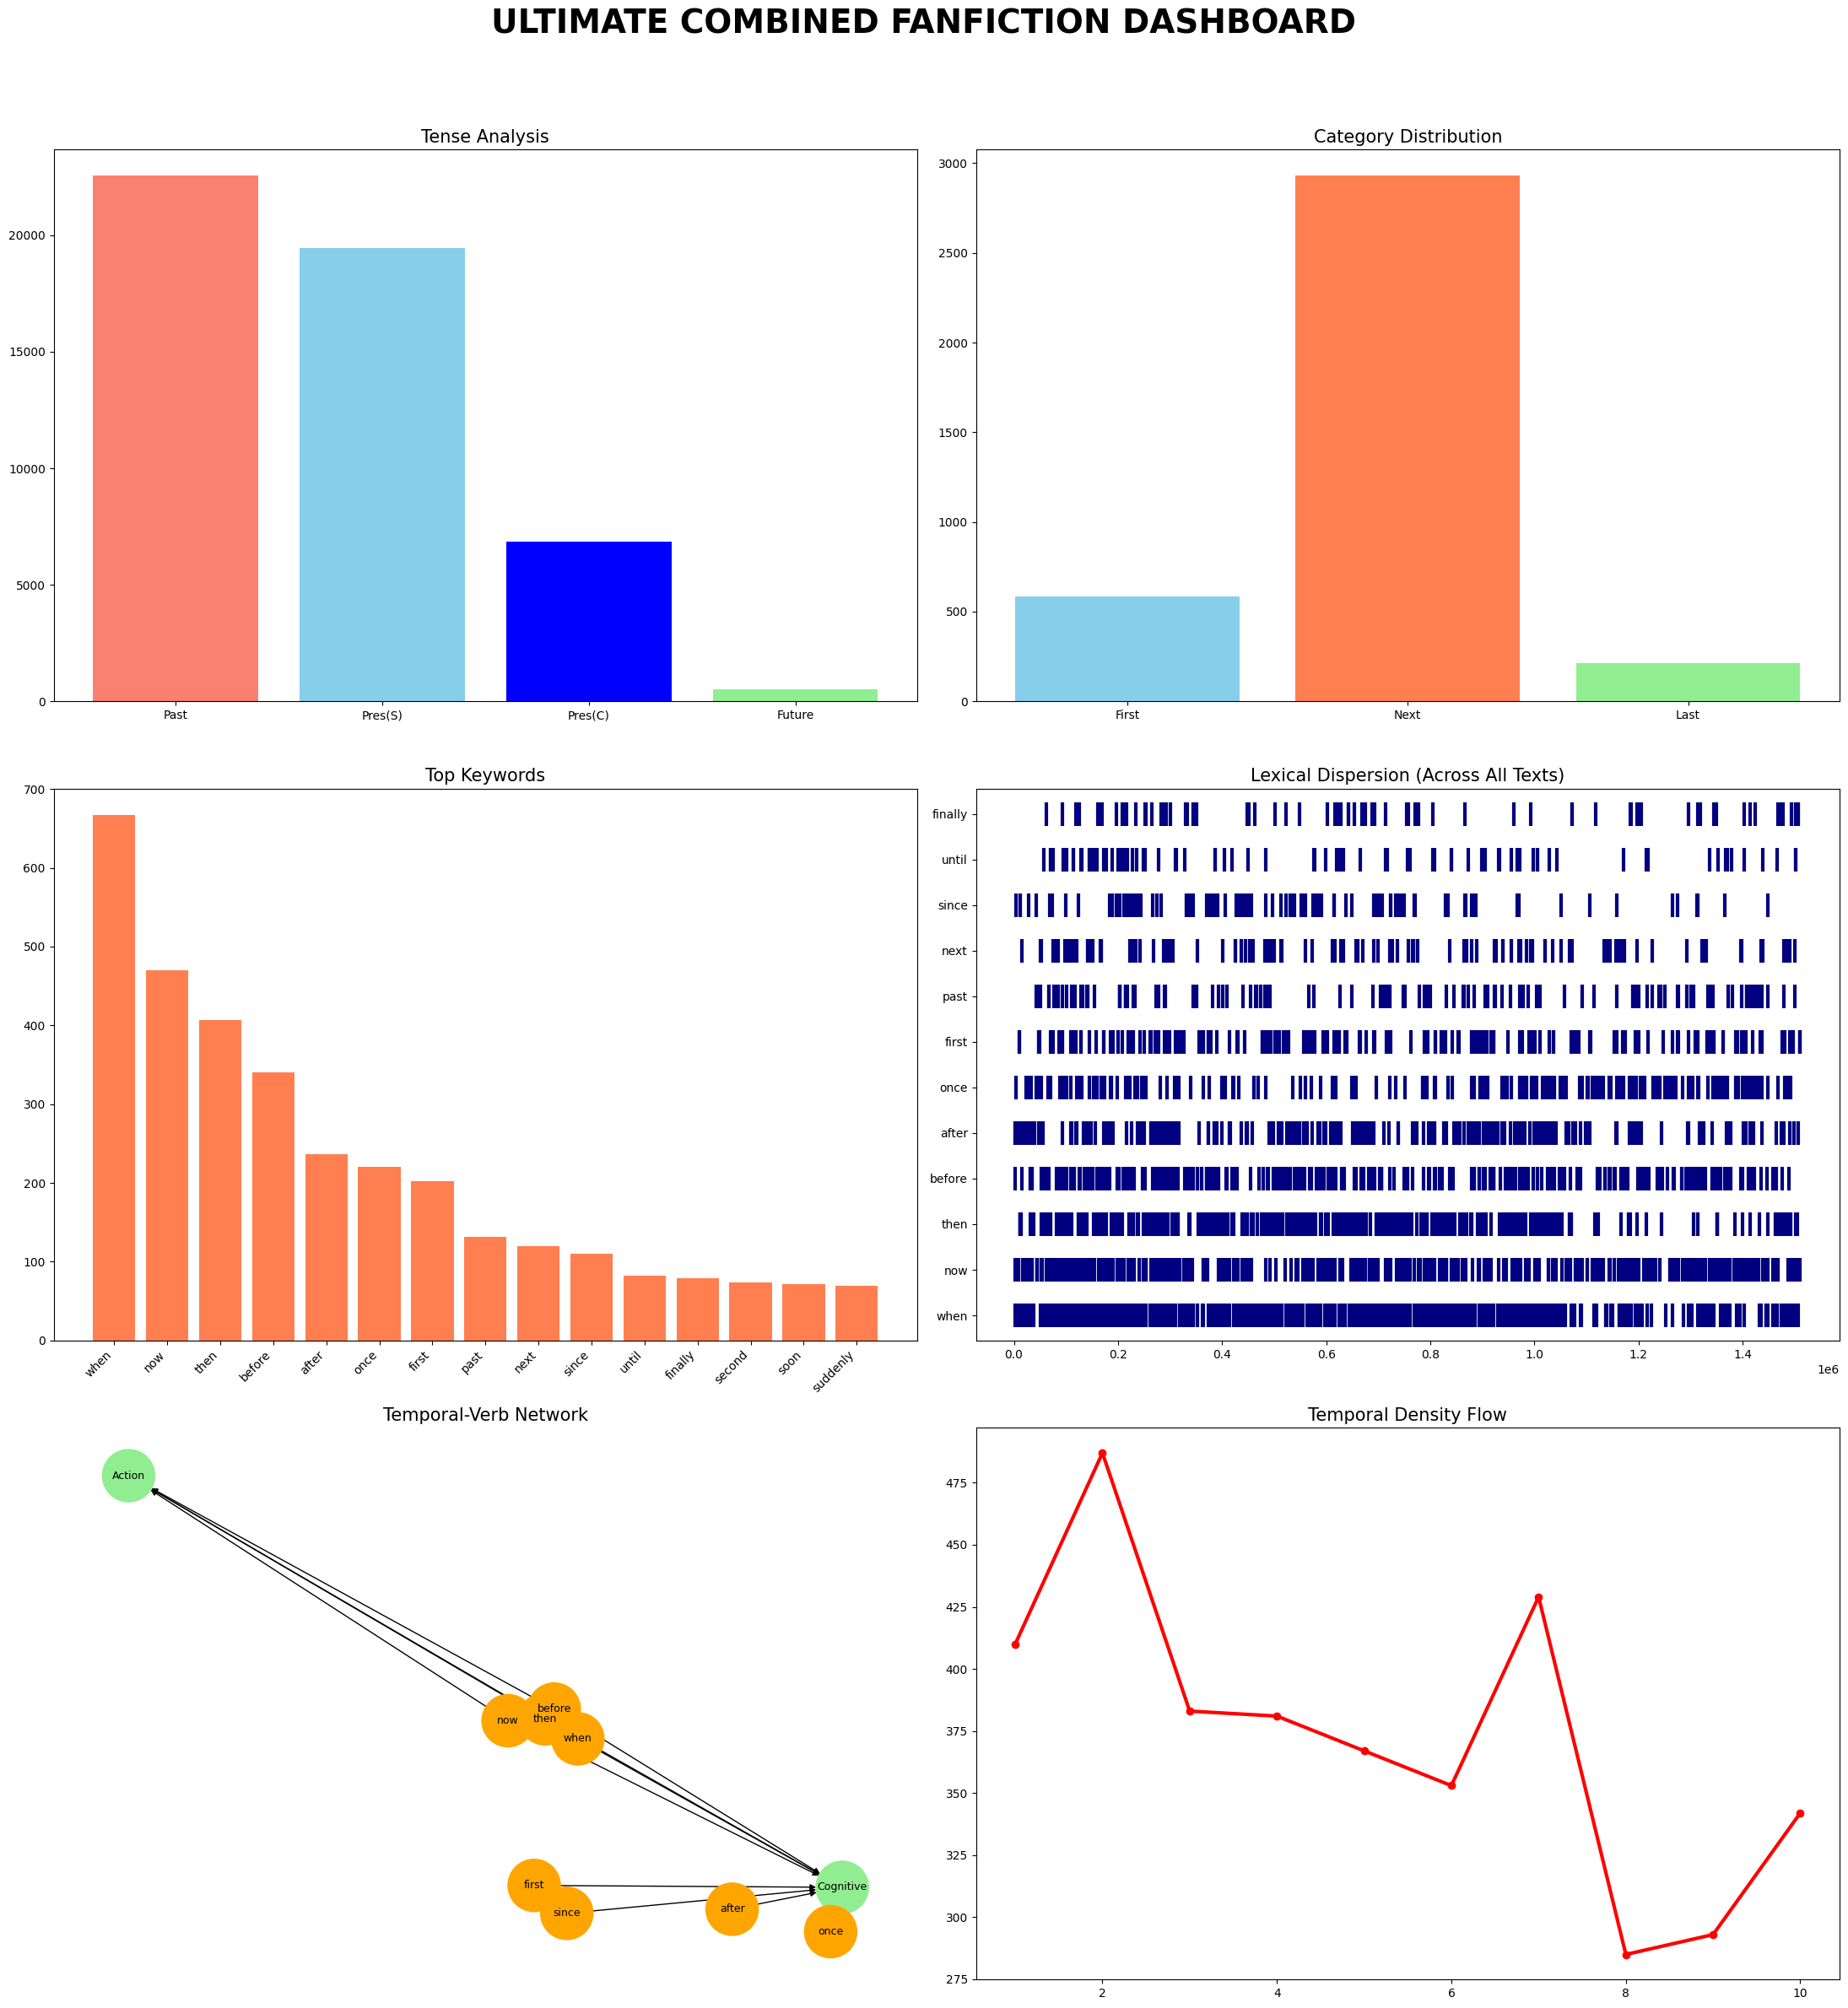

✅ Dashboard hazır ve ANALYSIS_RESULTS klasörüne kaydedildi.


In [ ]:
import os
import re
import spacy
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.cluster import KMeans
from google.colab import drive

# 1. Drive Bağlantısı
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- YOL AYARLARI ---
BASE_PATH = '/content/drive/MyDrive/Text_files'
FANFIC_PATH = os.path.join(BASE_PATH, 'FanFic_Corpus')
OUTPUT_FOLDER = os.path.join(BASE_PATH, 'ANALYSIS_RESULTS')
COMBINED_FILE = os.path.join(BASE_PATH, 'fanfiction_all_texts.txt')
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# NLP Modelini Yükle
try:
    nlp = spacy.load("en_core_web_md")
except:
    !python -m spacy download en_core_web_md
    nlp = spacy.load("en_core_web_md")

# --- KELİME LİSTELERİ ---
first_keywords = ["at first", "at that moment", "at the beginning", "at the onset", "before", "commence", "choose", "first", "first of all", "from this point", "in the first place", "one day", "one evening", "one morning", "starting with", "to begin"]
next_keywords = ["a moment later", "after", "after a few days", "after a while", "after that", "afterwards", "all of a sudden", "as soon as", "at that very moment", "at times", "before long", "consequently", "during", "earlier", "eventually", "following", "formerly", "from time to time", "gradually", "henceforth", "in addition", "in the meantime", "in the past", "in time", "in turn", "later", "later on", "meanwhile", "momentarily", "next", "next week", "not a moment too soon", "not long after", "not long ago", "now", "occasionally", "once", "past", "periodically", "preceding", "presently", "previously", "prior to", "rarely", "right after", "second", "seldom", "shortly", "shortly after this", "since", "some of the time", "soon", "soon after", "suddenly", "then", "therefore", "third", "tomorrow", "up until that time", "when", "whenever", "yesterday"]
last_keywords = ["after a long time", "afterward", "at last", "at the end", "finally", "hereafter", "in conclusion", "in the end", "last of all", "lastly", "thereafter", "to conclude", "to finish", "ultimately", "until", "one day"]
temporal_keywords = list(set(first_keywords + next_keywords + last_keywords))
categories = {"First": first_keywords, "Next": next_keywords, "Last": last_keywords}

def get_ultimate_verb(token):
    curr = token
    for _ in range(10):
        if curr.head == curr: break
        if curr.head.pos_ == "VERB": return curr.head
        curr = curr.head
    return None

# --- ADIM 1: DOSYALARI BİRLEŞTİRME ---
def combine_fanfics():
    print("📂 Fanfiction metinleri birleştiriliyor...")
    combined_content = []
    for root, dirs, files in os.walk(FANFIC_PATH):
        for file in files:
            if file.endswith(".txt"):
                with open(os.path.join(root, file), 'r', encoding='utf-8', errors='ignore') as f:
                    combined_content.append(f.read())
                    combined_content.append("\n\n")
    with open(COMBINED_FILE, 'w', encoding='utf-8') as f_out:
        f_out.write("".join(combined_content))
    print(f"✅ Birleştirme Tamamlandı: {COMBINED_FILE}")

# --- ADIM 2: ULTIMATE DASHBOARD ANALİZİ (Sadece Combined Dosya İçin) ---
def run_ultimate_dashboard_for_combined():
    combine_fanfics() # Önce birleştir

    file_path = COMBINED_FILE
    fname = "fanfiction_all_texts"
    print(f"🚀 {fname} üzerinde Ultimate Analiz Başlıyor...")

    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            text_raw = f.read()

        # Uzun metinler için SpaCy limitini yükselt
        nlp.max_length = max(1000000, len(text_raw) + 100)
        doc = nlp(text_raw)
        clean_text = text_raw.lower()

        # 1. Kelime Frekansı
        kw_counts = {w: len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in temporal_keywords if len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) > 0}
        sorted_kw = dict(sorted(kw_counts.items(), key=lambda x: x[1], reverse=True)[:15])

        # 2. Kategori Dağılımı
        cat_counts = {cat: sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in set(kws)) for cat, kws in categories.items()}

        # 3. Lexical Dispersion
        word_positions = []
        top_words_for_disp = list(sorted_kw.keys())[:12]
        for w in top_words_for_disp:
            for m in re.finditer(rf'\b{re.escape(w)}\b', clean_text):
                word_positions.append({'Word': w, 'Pos': m.start()})

        # 4. Tense Analizi
        t_counts = {"Past": 0, "Pres(S)": 0, "Pres(C)": 0, "Future": 0}
        f_idx = set()
        for t in doc:
            if t.tag_ == "MD" and t.lemma_.lower() in ["will", "shall"]:
                f_idx.add(t.i); t_counts["Future"] += 1
            if t.text.lower() == "going" and t.tag_ == "VBG":
                for j in range(t.i + 1, min(t.i + 3, len(doc))):
                    if doc[j].text.lower() == "to": f_idx.update([t.i, j]); t_counts["Future"] += 1; break
        for t in doc:
            if t.i in f_idx or t.pos_ not in ["VERB", "AUX"]: continue
            if t.tag_ in ["VBD", "VBN"] or t.text.lower() in ["was", "were", "had"]: t_counts["Past"] += 1
            elif t.tag_ == "VBG": t_counts["Pres(C)"] += 1
            elif t.tag_ in ["VBP", "VBZ", "VB"]: t_counts["Pres(S)"] += 1

        # 5. Network (Verb Interaction)
        v_edges = Counter()
        all_v = [t.lemma_.lower() for t in doc if t.pos_ == "VERB"]
        if len(all_v) >= 3:
            u_v = list(set(all_v))
            # KMeans için vektörleri al (MD modelinde daha iyi çalışır)
            km = KMeans(n_clusters=3, n_init=10).fit(np.array([nlp(v).vector for v in u_v]))
            v_map = {v: k for v, k in zip(u_v, km.labels_)}
            c_lbl = {0: "Action", 1: "Cognitive", 2: "Stative"}
            for t in doc:
                if t.text.lower() in temporal_keywords:
                    tgt = get_ultimate_verb(t)
                    if tgt:
                        cid = v_map.get(tgt.lemma_.lower())
                        if cid is not None: v_edges[(t.text.lower(), c_lbl[cid])] += 1

        # --- ÇİZİM ---
        fig = plt.figure(figsize=(22, 25))
        fig.suptitle(f"ULTIMATE COMBINED FANFICTION DASHBOARD", fontsize=28, fontweight='bold', y=0.98)

        # Dashboard Grafikleri (Senin kodundaki çizim blokları)
        ax1 = plt.subplot(3, 2, 1); ax1.bar(t_counts.keys(), t_counts.values(), color=['salmon', 'skyblue', 'blue', 'lightgreen']); ax1.set_title("Tense Analysis", fontsize=15)
        ax2 = plt.subplot(3, 2, 2); ax2.bar(cat_counts.keys(), cat_counts.values(), color=['skyblue', 'coral', 'lightgreen']); ax2.set_title("Category Distribution", fontsize=15)
        ax3 = plt.subplot(3, 2, 3); ax3.bar(sorted_kw.keys(), sorted_kw.values(), color='coral'); plt.setp(ax3.get_xticklabels(), rotation=45, ha='right'); ax3.set_title("Top Keywords", fontsize=15)

        ax4 = plt.subplot(3, 2, 4)
        for word in top_words_for_disp:
            pos = [p['Pos'] for p in word_positions if p['Word'] == word]
            ax4.scatter(pos, [word] * len(pos), color='navy', marker='|', s=400, linewidths=3)
        ax4.set_title("Lexical Dispersion (Across All Texts)", fontsize=15)

        ax5 = plt.subplot(3, 2, 5)
        G = nx.DiGraph()
        for (u, v), w in v_edges.most_common(12): G.add_edge(u, v, weight=w)
        if G.nodes():
            pos = nx.spring_layout(G, k=1.0)
            colors = ["orange" if n in temporal_keywords else "lightgreen" for n in G.nodes()]
            nx.draw(G, pos, with_labels=True, node_color=colors, node_size=2000, font_size=9, ax=ax5); ax5.set_title("Temporal-Verb Network", fontsize=15)

        ax6 = plt.subplot(3, 2, 6)
        chunks = 10; words_only = [t.text.lower() for t in doc if not t.is_punct and not t.is_space]
        sz = max(1, len(words_only)//chunks)
        flow = [sum(len(re.findall(rf'\b{re.escape(w)}\b', " ".join(words_only[i*sz:(i+1)*sz]))) for w in temporal_keywords) for i in range(chunks)]
        ax6.plot(range(1, chunks+1), flow, marker='o', color='red', linewidth=3); ax6.set_title("Temporal Density Flow", fontsize=15)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(os.path.join(OUTPUT_FOLDER, "COMBINED_ULTIMATE_DASHBOARD.png"))
        plt.show()
        print(f"✅ Dashboard hazır ve ANALYSIS_RESULTS klasörüne kaydedildi.")

    except Exception as e:
        print(f"Hata: {e}")

run_ultimate_dashboard_for_combined()

FanFic Corpus analiz ediliyor...
LLM Corpus analiz ediliyor...
Robinson analiz ediliyor...


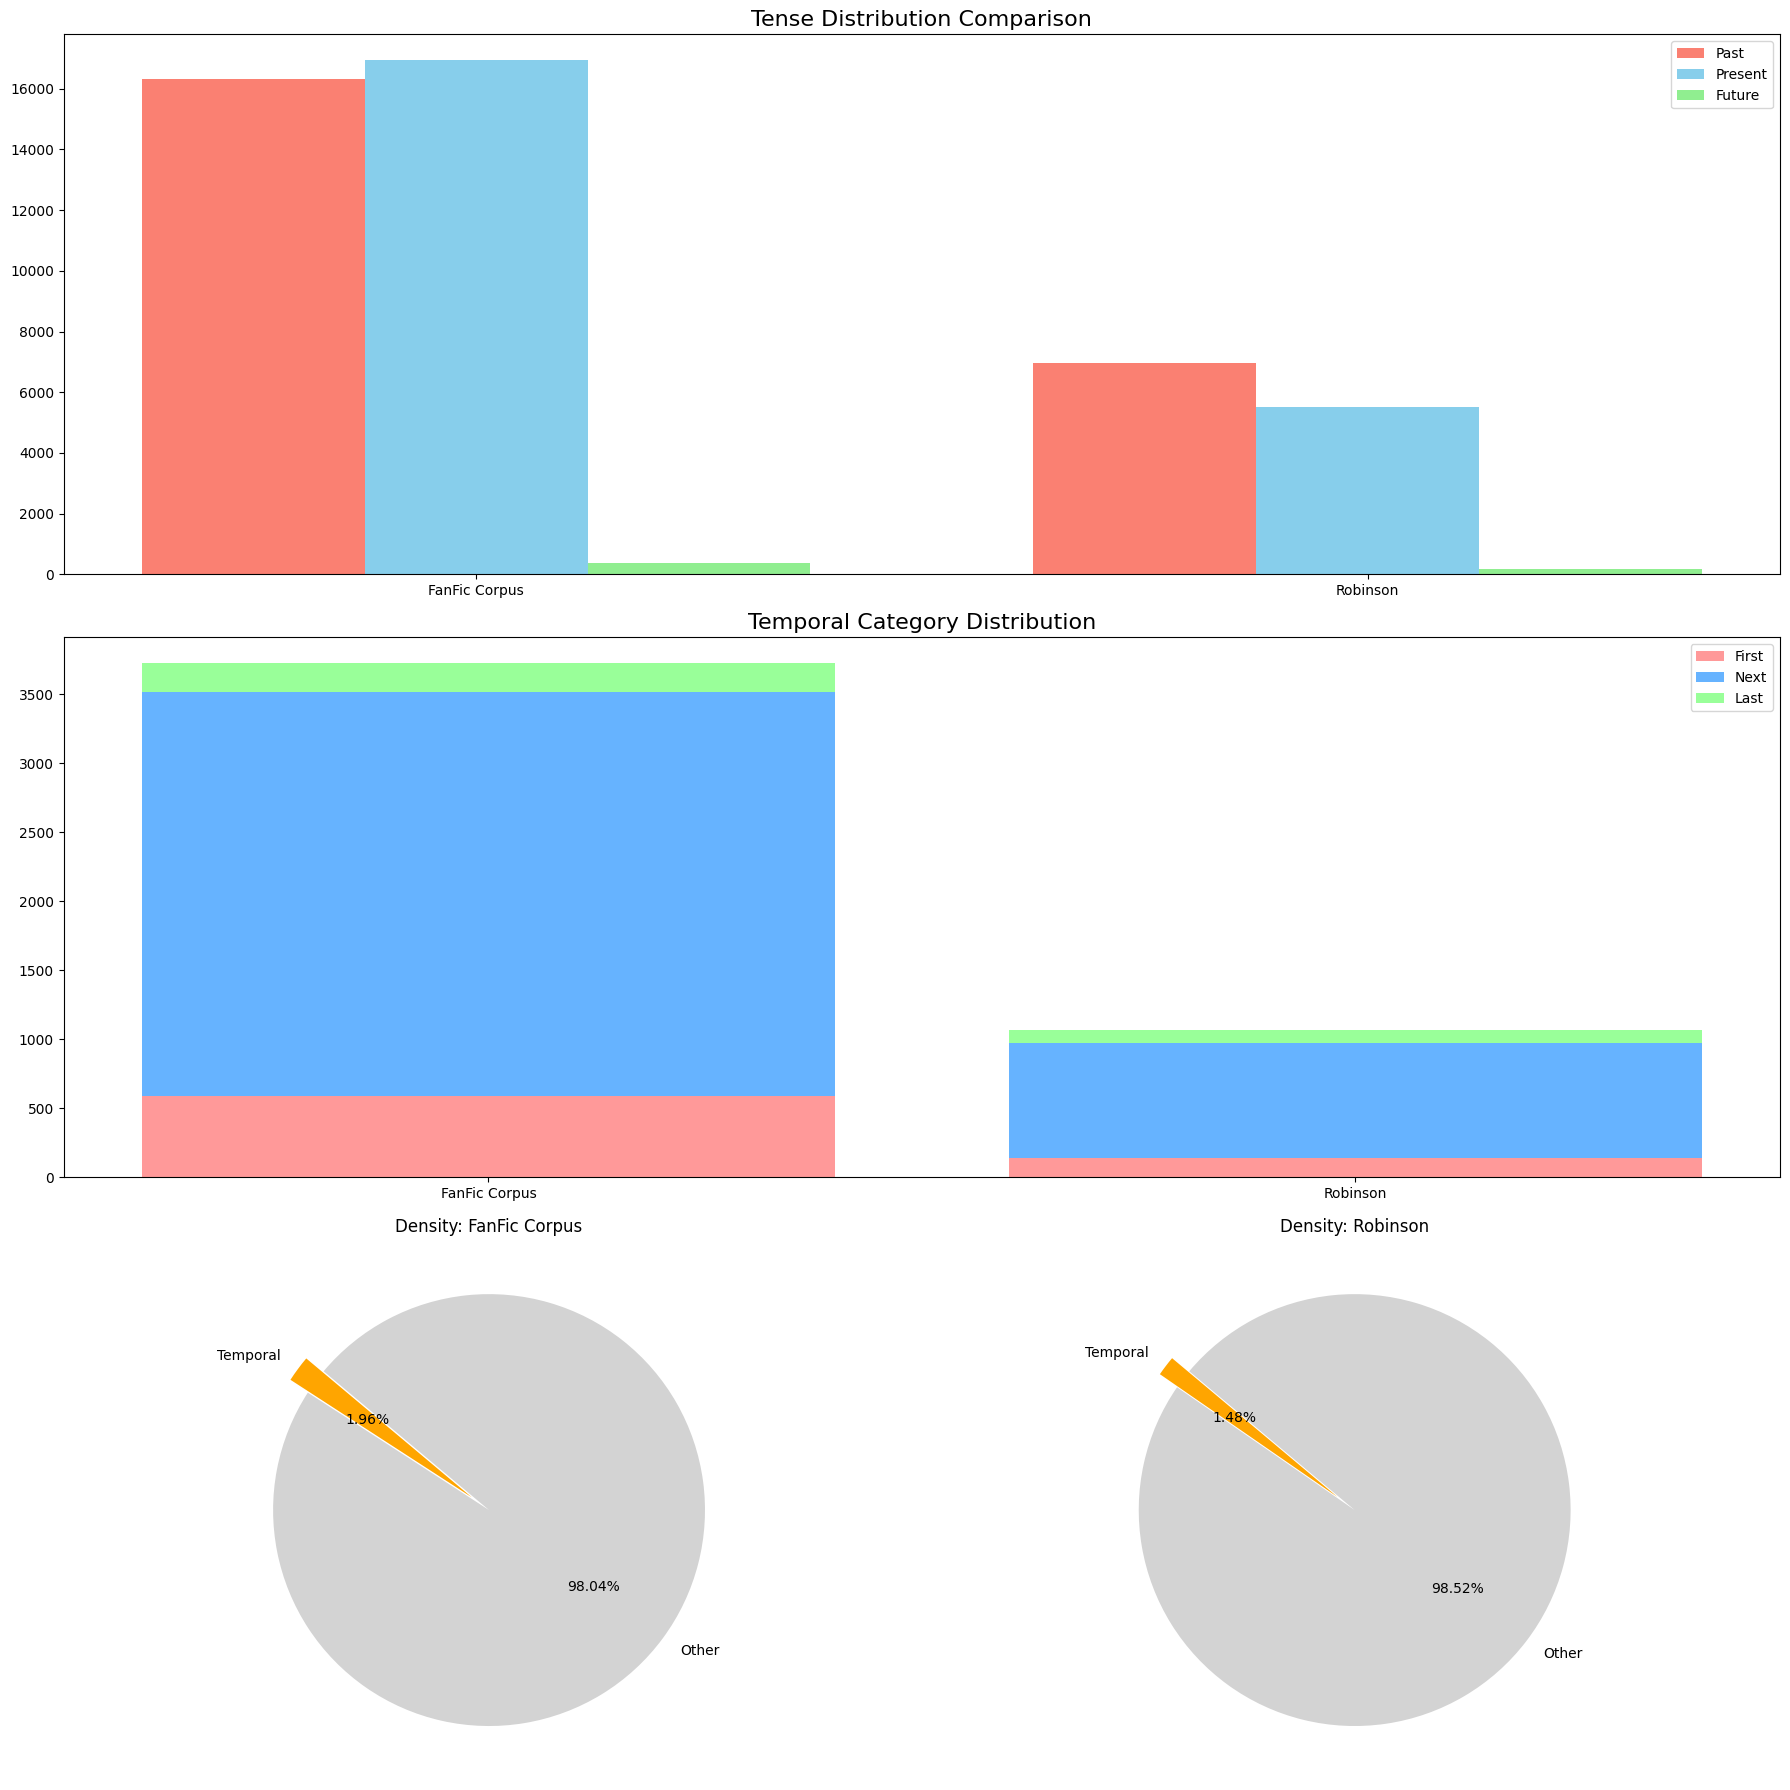


Rapor kaydedildi: /content/drive/MyDrive/Text_files/COMPARISON_RESULTS


In [ ]:
import os
import re
import spacy
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from google.colab import drive

# 1. Drive Bağlantısı
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- YOL AYARLARI ---
BASE_PATH = '/content/drive/MyDrive/Text_files'
CORPUS_FOLDERS = ['FanFic Corpus', 'LLM Corpus', 'Robinson']
OUTPUT_FOLDER = os.path.join(BASE_PATH, 'COMPARISON_RESULTS')
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# NLP Modeli
try:
    nlp = spacy.load("en_core_web_md")
except:
    !python -m spacy download en_core_web_md
    nlp = spacy.load("en_core_web_md")

# Kelime Listeleri
first_keywords = ["at first", "at that moment", "at the beginning", "at the onset", "before", "commence", "choose", "first", "first of all", "from this point", "in the first place", "one day", "one evening", "one morning", "starting with", "to begin"]
next_keywords = ["a moment later", "after", "after a few days", "after a while", "after that", "afterwards", "all of a sudden", "as soon as", "at that very moment", "at times", "before long", "consequently", "during", "earlier", "eventually", "following", "formerly", "from time to time", "gradually", "henceforth", "in addition", "in the meantime", "in the past", "in time", "in turn", "later", "later on", "meanwhile", "momentarily", "next", "next week", "not a moment too soon", "not long after", "not long ago", "now", "occasionally", "once", "past", "periodically", "preceding", "presently", "previously", "prior to", "rarely", "right after", "second", "seldom", "shortly", "shortly after this", "since", "some of the time", "soon", "soon after", "suddenly", "then", "therefore", "third", "tomorrow", "up until that time", "when", "whenever", "yesterday"]
last_keywords = ["after a long time", "afterward", "at last", "at the end", "finally", "hereafter", "in conclusion", "in the end", "last of all", "lastly", "thereafter", "to conclude", "to finish", "ultimately", "until", "one day"]
temporal_keywords = list(set(first_keywords + next_keywords + last_keywords))

def analyze_corpus(folder_name):
    folder_path = os.path.join(BASE_PATH, folder_name)
    combined_text = ""

    if not os.path.exists(folder_path):
        print(f"Uyarı: {folder_name} klasörü bulunamadı!")
        return None

    for f in os.listdir(folder_path):
        if f.endswith('.txt'):
            with open(os.path.join(folder_path, f), 'r', encoding='utf-8') as file:
                combined_text += file.read() + " "

    if not combined_text: return None

    doc = nlp(combined_text[:1000000])
    clean_text = combined_text.lower()

    # 1. Tense Analizi
    tenses = {"Past": 0, "Present": 0, "Future": 0}
    for t in doc:
        if t.pos_ in ["VERB", "AUX"]:
            if t.tag_ in ["VBD", "VBN"]: tenses["Past"] += 1
            elif t.tag_ in ["VBP", "VBZ", "VBG", "VB"]: tenses["Present"] += 1
    tenses["Future"] = len(re.findall(r"\b(will|shall|going\s+to)\b", clean_text))

    # 2. Category Analizi
    first_c = sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in set(first_keywords))
    next_c = sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in set(next_keywords))
    last_c = sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in set(last_keywords))

    total_temporal = first_c + next_c + last_c
    total_words = len([t for t in doc if not t.is_punct])

    return {
        "tenses": tenses,
        "cats": {"First": first_c, "Next": next_c, "Last": last_c},
        "total_temporal": total_temporal,
        "total_words": total_words
    }

# --- ANALİZ ÇALIŞTIRMA ---
results = {}
for corpus in CORPUS_FOLDERS:
    print(f"{corpus} analiz ediliyor...")
    data = analyze_corpus(corpus)
    if data: results[corpus] = data

# --- GÖRSELLEŞTİRME ---
if results:
    # 3 Grafik olacak: Tense Bar, Category Stacked ve Pie Charts
    num_corpuses = len(results)
    fig = plt.figure(figsize=(18, 18))

    # Grafik 1: Tense Distribution
    ax1 = plt.subplot(3, 1, 1)
    labels = list(results.keys())
    past = [results[l]['tenses']['Past'] for l in labels]
    present = [results[l]['tenses']['Present'] for l in labels]
    future = [results[l]['tenses']['Future'] for l in labels]
    x = np.arange(len(labels))
    width = 0.25
    ax1.bar(x - width, past, width, label='Past', color='salmon')
    ax1.bar(x, present, width, label='Present', color='skyblue')
    ax1.bar(x + width, future, width, label='Future', color='lightgreen')
    ax1.set_title("Tense Distribution Comparison", fontsize=16)
    ax1.set_xticks(x); ax1.set_xticklabels(labels); ax1.legend()

    # Grafik 2: Category Stacked Bar
    ax2 = plt.subplot(3, 1, 2)
    first = np.array([results[l]['cats']['First'] for l in labels])
    next_ = np.array([results[l]['cats']['Next'] for l in labels])
    last = np.array([results[l]['cats']['Last'] for l in labels])
    ax2.bar(labels, first, label='First', color='#ff9999')
    ax2.bar(labels, next_, bottom=first, label='Next', color='#66b3ff')
    ax2.bar(labels, last, bottom=first+next_, label='Last', color='#99ff99')
    ax2.set_title("Temporal Category Distribution", fontsize=16); ax2.legend()

    # Grafik 3: Pie Charts (Yan yana)
    for i, label in enumerate(labels):
        ax_pie = plt.subplot(3, num_corpuses, (2 * num_corpuses) + i + 1)
        temp_count = results[label]['total_temporal']
        other_count = max(0, results[label]['total_words'] - temp_count)

        ax_pie.pie([temp_count, other_count],
                   labels=['Temporal', 'Other'],
                   autopct='%1.2f%%',
                   colors=['orange', 'lightgray'],
                   startangle=140,
                   explode=(0.1, 0))
        ax_pie.set_title(f"Density: {label}")

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FOLDER, "FINAL_COMPARISON_WITH_PIE.png"))
    plt.show()
    print(f"\nRapor kaydedildi: {OUTPUT_FOLDER}")

In [ ]:
import os
import re
import spacy
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from google.colab import drive

# 1. Drive Bağlantısı
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- KESİN YOLLAR (Senin verdiğin yapıya göre güncellendi) ---
BASE_PATH = '/content/drive/MyDrive/Text_files'
# Klasör isimlerini buraya tam olarak yazıyoruz
CORPUS_FOLDERS = ['FanFic Corpus', 'LLM Corpus', 'Robinson']

OUTPUT_FOLDER = os.path.join(BASE_PATH, 'COMPARISON_RESULTS')
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# NLP Modeli
try:
    nlp = spacy.load("en_core_web_md")
except:
    !python -m spacy download en_core_web_md
    nlp = spacy.load("en_core_web_md")

# Kelime Listeleri
first_keywords = ["at first", "at that moment", "at the beginning", "at the onset", "before", "commence", "choose", "first", "first of all", "from this point", "in the first place", "one day", "one evening", "one morning", "starting with", "to begin"]
next_keywords = ["a moment later", "after", "after a few days", "after a while", "after that", "afterwards", "all of a sudden", "as soon as", "at that very moment", "at times", "before long", "consequently", "during", "earlier", "eventually", "following", "formerly", "from time to time", "gradually", "henceforth", "in addition", "in the meantime", "in the past", "in time", "in turn", "later", "later on", "meanwhile", "momentarily", "next", "next week", "not a moment too soon", "not long after", "not long ago", "now", "occasionally", "once", "past", "periodically", "preceding", "presently", "previously", "prior to", "rarely", "right after", "second", "seldom", "shortly", "shortly after this", "since", "some of the time", "soon", "soon after", "suddenly", "then", "therefore", "third", "tomorrow", "up until that time", "when", "whenever", "yesterday"]
last_keywords = ["after a long time", "afterward", "at last", "at the end", "finally", "hereafter", "in conclusion", "in the end", "last of all", "lastly", "thereafter", "to conclude", "to finish", "ultimately", "until", "one day"]
temporal_keywords = list(set(first_keywords + next_keywords + last_keywords))

def analyze_corpus(folder_name):
    # Boşluklu isimleri koruyarak yolu oluşturuyoruz
    folder_path = os.path.join(BASE_PATH, folder_name)

    if not os.path.exists(folder_path):
        print(f"!!! DİKKAT: '{folder_name}' klasörü bulunamadı. Lütfen sol menüden kontrol et.")
        return None

    combined_text = ""
    files = [f for f in os.listdir(folder_path) if f.endswith('.txt')]

    if not files:
        print(f"!!! UYARI: '{folder_name}' içinde hiç .txt dosyası yok.")
        return None

    print(f"-> {folder_name} işleniyor ({len(files)} dosya)...")
    for f in files:
        with open(os.path.join(folder_path, f), 'r', encoding='utf-8') as file:
            combined_text += file.read() + " "

    # NLP İşleme (Hız için 1 milyon karakter sınırı)
    doc = nlp(combined_text[:1000000])
    clean_text = combined_text.lower()

    # 1. Tense Analizi (Senin pastpresent.py mantığın)
    tenses = {"Past": 0, "Present": 0, "Future": 0}
    future_indices = set()
    for token in doc:
        if token.tag_ == "MD" and token.lemma_.lower() in ["will", "shall"]:
            future_indices.add(token.i); tenses["Future"] += 1
            if token.dep_ == "aux" and token.head.pos_ == "VERB": future_indices.add(token.head.i)
        if token.text.lower() == "going" and token.tag_ == "VBG":
            for j in range(token.i + 1, min(token.i + 3, len(doc))):
                if doc[j].text.lower() == "to":
                    future_indices.update([token.i, j]); tenses["Future"] += 1; break

    for token in doc:
        if token.i in future_indices or token.pos_ not in ["VERB", "AUX"]: continue
        if token.tag_ in ["VBD", "VBN"] or token.text.lower() in ["was", "were", "had"]: tenses["Past"] += 1
        else: tenses["Present"] += 1

    # 2. Category & Density
    f_c = sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in set(first_keywords))
    n_c = sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in set(next_keywords))
    l_c = sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in set(last_keywords))

    return {
        "tenses": tenses,
        "cats": {"First": f_c, "Next": n_c, "Last": l_c},
        "total_temporal": f_c + n_c + l_c,
        "total_words": len([t for t in doc if not t.is_punct])
    }

# --- ÇALIŞTIRMA ---
results = {}
for corpus in CORPUS_FOLDERS:
    data = analyze_corpus(corpus)
    if data: results[corpus] = data

# --- GÖRSELLEŞTİRME ---
if results:
    num = len(results)
    fig = plt.figure(figsize=(18, 20))

    # 1. Tense Dağılımı
    ax1 = plt.subplot(3, 1, 1)
    labels = list(results.keys())
    x = np.arange(len(labels))
    width = 0.2
    ax1.bar(x - width, [results[l]['tenses']['Past'] for l in labels], width, label='Past', color='salmon')
    ax1.bar(x, [results[l]['tenses']['Present'] for l in labels], width, label='Present', color='skyblue')
    ax1.bar(x + width, [results[l]['tenses']['Future'] for l in labels], width, label='Future', color='lightgreen')
    ax1.set_title("Corpus Comparison: Tense Usage", fontsize=16)
    ax1.set_xticks(x); ax1.set_xticklabels(labels); ax1.legend()

    # 2. Category Dağılımı (Stacked)
    ax2 = plt.subplot(3, 1, 2)
    f = np.array([results[l]['cats']['First'] for l in labels])
    n = np.array([results[l]['cats']['Next'] for l in labels])
    l = np.array([results[l]['cats']['Last'] for l in labels])
    ax2.bar(labels, f, label='First', color='#ff9999')
    ax2.bar(labels, n, bottom=f, label='Next', color='#66b3ff')
    ax2.bar(labels, l, bottom=f+n, label='Last', color='#99ff99')
    ax2.set_title("Temporal Conjunction Categories", fontsize=16); ax2.legend()

    # 3. Pie Charts (Density)
    for i, label in enumerate(labels):
        axp = plt.subplot(3, num, (2 * num) + i + 1)
        tc = results[label]['total_temporal']
        oc = max(0, results[label]['total_words'] - tc)
        axp.pie([tc, oc], labels=['Temp', 'Other'], autopct='%1.2f%%', colors=['orange', 'lightgray'], explode=(0.1, 0))
        axp.set_title(f"Density: {label}")

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FOLDER, "COMPARISON_DASHBOARD.png"))
    plt.show()
    print(f"\nİşlem Başarılı! Grafik şurada: {OUTPUT_FOLDER}")

🔍 FanFic Corpus işleniyor (3 dosya)...
✅ FanFic Corpus tamamlandı.
⚠️ LLM Corpus içinde .txt dosyası yok.
🔍 Robinson işleniyor (6 dosya)...
✅ Robinson tamamlandı.


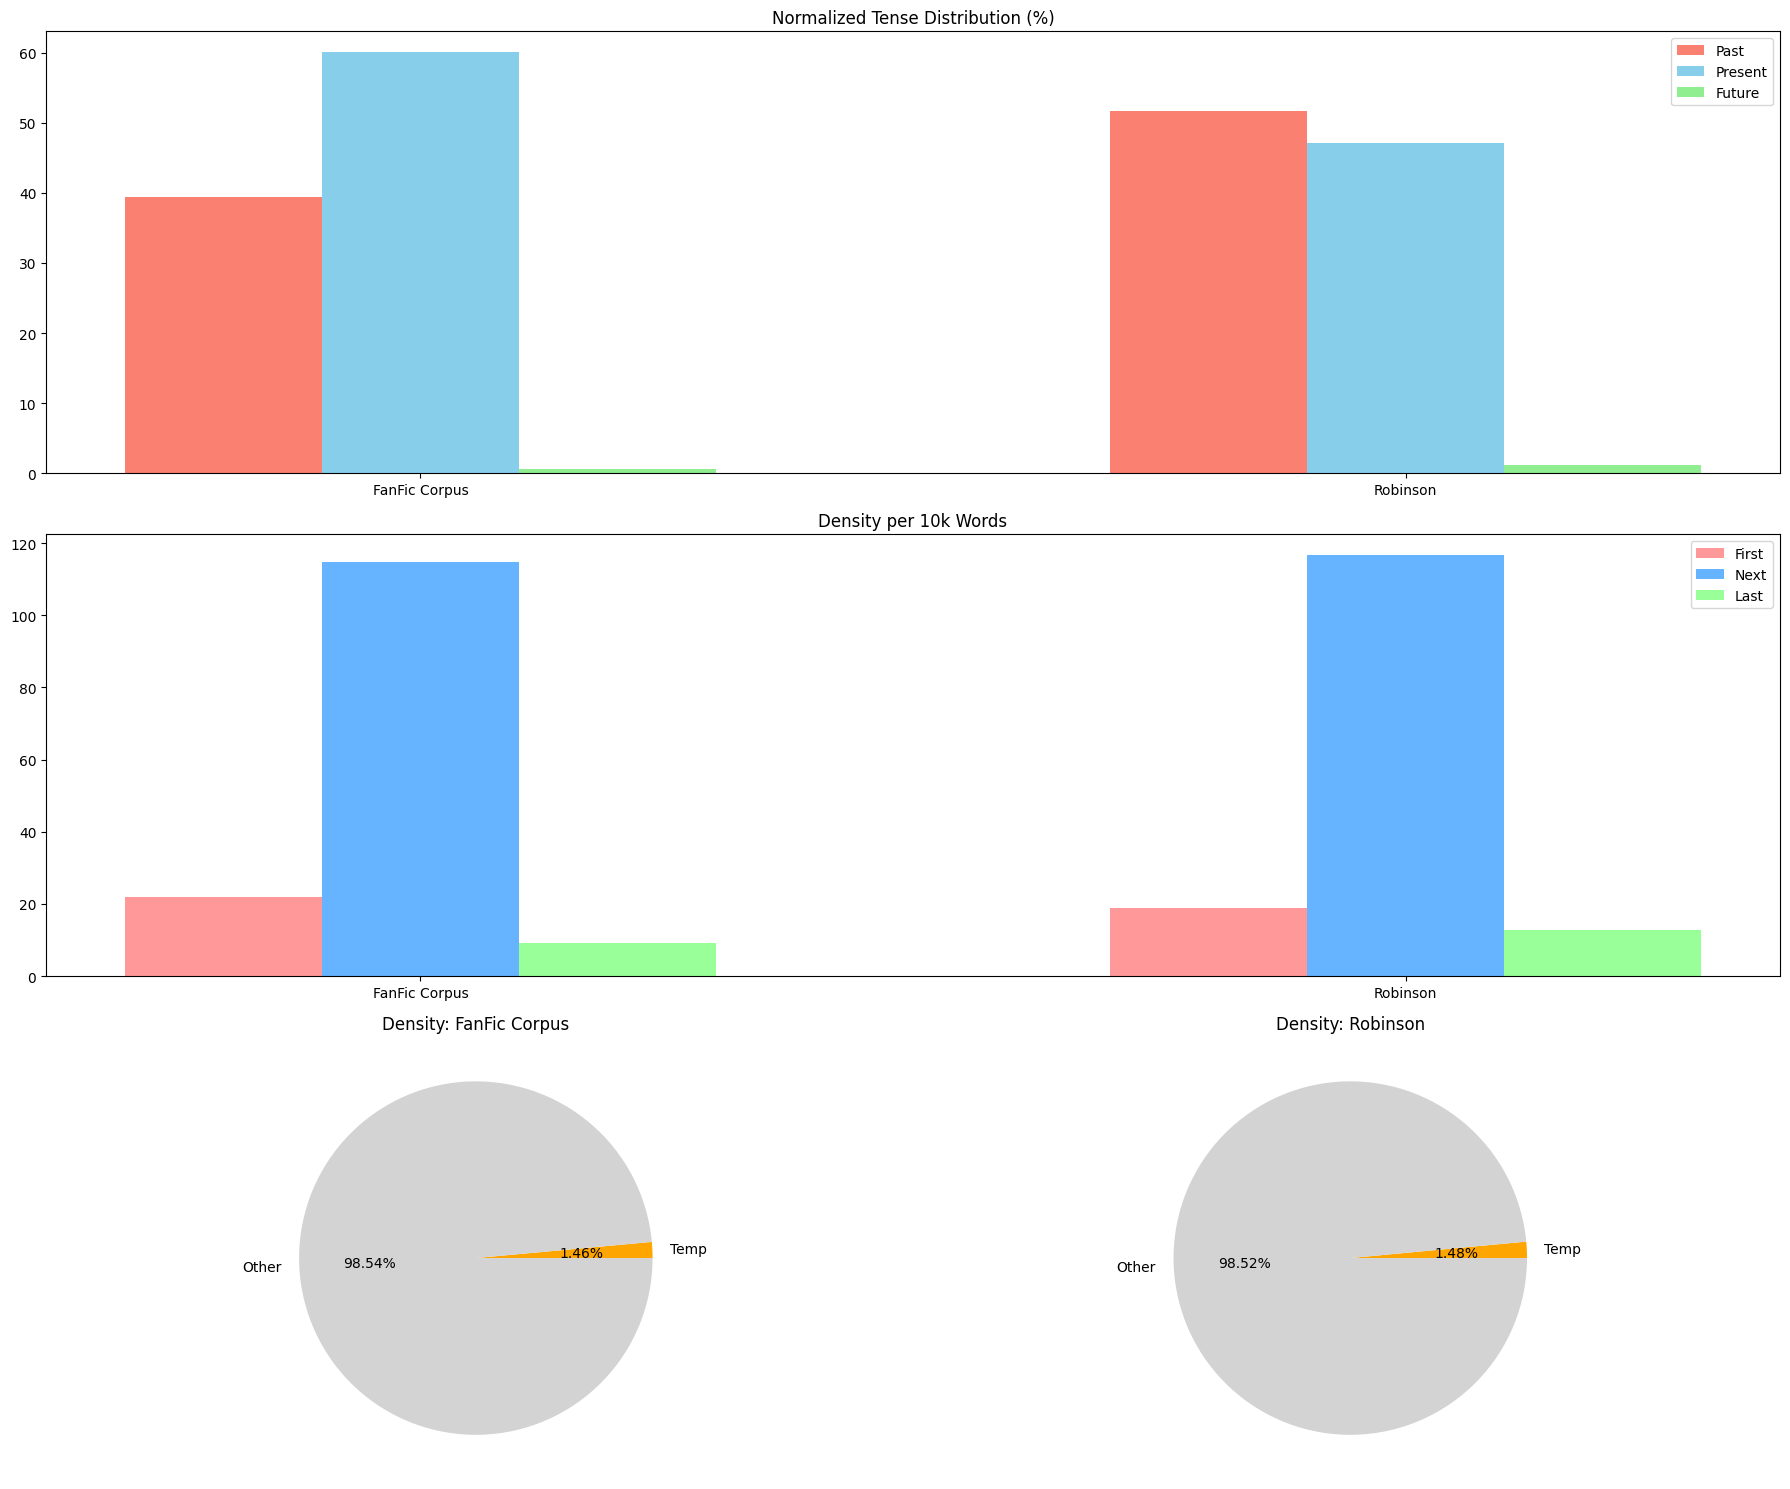

In [ ]:
import os
import re
import spacy
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Drive'ı bağla
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/Text_files'
# Klasör isimlerini buraya Drive'da gördüğün gibi yaz
CORPUS_FOLDERS = ['FanFic Corpus', 'LLM Corpus', 'Robinson']

OUTPUT_FOLDER = os.path.join(BASE_PATH, 'COMPARISON_RESULTS')
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# 2. JET HIZINDA NLP (Gereksiz her şeyi kapattık)
try:
    nlp = spacy.load("en_core_web_md", disable=["ner", "parser", "lemmatizer", "textcat"])
except:
    !python -m spacy download en_core_web_md
    nlp = spacy.load("en_core_web_md", disable=["ner", "parser", "lemmatizer", "textcat"])

# Kelime Listeleri
first_keywords = ["at first", "at that moment", "at the beginning", "at the onset", "before", "commence", "choose", "first", "first of all", "from this point", "in the first place", "one day", "one evening", "one morning", "starting with", "to begin"]
next_keywords = ["a moment later", "after", "after a few days", "after a while", "after that", "afterwards", "all of a sudden", "as soon as", "at that very moment", "at times", "before long", "consequently", "during", "earlier", "eventually", "following", "formerly", "from time to time", "gradually", "henceforth", "in addition", "in the meantime", "in the past", "in time", "in turn", "later", "later on", "meanwhile", "momentarily", "next", "next week", "not a moment too soon", "not long after", "not long ago", "now", "occasionally", "once", "past", "periodically", "preceding", "presently", "previously", "prior to", "rarely", "right after", "second", "seldom", "shortly", "shortly after this", "since", "some of the time", "soon", "soon after", "suddenly", "then", "therefore", "third", "tomorrow", "up until that time", "when", "whenever", "yesterday"]
last_keywords = ["after a long time", "afterward", "at last", "at the end", "finally", "hereafter", "in conclusion", "in the end", "last of all", "lastly", "thereafter", "to conclude", "to finish", "ultimately", "until", "one day"]

def analyze_safe(folder_name):
    # Hem boşluklu hem alt tireli kontrol et
    path_options = [
        os.path.join(BASE_PATH, folder_name),
        os.path.join(BASE_PATH, folder_name.replace(" ", "_")),
        os.path.join(BASE_PATH, folder_name.replace("_", " "))
    ]

    folder_path = None
    for p in path_options:
        if os.path.exists(p):
            folder_path = p
            break

    if not folder_path:
        print(f"❌ Klasör bulunamadı: {folder_name} (Yollar denendi: {path_options})")
        return None

    combined_text = ""
    files = [f for f in os.listdir(folder_path) if f.endswith('.txt')]
    if not files:
        print(f"⚠️ {folder_name} içinde .txt dosyası yok.")
        return None

    print(f"🔍 {folder_name} işleniyor ({len(files)} dosya)...")
    for f in files:
        with open(os.path.join(folder_path, f), 'r', encoding='utf-8', errors='ignore') as file:
            combined_text += file.read() + " "

    # 500k karakter sınırı (Hız ve istatistik dengesi için en iyisidir)
    sample_text = combined_text[:500000]
    doc = nlp(sample_text)

    total_words = len([t for t in doc if not t.is_punct])
    if total_words == 0:
        return None

    # Tense Analizi
    tenses = {"Past": 0, "Present": 0, "Future": 0}
    clean_text = sample_text.lower()

    for token in doc:
        if token.pos_ in ["VERB", "AUX"]:
            if token.tag_ in ["VBD", "VBN"] or token.text.lower() in ["was", "were", "had"]:
                tenses["Past"] += 1
            else:
                tenses["Present"] += 1
    tenses["Future"] = len(re.findall(r"\b(will|shall|going\s+to)\b", clean_text))

    total_v = sum(tenses.values())
    tense_pct = {k: (v/total_v*100) if total_v > 0 else 0 for k,v in tenses.items()}

    # Temporal Sayımı (Her 10 bin kelimede)
    f_c = sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in set(first_keywords))
    n_c = sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in set(next_keywords))
    l_c = sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in set(last_keywords))

    return {
        "tense_pct": tense_pct,
        "cats_norm": {
            "First": (f_c/total_words*10000),
            "Next": (n_c/total_words*10000),
            "Last": (l_c/total_words*10000)
        },
        "tc": f_c + n_c + l_c,
        "tw": total_words
    }

# --- ÇALIŞTIRMA ---
results = {}
for c in CORPUS_FOLDERS:
    data = analyze_safe(c)
    if data:
        results[c] = data
        print(f"✅ {c} tamamlandı.")

# --- ÇİZİM (Hata vermemesi için korumalı) ---
if results:
    labels = list(results.keys())
    fig = plt.figure(figsize=(18, 15))
    x = np.arange(len(labels))

    # 1. Tense %
    ax1 = plt.subplot(3, 1, 1)
    ax1.bar(x-0.2, [results[l]['tense_pct']['Past'] for l in labels], 0.2, label='Past', color='salmon')
    ax1.bar(x, [results[l]['tense_pct']['Present'] for l in labels], 0.2, label='Present', color='skyblue')
    ax1.bar(x+0.2, [results[l]['tense_pct']['Future'] for l in labels], 0.2, label='Future', color='lightgreen')
    ax1.set_xticks(x); ax1.set_xticklabels(labels); ax1.set_title("Normalized Tense Distribution (%)"); ax1.legend()

    # 2. Density Bar
    ax2 = plt.subplot(3, 1, 2)
    ax2.bar(x-0.2, [results[l]['cats_norm']['First'] for l in labels], 0.2, label='First', color='#ff9999')
    ax2.bar(x, [results[l]['cats_norm']['Next'] for l in labels], 0.2, label='Next', color='#66b3ff')
    ax2.bar(x+0.2, [results[l]['cats_norm']['Last'] for l in labels], 0.2, label='Last', color='#99ff99')
    ax2.set_xticks(x); ax2.set_xticklabels(labels); ax2.set_title("Density per 10k Words"); ax2.legend()

    # 3. Pie Charts (Sadece verisi tam olanlar için)
    for i, label in enumerate(labels):
        axp = plt.subplot(3, len(labels), (2 * len(labels)) + i + 1)
        tc, tw = results[label]['tc'], results[label]['tw']
        if tw > 0 and not np.isnan(tc):
            axp.pie([tc, tw-tc], labels=['Temp', 'Other'], autopct='%1.2f%%', colors=['orange','lightgray'])
            axp.set_title(f"Density: {label}")

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FOLDER, "FINAL_NORMALIZED_REPORT.png"))
    plt.show()
else:
    print("❌ HATA: Hiçbir veri analiz edilemedi. Klasör yollarını kontrol et!")

🔍 FanFic_Corpus taranıyor (alt klasörler dahil)...
📈 FanFic_Corpus: 3 dosya birleştirildi. Analiz ediliyor...
✅ FanFic_Corpus analizi başarıyla tamamlandı.
🔍 LLM_Corpus taranıyor (alt klasörler dahil)...
📈 LLM_Corpus: 62 dosya birleştirildi. Analiz ediliyor...
✅ LLM_Corpus analizi başarıyla tamamlandı.
🔍 Robinson taranıyor (alt klasörler dahil)...
📈 Robinson: 6 dosya birleştirildi. Analiz ediliyor...
✅ Robinson analizi başarıyla tamamlandı.


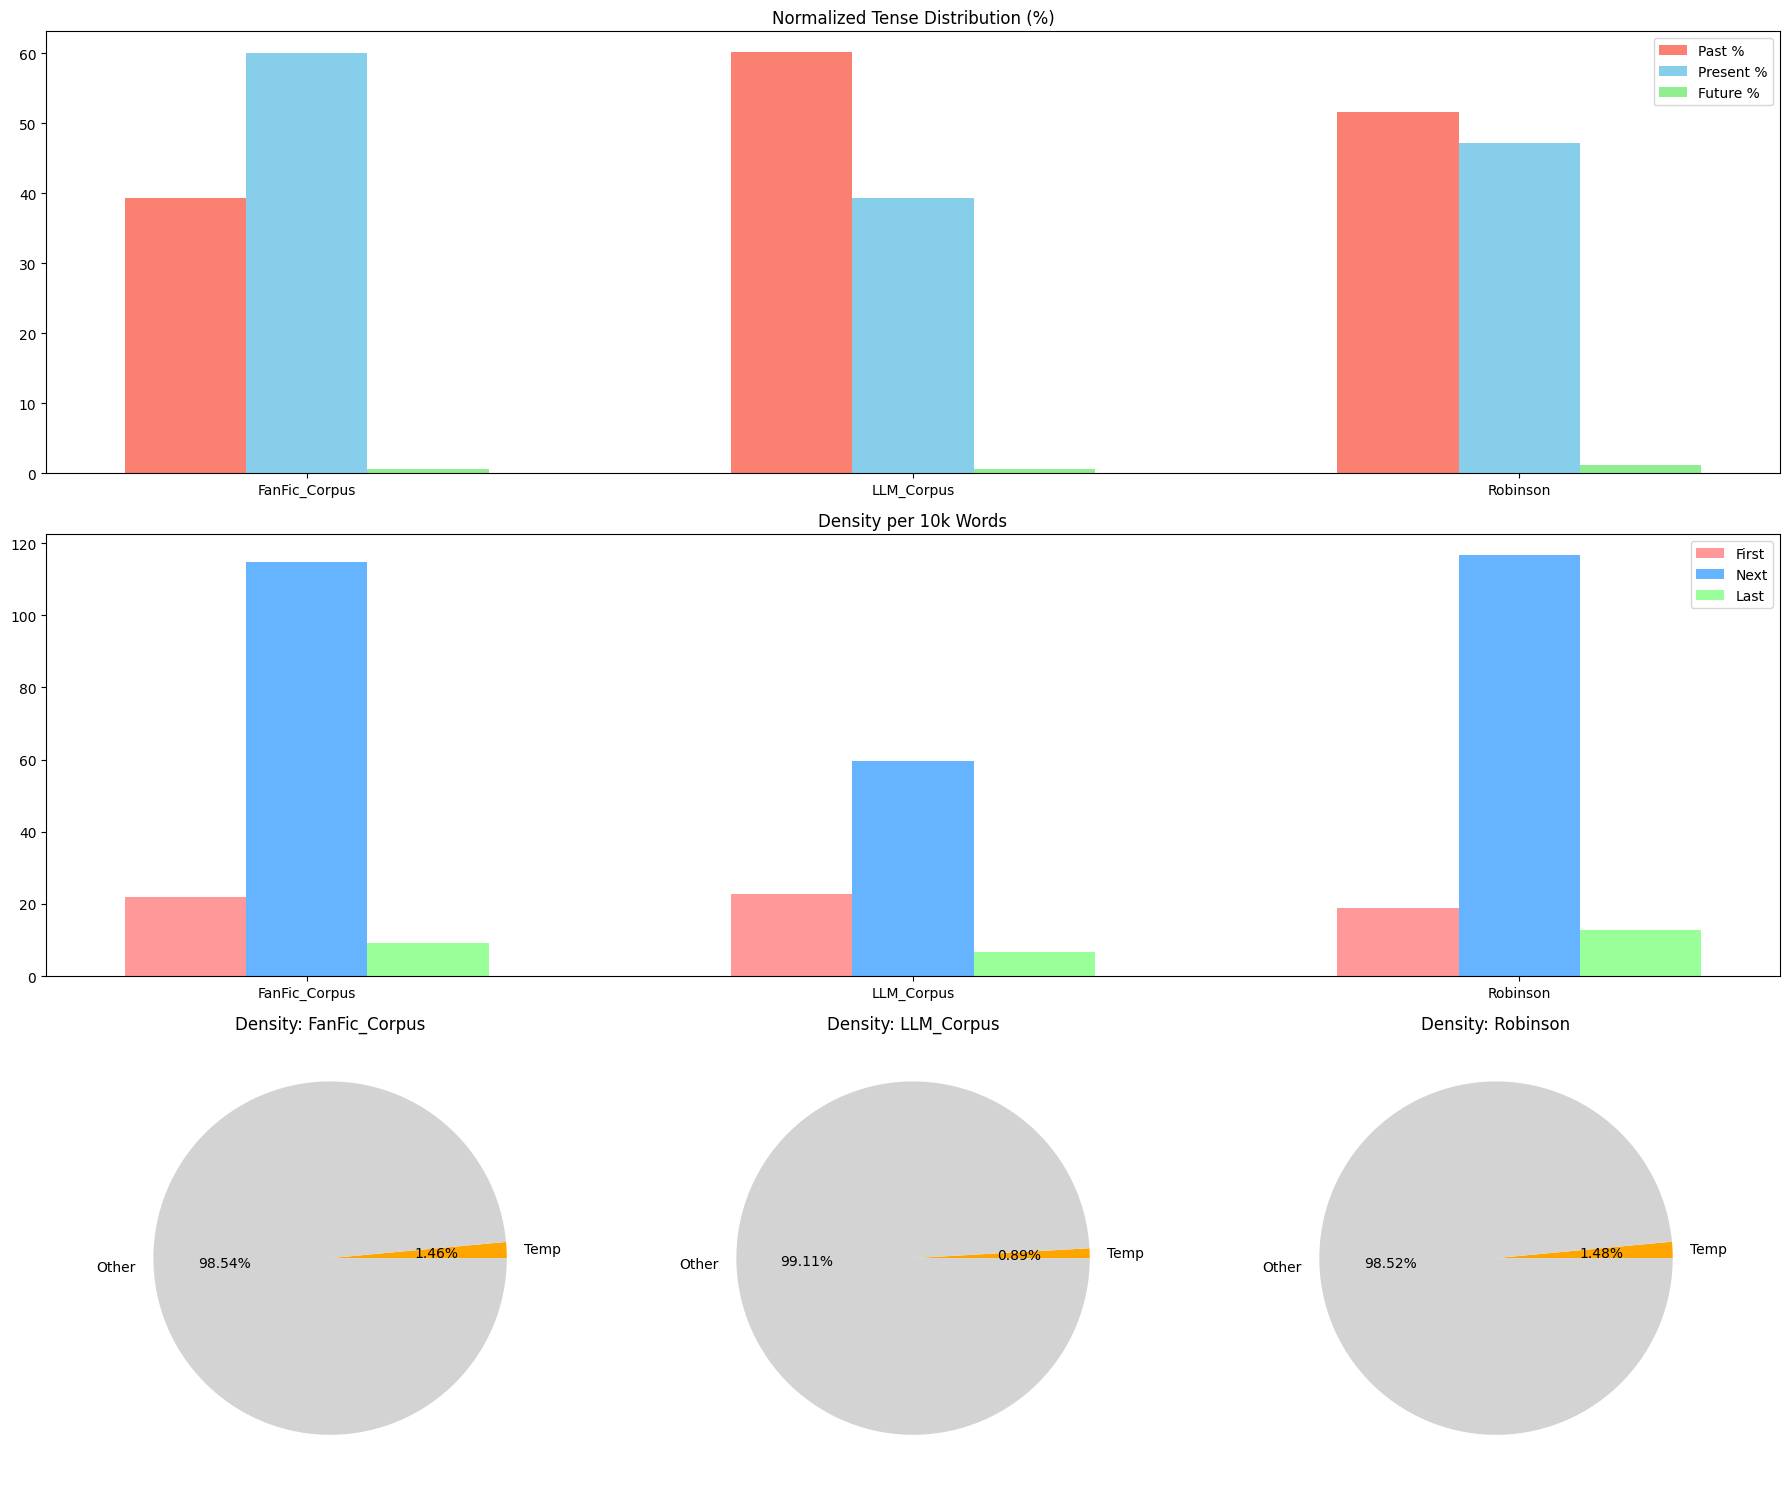

In [ ]:
import os
import re
import spacy
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Drive Bağlantısı
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/Text_files'
# Ana klasör isimlerin (Drive'daki ile birebir aynı olmalı)
CORPUS_FOLDERS = ['FanFic_Corpus', 'LLM_Corpus', 'Robinson']

OUTPUT_FOLDER = os.path.join(BASE_PATH, 'COMPARISON_RESULTS')
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# 2. Hızlı NLP Yüklemesi
try:
    nlp = spacy.load("en_core_web_md", disable=["ner", "parser", "lemmatizer", "textcat"])
except:
    !python -m spacy download en_core_web_md
    nlp = spacy.load("en_core_web_md", disable=["ner", "parser", "lemmatizer", "textcat"])

# Kelime Listeleri
first_keywords = ["at first", "at that moment", "at the beginning", "at the onset", "before", "commence", "choose", "first", "first of all", "from this point", "in the first place", "one day", "one evening", "one morning", "starting with", "to begin"]
next_keywords = ["a moment later", "after", "after a few days", "after a while", "after that", "afterwards", "all of a sudden", "as soon as", "at that very moment", "at times", "before long", "consequently", "during", "earlier", "eventually", "following", "formerly", "from time to time", "gradually", "henceforth", "in addition", "in the meantime", "in the past", "in time", "in turn", "later", "later on", "meanwhile", "momentarily", "next", "next week", "not a moment too soon", "not long after", "not long ago", "now", "occasionally", "once", "past", "periodically", "preceding", "presently", "previously", "prior to", "rarely", "right after", "second", "seldom", "shortly", "shortly after this", "since", "some of the time", "soon", "soon after", "suddenly", "then", "therefore", "third", "tomorrow", "up until that time", "when", "whenever", "yesterday"]
last_keywords = ["after a long time", "afterward", "at last", "at the end", "finally", "hereafter", "in conclusion", "in the end", "last of all", "lastly", "thereafter", "to conclude", "to finish", "ultimately", "until", "one day"]

def get_all_texts_recursively(root_folder):
    """Alt klasörler dahil tüm txt dosyalarını birleştirir."""
    combined_content = ""
    file_count = 0
    for root, dirs, files in os.walk(root_folder):
        for file in files:
            if file.endswith(".txt"):
                file_path = os.path.join(root, file)
                try:
                    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                        combined_content += f.read() + " "
                        file_count += 1
                except Exception as e:
                    print(f"Hata (Dosya Okuma): {file_path} -> {e}")
    return combined_content, file_count

def analyze_corpus_deep(folder_name):
    folder_path = os.path.join(BASE_PATH, folder_name)
    if not os.path.exists(folder_path):
        print(f"❌ Klasör bulunamadı: {folder_name}")
        return None

    print(f"🔍 {folder_name} taranıyor (alt klasörler dahil)...")
    full_text, count = get_all_texts_recursively(folder_path)

    if count == 0:
        print(f"⚠️ {folder_name} içinde hiç .txt dosyası bulunamadı!")
        return None

    print(f"📈 {folder_name}: {count} dosya birleştirildi. Analiz ediliyor...")

    # İstatistiksel örneklem (Hız için 500k karakter)
    sample_text = full_text[:500000]
    doc = nlp(sample_text)
    clean_text = sample_text.lower()
    total_words = len([t for t in doc if not t.is_punct])

    if total_words == 0: return None

    # Tense Analizi
    tenses = {"Past": 0, "Present": 0, "Future": 0}
    tenses["Future"] = len(re.findall(r"\b(will|shall|going\s+to)\b", clean_text))

    for token in doc:
        if token.pos_ in ["VERB", "AUX"]:
            if token.tag_ in ["VBD", "VBN"] or token.text.lower() in ["was", "were", "had"]:
                tenses["Past"] += 1
            else:
                tenses["Present"] += 1

    total_v = sum(tenses.values())
    tense_pct = {k: (v/total_v*100) if total_v > 0 else 0 for k,v in tenses.items()}

    # Temporal Density (Per 10k words)
    f_c = sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in set(first_keywords))
    n_c = sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in set(next_keywords))
    l_c = sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in set(last_keywords))

    return {
        "tense_pct": tense_pct,
        "cats_norm": {
            "First": (f_c/total_words*10000),
            "Next": (n_c/total_words*10000),
            "Last": (l_c/total_words*10000)
        },
        "tc": f_c + n_c + l_c,
        "tw": total_words
    }

# --- ÇALIŞTIRMA ---
results = {}
for c in CORPUS_FOLDERS:
    data = analyze_corpus_deep(c)
    if data:
        results[c] = data
        print(f"✅ {c} analizi başarıyla tamamlandı.")

# --- GÖRSELLEŞTİRME ---
if results:
    labels = list(results.keys())
    fig = plt.figure(figsize=(18, 15))
    x = np.arange(len(labels))

    # 1. Tense Bar
    ax1 = plt.subplot(3, 1, 1)
    ax1.bar(x-0.2, [results[l]['tense_pct']['Past'] for l in labels], 0.2, label='Past %', color='salmon')
    ax1.bar(x, [results[l]['tense_pct']['Present'] for l in labels], 0.2, label='Present %', color='skyblue')
    ax1.bar(x+0.2, [results[l]['tense_pct']['Future'] for l in labels], 0.2, label='Future %', color='lightgreen')
    ax1.set_xticks(x); ax1.set_xticklabels(labels); ax1.set_title("Normalized Tense Distribution (%)"); ax1.legend()

    # 2. Category Density
    ax2 = plt.subplot(3, 1, 2)
    ax2.bar(x-0.2, [results[l]['cats_norm']['First'] for l in labels], 0.2, label='First', color='#ff9999')
    ax2.bar(x, [results[l]['cats_norm']['Next'] for l in labels], 0.2, label='Next', color='#66b3ff')
    ax2.bar(x+0.2, [results[l]['cats_norm']['Last'] for l in labels], 0.2, label='Last', color='#99ff99')
    ax2.set_xticks(x); ax2.set_xticklabels(labels); ax2.set_title("Density per 10k Words"); ax2.legend()

    # 3. Pie Charts
    for i, label in enumerate(labels):
        axp = plt.subplot(3, len(labels), (2 * len(labels)) + i + 1)
        tc, tw = results[label]['tc'], results[label]['tw']
        axp.pie([tc, tw-tc], labels=['Temp', 'Other'], autopct='%1.2f%%', colors=['orange','lightgray'])
        axp.set_title(f"Density: {label}")

    plt.tight_layout()
    plt.show()
else:
    print("❌ Analiz edilecek veri bulunamadı!")

📂 FanFic_Corpus inceleniyor...
📂 LLM_Corpus inceleniyor...
📂 Robinson inceleniyor...


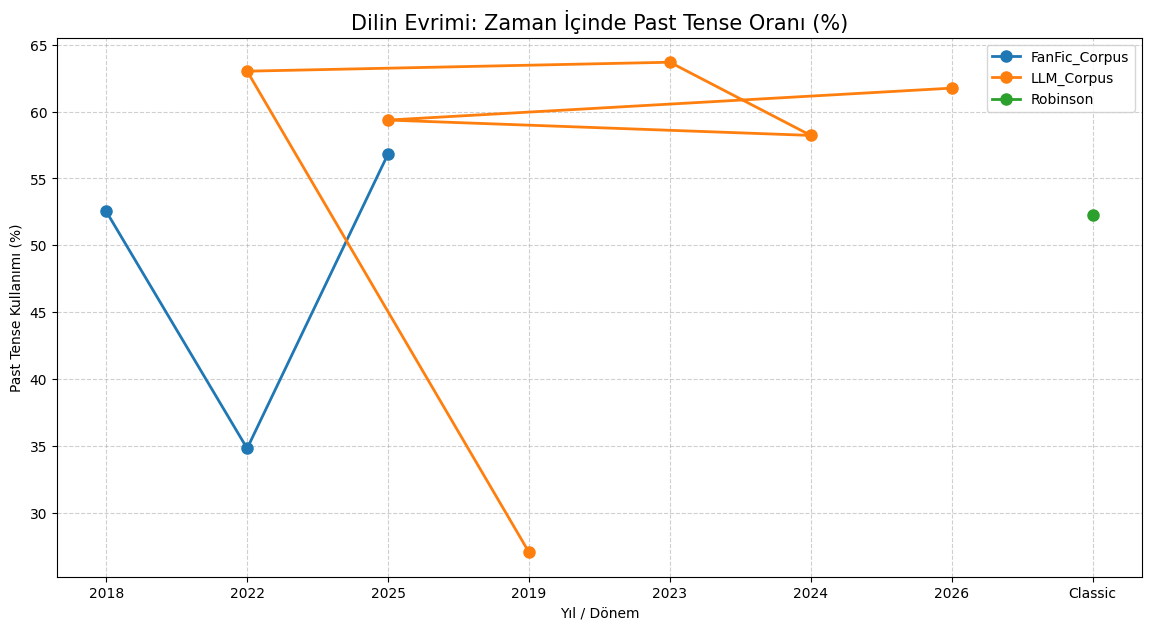

In [ ]:
import os
import re
import spacy
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Drive Bağlantısı
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/Text_files'
CORPUS_FOLDERS = ['FanFic_Corpus', 'LLM_Corpus', 'Robinson']

# Hızlı NLP Ayarı
try:
    nlp = spacy.load("en_core_web_md", disable=["ner", "parser", "lemmatizer"])
except:
    !python -m spacy download en_core_web_md
    nlp = spacy.load("en_core_web_md", disable=["ner", "parser", "lemmatizer"])

def extract_year_advanced(path_string, corpus_name):
    """Görüntülerdeki formata göre yıl çeker: (2024) veya _2018_"""
    if "Robinson" in corpus_name:
        return "Classic"

    # Parantez içi yıl (2024) veya alt tireli yıl _2018_ ara
    match = re.search(r"\(?(20[12][0-9])\)?", path_string)
    if match:
        return match.group(1)
    return None

def run_fixed_analysis():
    # Yapı: {Corpus: {Year: {"past": X, "total_v": Y}}}
    temporal_data = {c: {} for c in CORPUS_FOLDERS}

    for corpus in CORPUS_FOLDERS:
        root_path = os.path.join(BASE_PATH, corpus)
        if not os.path.exists(root_path):
            print(f"❌ Klasör bulunamadı: {corpus}")
            continue

        print(f"📂 {corpus} inceleniyor...")

        for root, dirs, files in os.walk(root_path):
            # Önce klasör isminden yıl bak (Örn: LLM subfolders)
            folder_year = extract_year_advanced(root, corpus)

            for file in files:
                if file.endswith(".txt"):
                    # Klasörde yoksa dosya ismine bak (Örn: FanFic files)
                    year = folder_year if folder_year else extract_year_advanced(file, corpus)

                    if not year:
                        continue # Yıl yoksa analize katma

                    file_path = os.path.join(root, file)
                    try:
                        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                            text = f.read()[:300000] # Hız için limit
                            doc = nlp(text)

                            past_count = 0
                            verbs_count = 0
                            for t in doc:
                                if t.pos_ in ["VERB", "AUX"]:
                                    verbs_count += 1
                                    if t.tag_ in ["VBD", "VBN"] or t.text.lower() in ["was","were","had"]:
                                        past_count += 1

                            if year not in temporal_data[corpus]:
                                temporal_data[corpus][year] = {"past": 0, "total_v": 0}

                            temporal_data[corpus][year]["past"] += past_count
                            temporal_data[corpus][year]["total_v"] += verbs_count
                    except Exception as e:
                        print(f"Dosya okuma hatası: {file}")
                        continue

    return temporal_data

# --- ÇALIŞTIR ---
results = run_fixed_analysis()

# --- GRAFİK ---
if results and any(results[c] for c in results):
    plt.figure(figsize=(14, 7))
    found_any = False

    for corpus, years_dict in results.items():
        if not years_dict: continue

        # Yılları sırala (Classic en başa, sonra kronolojik)
        sorted_years = sorted(years_dict.keys(), key=lambda x: (0, x) if x == "Classic" else (1, x))

        ratios = []
        valid_years = []
        for y in sorted_years:
            v = years_dict[y]['total_v']
            if v > 10: # Çok küçük dosyaları ele
                ratios.append((years_dict[y]['past'] / v) * 100)
                valid_years.append(y)

        if ratios:
            plt.plot(valid_years, ratios, marker='o', label=corpus, linewidth=2, markersize=8)
            found_any = True

    if found_any:
        plt.title("Dilin Evrimi: Zaman İçinde Past Tense Oranı (%)", fontsize=15)
        plt.ylabel("Past Tense Kullanımı (%)")
        plt.xlabel("Yıl / Dönem")
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        plt.show()
    else:
        print("Grafik çizilecek yeterli veri bulunamadı (Yıllar eşleşmedi mi?)")
else:
    print("Hiç veri toplanamadı. Lütfen BASE_PATH yolunu ve klasör isimlerini kontrol et.")

📂 FanFic_Corpus inceleniyor...
📂 LLM_Corpus inceleniyor...
📂 Robinson inceleniyor...


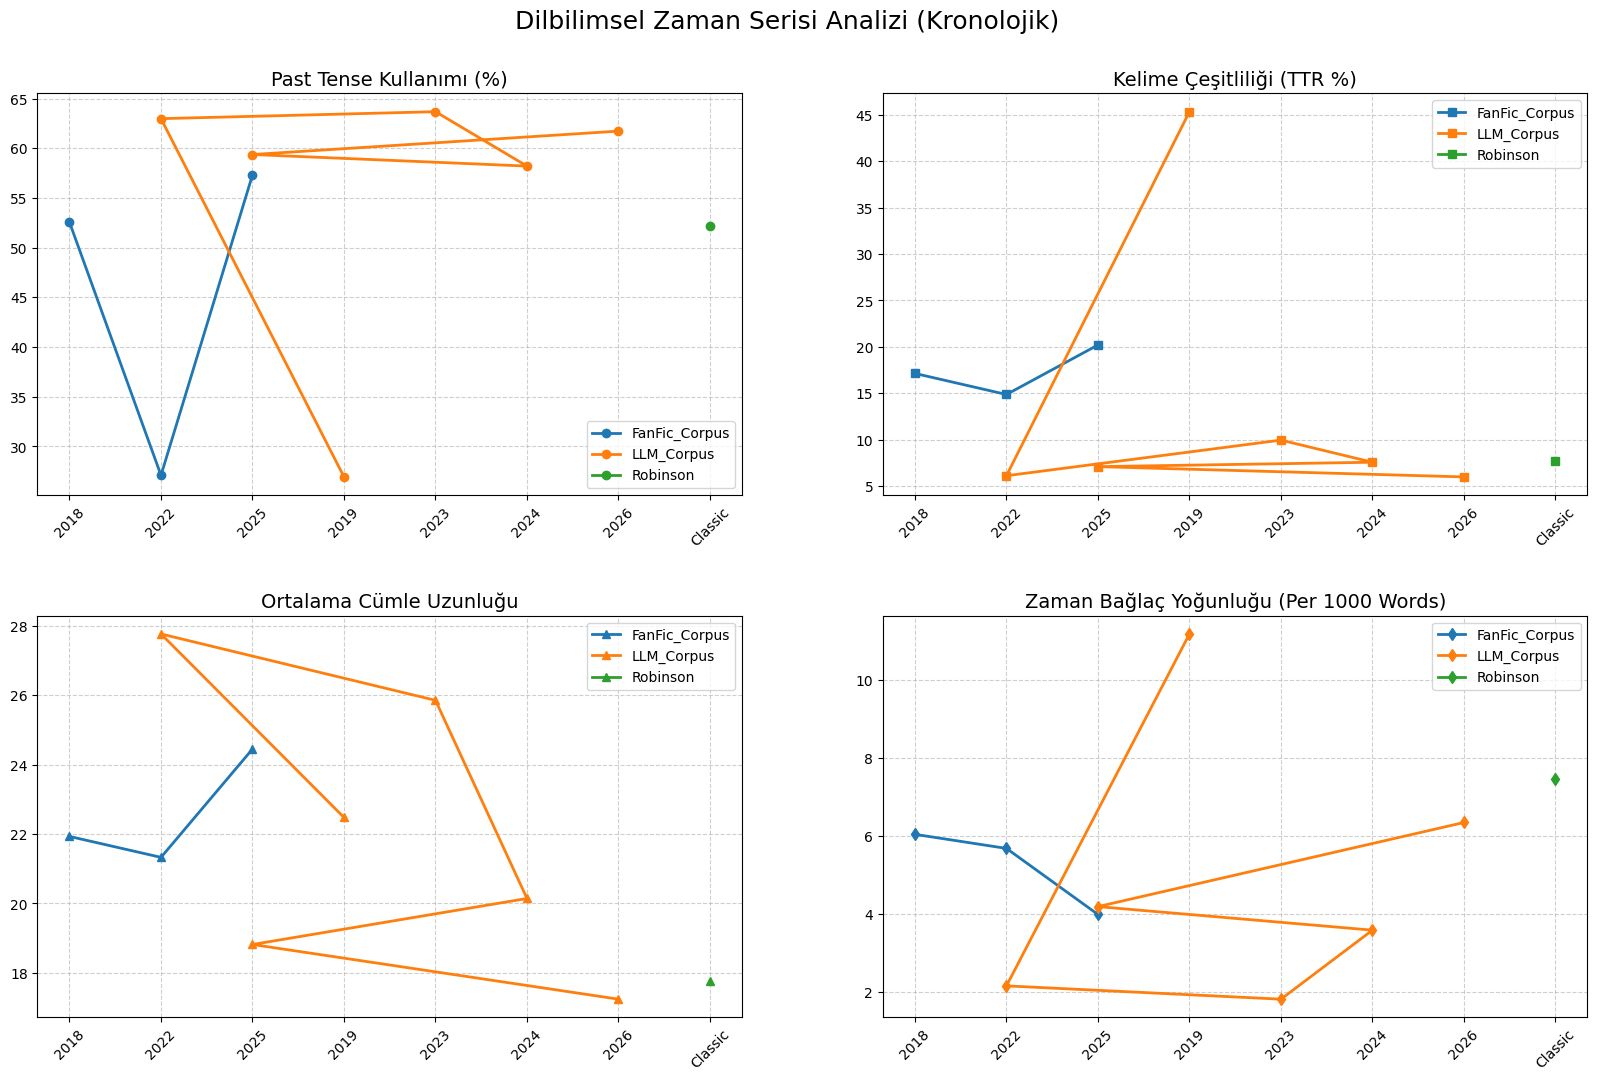

In [ ]:
import os
import re
import spacy
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Drive Bağlantısı
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/Text_files'
CORPUS_FOLDERS = ['FanFic_Corpus', 'LLM_Corpus', 'Robinson']

try:
    nlp = spacy.load("en_core_web_md", disable=["ner", "lemmatizer"])
except:
    !python -m spacy download en_core_web_md
    nlp = spacy.load("en_core_web_md", disable=["ner", "lemmatizer"])

def extract_year_advanced(path_string, corpus_name):
    if "Robinson" in corpus_name: return "Classic"
    match = re.search(r"\(?(20[12][0-9])\)?", path_string)
    return match.group(1) if match else None

# --- SIRALAMA ANAHTARI ---
def custom_sort_key(year_label):
    if year_label == "Classic":
        return 0  # Classic en başa
    try:
        return int(year_label) # Yıllar sayısal olarak sıralansın
    except:
        return 9999 # Bilinmeyenler sona

def run_final_analysis():
    data = {c: {} for c in CORPUS_FOLDERS}
    temp_keywords = ["first", "then", "after", "finally", "suddenly", "meanwhile", "later", "before", "next"]

    for corpus in CORPUS_FOLDERS:
        root_path = os.path.join(BASE_PATH, corpus)
        if not os.path.exists(root_path): continue
        print(f"📂 {corpus} inceleniyor...")

        for root, dirs, files in os.walk(root_path):
            folder_year = extract_year_advanced(root, corpus)
            for file in files:
                if file.endswith(".txt"):
                    year = folder_year if folder_year else extract_year_advanced(file, corpus)
                    if not year: continue

                    try:
                        with open(os.path.join(root, file), 'r', encoding='utf-8', errors='ignore') as f:
                            text = f.read()[:200000]
                            doc = nlp(text)

                            words = [t.text.lower() for t in doc if not t.is_punct and not t.is_space]
                            if not words: continue

                            # Analizler
                            past_c = sum(1 for t in doc if t.pos_ in ["VERB", "AUX"] and (t.tag_ in ["VBD", "VBN"] or t.text.lower() in ["was","were","had"]))
                            verb_c = sum(1 for t in doc if t.pos_ in ["VERB", "AUX"])
                            sent_lens = [len(sent) for sent in doc.sents]
                            temp_c = sum(1 for w in words if w in temp_keywords)

                            if year not in data[corpus]:
                                data[corpus][year] = {"past":0, "verbs":0, "words":0, "unique":set(), "sent_len":[], "temp":0}

                            d = data[corpus][year]
                            d["past"] += past_c
                            d["verbs"] += verb_c
                            d["words"] += len(words)
                            d["unique"].update(words)
                            d["sent_len"].extend(sent_lens)
                            d["temp"] += temp_c
                    except: continue
    return data

results = run_final_analysis()

# --- GRAFİKLER ---
if results:
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    plt.subplots_adjust(hspace=0.3, wspace=0.2)

    # Tüm corpuslardaki yılları topla ve ortak bir kronolojik sıra oluştur
    all_years = set()
    for c in results: all_years.update(results[c].keys())
    chronological_years = sorted(list(all_years), key=custom_sort_key)

    for corpus in CORPUS_FOLDERS:
        if not results[corpus]: continue

        # O corpusa ait yılları kronolojik sıraya göre diz
        c_years = [y for y in chronological_years if y in results[corpus]]

        # 1. Past Tense
        past_ratios = [(results[corpus][y]['past']/results[corpus][y]['verbs']*100) if results[corpus][y]['verbs']>0 else 0 for y in c_years]
        axes[0,0].plot(c_years, past_ratios, marker='o', label=corpus, linewidth=2)
        axes[0,0].set_title("Past Tense Kullanımı (%)", fontsize=14)

        # 2. Lexical Diversity (Benzersiz kelime / Toplam kelime)
        lex_div = [(len(results[corpus][y]['unique'])/results[corpus][y]['words']*100) if results[corpus][y]['words']>0 else 0 for y in c_years]
        axes[0,1].plot(c_years, lex_div, marker='s', label=corpus, linewidth=2)
        axes[0,1].set_title("Kelime Çeşitliliği (TTR %)", fontsize=14)

        # 3. Avg Sentence Length
        avg_sents = [np.mean(results[corpus][y]['sent_len']) if results[corpus][y]['sent_len'] else 0 for y in c_years]
        axes[1,0].plot(c_years, avg_sents, marker='^', label=corpus, linewidth=2)
        axes[1,0].set_title("Ortalama Cümle Uzunluğu", fontsize=14)

        # 4. Temporal Density
        temp_dens = [(results[corpus][y]['temp']/results[corpus][y]['words']*1000) if results[corpus][y]['words']>0 else 0 for y in c_years]
        axes[1,1].plot(c_years, temp_dens, marker='d', label=corpus, linewidth=2)
        axes[1,1].set_title("Zaman Bağlaç Yoğunluğu (Per 1000 Words)", fontsize=14)

    for ax in axes.flat:
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.tick_params(axis='x', rotation=45) # Yıllar birbirine binmesin diye yan yatırdım

    plt.suptitle("Dilbilimsel Zaman Serisi Analizi (Kronolojik)", fontsize=18, y=0.95)
    plt.show()

📂 FanFic_Corpus okunuyor...
📂 LLM_Corpus okunuyor...
📂 Robinson okunuyor...


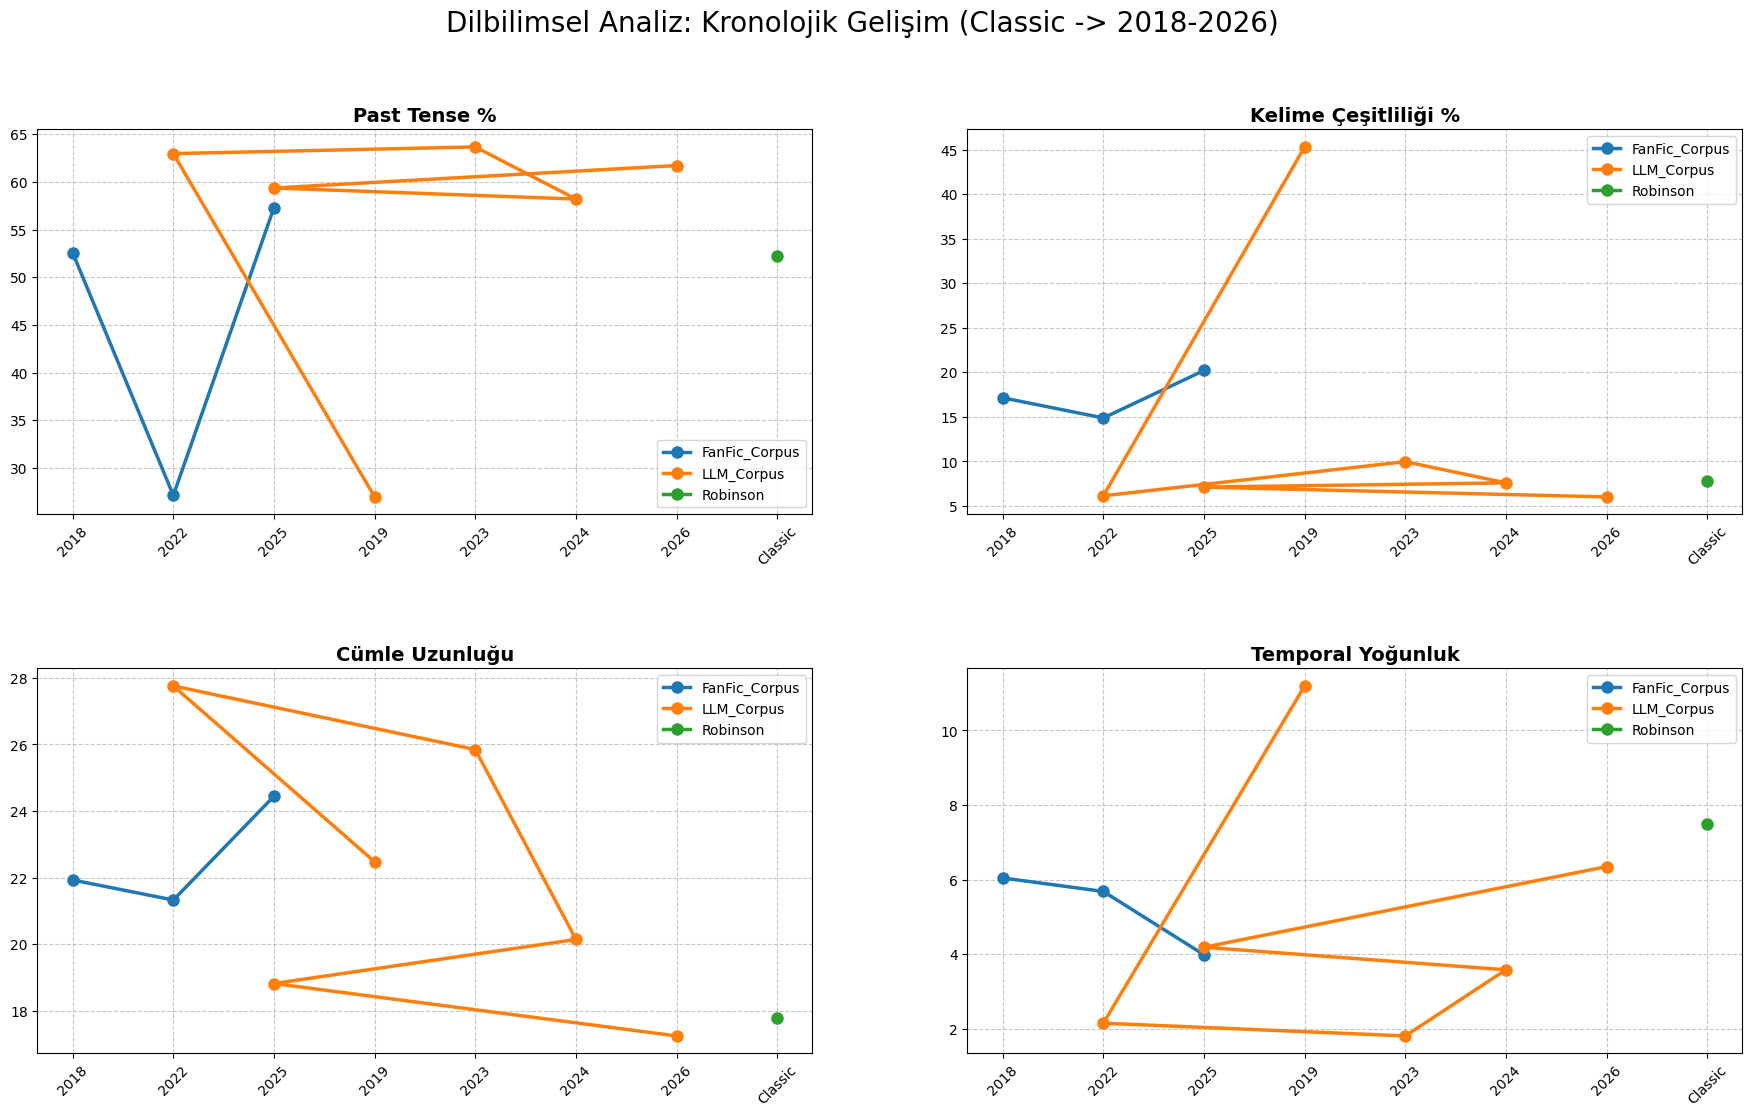

In [ ]:
import os
import re
import spacy
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Drive Bağlantısı
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/Text_files'
CORPUS_FOLDERS = ['FanFic_Corpus', 'LLM_Corpus', 'Robinson']

try:
    nlp = spacy.load("en_core_web_md", disable=["ner", "lemmatizer"])
except:
    !python -m spacy download en_core_web_md
    nlp = spacy.load("en_core_web_md", disable=["ner", "lemmatizer"])

def extract_year_advanced(path_string, corpus_name):
    if "Robinson" in corpus_name: return "Classic"
    # Hem klasör hem dosya ismindeki yılları avla
    match = re.search(r"(201[8-9]|202[0-7])", path_string)
    return match.group(1) if match else None

def run_unified_analysis():
    data = {c: {} for c in CORPUS_FOLDERS}
    temp_keywords = ["first", "then", "after", "finally", "suddenly", "meanwhile", "later", "before", "next"]

    for corpus in CORPUS_FOLDERS:
        root_path = os.path.join(BASE_PATH, corpus)
        if not os.path.exists(root_path): continue
        print(f"📂 {corpus} okunuyor...")

        for root, dirs, files in os.walk(root_path):
            folder_year = extract_year_advanced(root, corpus)
            for file in files:
                if file.endswith(".txt"):
                    year = folder_year if folder_year else extract_year_advanced(file, corpus)
                    if not year: continue

                    try:
                        with open(os.path.join(root, file), 'r', encoding='utf-8', errors='ignore') as f:
                            text = f.read()[:200000]
                            doc = nlp(text)

                            words = [t.text.lower() for t in doc if not t.is_punct and not t.is_space]
                            if not words: continue

                            # İstatistikler
                            past_c = sum(1 for t in doc if t.pos_ in ["VERB", "AUX"] and (t.tag_ in ["VBD", "VBN"] or t.text.lower() in ["was","were","had"]))
                            verb_c = sum(1 for t in doc if t.pos_ in ["VERB", "AUX"])
                            sent_lens = [len(sent) for sent in doc.sents]
                            temp_c = sum(1 for w in words if w in temp_keywords)

                            if year not in data[corpus]:
                                data[corpus][year] = {"past":0, "verbs":0, "words":0, "unique":set(), "sent_len":[], "temp":0}

                            d = data[corpus][year]
                            d["past"] += past_c
                            d["verbs"] += verb_c
                            d["words"] += len(words)
                            d["unique"].update(words)
                            d["sent_len"].extend(sentence_lengths if 'sentence_lengths' in locals() else sent_lens)
                            d["temp"] += temp_c
                    except: continue
    return data

results = run_unified_analysis()

# --- PROFESYONEL KRONOLOJİK ÇİZİM ---
if results:
    # 1. Tüm yılları topla ve benzersiz bir sıralı liste yap
    all_years_raw = set()
    for c in results: all_years_raw.update(results[c].keys())

    # Classic'i ayır, diğerlerini sayısal sırala
    has_classic = "Classic" in all_years_raw
    sorted_years = sorted([int(y) for y in all_years_raw if y.isdigit()])
    final_x_axis = (["Classic"] if has_classic else []) + [str(y) for y in sorted_years]

    fig, axes = plt.subplots(2, 2, figsize=(22, 12))
    plt.subplots_adjust(hspace=0.4)

    metrics = [
        ("Past Tense %", lambda d: (d['past']/d['verbs']*100) if d['verbs']>0 else 0),
        ("Kelime Çeşitliliği %", lambda d: (len(d['unique'])/d['words']*100) if d['words']>0 else 0),
        ("Cümle Uzunluğu", lambda d: np.mean(d['sent_len']) if d['sent_len'] else 0),
        ("Temporal Yoğunluk", lambda d: (d['temp']/d['words']*1000) if d['words']>0 else 0)
    ]

    for idx, (title, func) in enumerate(metrics):
        ax = axes[idx//2, idx%2]
        for corpus in CORPUS_FOLDERS:
            # Sadece bu corpus'ta olan yılları ve değerlerini çek
            x_vals = []
            y_vals = []
            for year in final_x_axis:
                if year in results[corpus]:
                    x_vals.append(year)
                    y_vals.append(func(results[corpus][year]))

            if x_vals:
                ax.plot(x_vals, y_vals, marker='o', label=corpus, linewidth=2.5, markersize=8)

        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.legend()
        # X eksenini tüm yıllara göre sabitle (Boş kalsa bile yerleri belli olsun)
        ax.set_xticks(final_x_axis)
        ax.tick_params(axis='x', rotation=45)

    plt.suptitle("Dilbilimsel Analiz: Kronolojik Gelişim (Classic -> 2018-2026)", fontsize=20, y=0.98)
    plt.show()

📂 FanFic_Corpus okunuyor...
📂 LLM_Corpus okunuyor...
📂 Robinson okunuyor...


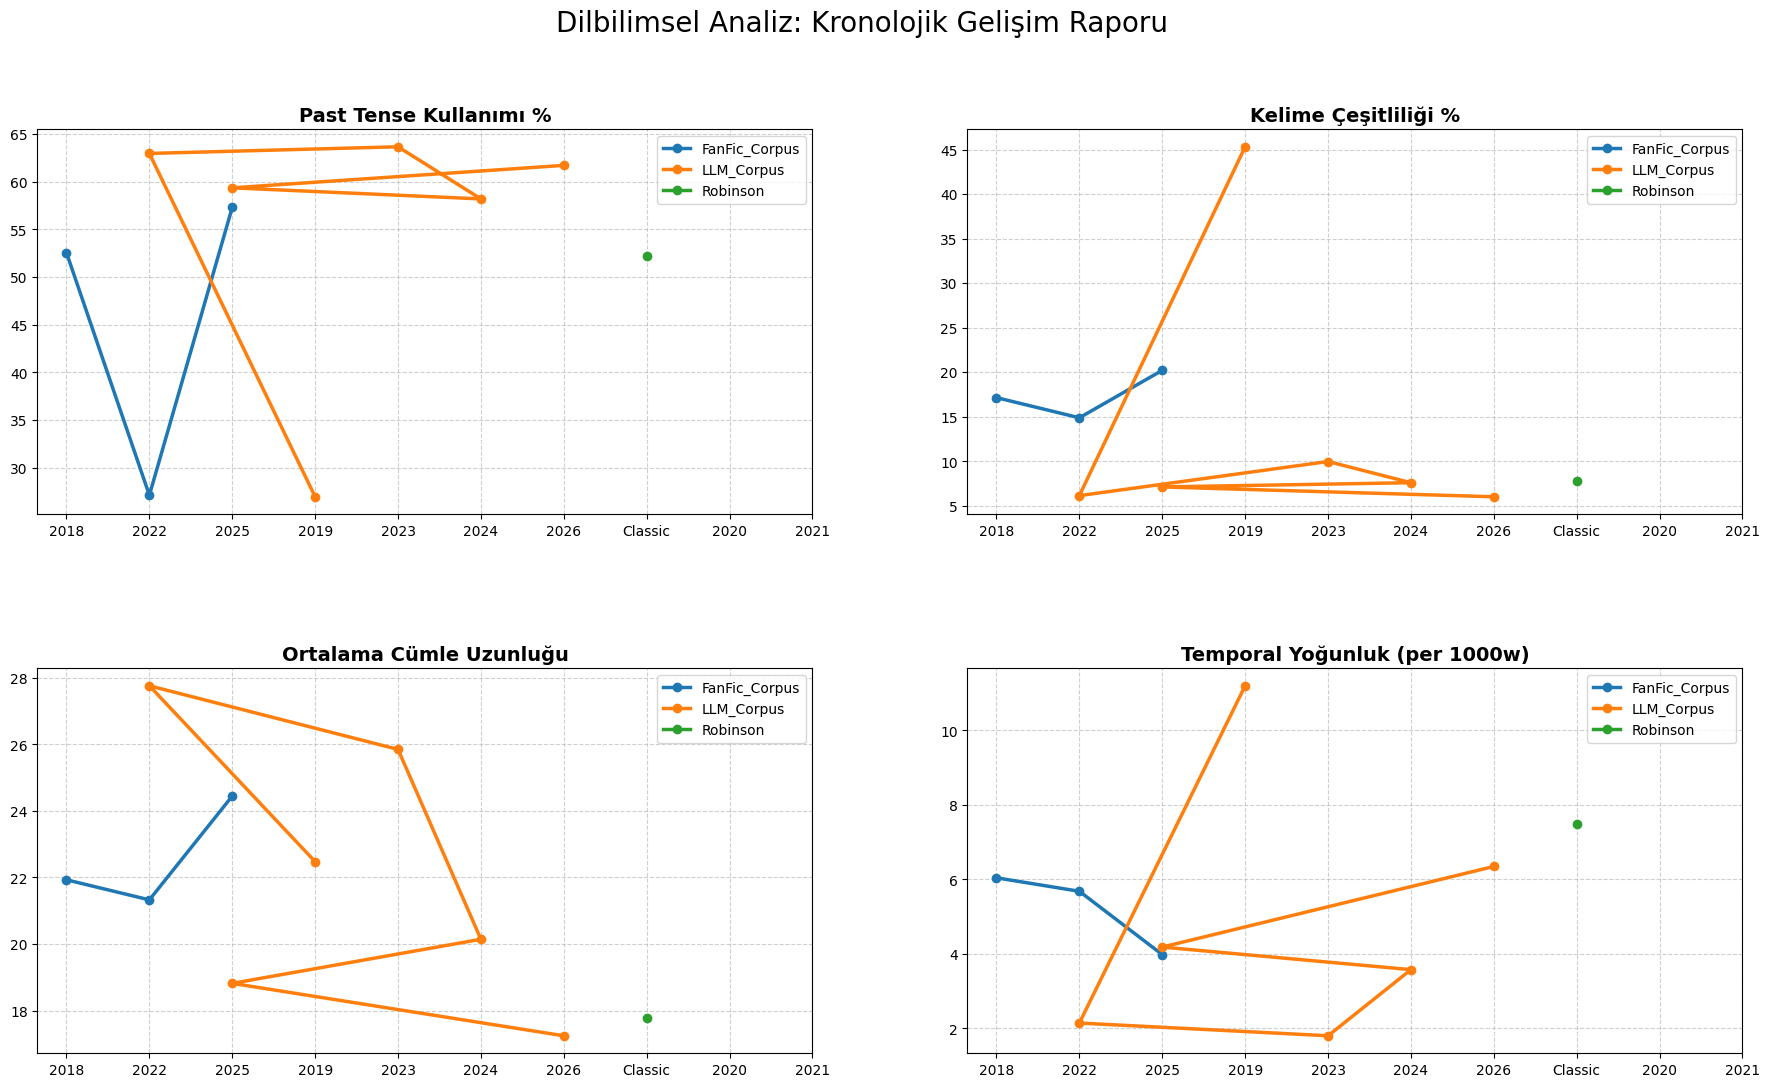

In [ ]:
import os
import re
import spacy
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Drive Bağlantısı
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/Text_files'
CORPUS_FOLDERS = ['FanFic_Corpus', 'LLM_Corpus', 'Robinson']

try:
    nlp = spacy.load("en_core_web_md", disable=["ner", "lemmatizer"])
except:
    !python -m spacy download en_core_web_md
    nlp = spacy.load("en_core_web_md", disable=["ner", "lemmatizer"])

def extract_year_advanced(path_string, corpus_name):
    if "Robinson" in corpus_name: return "Classic"
    match = re.search(r"(201[8-9]|202[0-7])", path_string)
    return match.group(1) if match else None

def run_unified_analysis():
    data = {c: {} for c in CORPUS_FOLDERS}
    temp_keywords = ["first", "then", "after", "finally", "suddenly", "meanwhile", "later", "before", "next"]

    for corpus in CORPUS_FOLDERS:
        root_path = os.path.join(BASE_PATH, corpus)
        if not os.path.exists(root_path): continue
        print(f"📂 {corpus} okunuyor...")

        for root, dirs, files in os.walk(root_path):
            folder_year = extract_year_advanced(root, corpus)
            for file in files:
                if file.endswith(".txt"):
                    year = folder_year if folder_year else extract_year_advanced(file, corpus)
                    if not year: continue

                    try:
                        with open(os.path.join(root, file), 'r', encoding='utf-8', errors='ignore') as f:
                            text = f.read()[:200000]
                            doc = nlp(text)

                            words = [t.text.lower() for t in doc if not t.is_punct and not t.is_space]
                            if not words: continue

                            past_c = sum(1 for t in doc if t.pos_ in ["VERB", "AUX"] and (t.tag_ in ["VBD", "VBN"] or t.text.lower() in ["was","were","had"]))
                            verb_c = sum(1 for t in doc if t.pos_ in ["VERB", "AUX"])
                            sent_lens = [len(list(sent)) for sent in doc.sents]
                            temp_c = sum(1 for w in words if w in temp_keywords)

                            if year not in data[corpus]:
                                data[corpus][year] = {"past":0, "verbs":0, "words":0, "unique":set(), "sent_len":[], "temp":0}

                            d = data[corpus][year]
                            d["past"] += past_c
                            d["verbs"] += verb_c
                            d["words"] += len(words)
                            d["unique"].update(words)
                            d["sent_len"].extend(sent_lens)
                            d["temp"] += temp_c
                    except: continue
    return data

results = run_unified_analysis()

# --- BURASI KRİTİK: X EKSENİNİ ELİMİZLE DİZİYORUZ ---
# Robinson en başta, sonra 2018'den 2026'ya tam liste
fixed_timeline = ["Classic", "2018", "2019", "2020", "2021", "2022", "2023", "2024", "2025", "2026"]

if results:
    fig, axes = plt.subplots(2, 2, figsize=(22, 12))
    plt.subplots_adjust(hspace=0.4)

    metrics = [
        ("Past Tense Kullanımı %", lambda d: (d['past']/d['verbs']*100) if d['verbs']>0 else 0),
        ("Kelime Çeşitliliği %", lambda d: (len(d['unique'])/d['words']*100) if d['words']>0 else 0),
        ("Ortalama Cümle Uzunluğu", lambda d: np.mean(d['sent_len']) if d['sent_len'] else 0),
        ("Temporal Yoğunluk (per 1000w)", lambda d: (d['temp']/d['words']*1000) if d['words']>0 else 0)
    ]

    for idx, (title, func) in enumerate(metrics):
        ax = axes[idx//2, idx%2]

        for corpus in CORPUS_FOLDERS:
            # Sadece bu corpus için verisi olan yılları timeline sırasıyla çek
            plot_x = []
            plot_y = []

            for year in fixed_timeline:
                if year in results[corpus]:
                    plot_x.append(year)
                    plot_y.append(func(results[corpus][year]))

            if plot_x:
                # 'marker' ve 'linewidth' ile çizgileri belirginleştirdik
                ax.plot(plot_x, plot_y, marker='o', label=corpus, linewidth=2.5)

        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xticks(fixed_timeline) # X eksenini tüm timeline'a zorla
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend()

    plt.suptitle("Dilbilimsel Analiz: Kronolojik Gelişim Raporu", fontsize=20, y=0.98)
    plt.show()
else:
    print("Veri çekilemedi, klasör isimlerini kontrol et!")

In [ ]:
# --- ANALİZ VE ZİKZAKSIZ ÇİZİM ---
def run_final_chronological_analysis():
    # results[corpus][year_int]
    data = {c: {} for c in CORPUS_FOLDERS}

    for corpus in CORPUS_FOLDERS:
        root_path = os.path.join(BASE_PATH, corpus)
        if not os.path.exists(root_path): continue
        print(f"📂 {corpus} okunuyor...")

        for root, dirs, files in os.walk(root_path):
            # Yılı sayıya çeviriyoruz (Classic=1719, diğerleri 2018, 2019...)
            year = get_year_numeric(root, corpus)

            for file in files:
                if file.endswith(".txt"):
                    f_year = year if year is not None else get_year_numeric(file, corpus)
                    if f_year is None: continue

                    try:
                        with open(os.path.join(root, file), 'r', encoding='utf-8', errors='ignore') as f:
                            doc = nlp(f.read()[:200000])
                            # Üstteki cell'de tanımladığın listeyi direkt kullanıyoruz!
                            words = [t.text.lower() for t in doc if not t.is_punct and not t.is_space]
                            if not words: continue

                            if f_year not in data[corpus]:
                                data[corpus][f_year] = {"past":0, "verbs":0, "words":0, "u":set(), "s_len":[], "tmp":0}

                            d = data[corpus][f_year]
                            d["past"] += sum(1 for t in doc if t.pos_ in ["VERB", "AUX"] and (t.tag_ in ["VBD", "VBN"] or t.text.lower() in ["was","were","had"]))
                            d["verbs"] += sum(1 for t in doc if t.pos_ in ["VERB", "AUX"])
                            d["words"] += len(words)
                            d["u"].update(words)
                            d["s_len"].extend([len(sent) for sent in doc.sents])
                            # BURADA: Senin üst cell'deki 'temporal_keywords' listeni kullanıyor
                            d["tmp"] += sum(1 for w in words if w in temporal_keywords)
                    except: continue
    return data

res = run_final_chronological_analysis()

# --- GRAFİK: MATEMATİKSEL SIRALAMA ---
if res:
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    metrics = [
        ("Past Tense %", lambda d: (d['past']/d['verbs']*100) if d['verbs']>0 else 0),
        ("Lexical Diversity %", lambda d: (len(d['u'])/d['words']*100) if d['words']>0 else 0),
        ("Avg Sentence Length", lambda d: np.mean(d['s_len']) if d['s_len'] else 0),
        ("Temporal Density", lambda d: (d['tmp']/d['words']*1000) if d['words']>0 else 0)
    ]

    for i, (title, func) in enumerate(metrics):
        ax = axes[i//2, i%2]
        for corpus in CORPUS_FOLDERS:
            # ÖNEMLİ: Yılları sayısal olarak küçükten büyüğe sıralıyoruz
            sorted_years = sorted(res[corpus].keys())
            if not sorted_years: continue

            y_values = [func(res[corpus][y]) for y in sorted_years]
            # X eksenini sayısal liste olarak veriyoruz -> ZİKZAK İMKANSIZ
            ax.plot(sorted_years, y_values, marker='o', label=corpus, linewidth=2.5)

        ax.set_title(title, fontweight='bold', fontsize=14)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend()

        # 1719'u görsel olarak "Classic" yap, diğerleri sayı kalsın
        ax.set_xticks(sorted(list(set([y for c in res for y in res[c].keys()]))))
        labels = [ax.get_xticklabels()] # dummy
        ax.set_xticklabels(["Classic" if int(tick.get_text()) == 1719 else tick.get_text() for tick in ax.get_xticklabels()])

    plt.suptitle("Dilbilimsel Kronolojik Analiz (Final)", fontsize=18)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

📂 FanFic_Corpus okunuyor...


NameError: name 'get_year_numeric' is not defined

📂 FanFic_Corpus okunuyor ve analiz ediliyor...
📂 LLM_Corpus okunuyor ve analiz ediliyor...
📂 Robinson okunuyor ve analiz ediliyor...


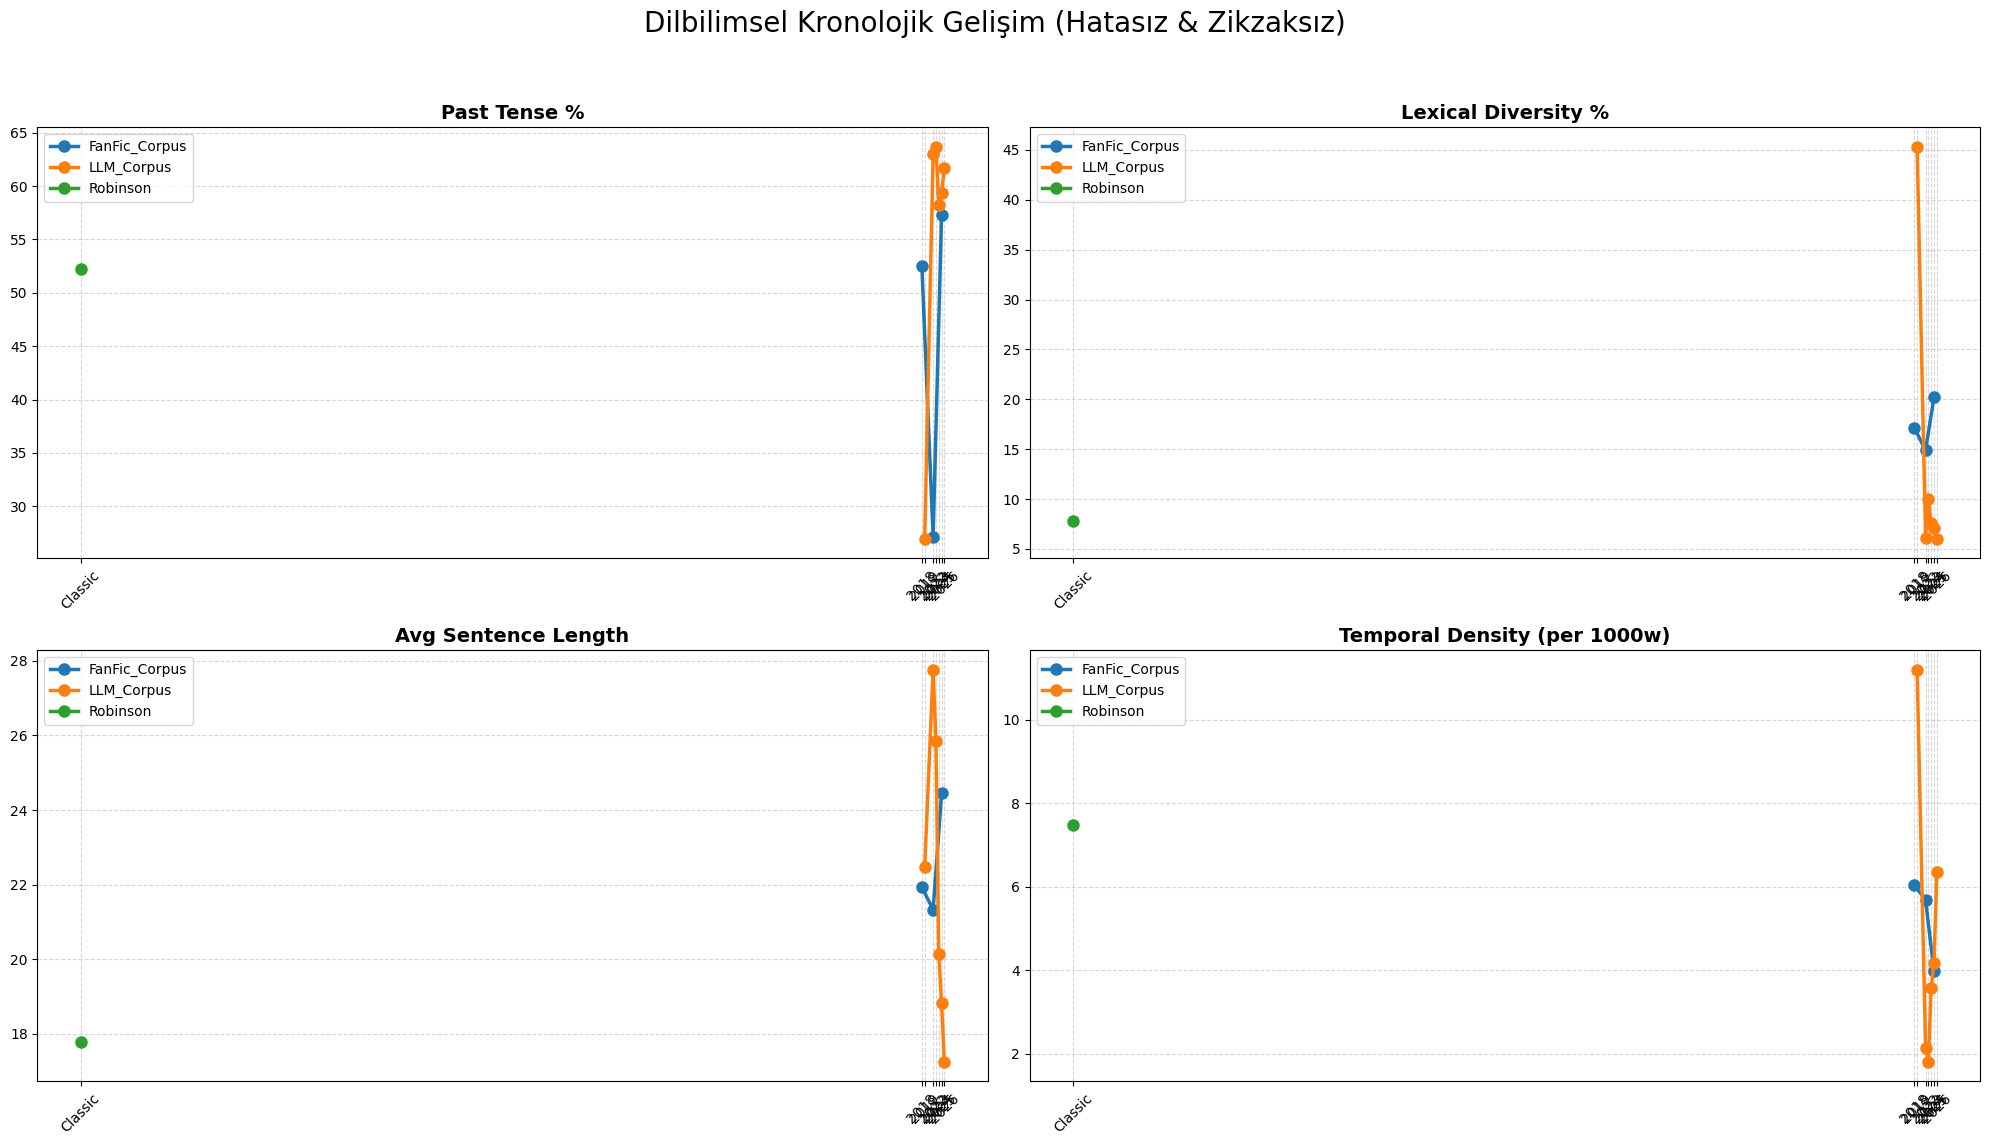

In [ ]:
import os
import re
import spacy
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Drive ve NLP Hazırlığı
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

try:
    nlp = spacy.load("en_core_web_md", disable=["ner", "lemmatizer"])
except:
    !python -m spacy download en_core_web_md
    nlp = spacy.load("en_core_web_md", disable=["ner", "lemmatizer"])

# --- TÜM PARAMETRELER VE FONKSİYONLAR BURADA ---
BASE_PATH = '/content/drive/MyDrive/Text_files'
CORPUS_FOLDERS = ['FanFic_Corpus', 'LLM_Corpus', 'Robinson']

# Üst cell'lerde varsa bile buraya tekrar ekledik ki hata vermesin
my_temp_keywords = ["first", "then", "after", "finally", "suddenly", "meanwhile", "later", "before", "next"]

def get_year_numeric_fixed(path_str, corpus):
    """Klasör veya dosyadan yılı sayı olarak çeker."""
    if "Robinson" in corpus: return 1719
    match = re.search(r"(201[8-9]|202[0-7])", path_str)
    return int(match.group(1)) if match else None

def run_mega_analysis_unified():
    # Yapı: {corpus: {year_int: data}}
    analysis_results = {c: {} for c in CORPUS_FOLDERS}

    for corpus in CORPUS_FOLDERS:
        root_path = os.path.join(BASE_PATH, corpus)
        if not os.path.exists(root_path):
            print(f"❌ Klasör yok: {root_path}")
            continue

        print(f"📂 {corpus} okunuyor ve analiz ediliyor...")
        for root, dirs, files in os.walk(root_path):
            dir_year = get_year_numeric_fixed(root, corpus)
            for file in files:
                if file.endswith(".txt"):
                    f_year = dir_year if dir_year is not None else get_year_numeric_fixed(file, corpus)
                    if f_year is None: continue

                    try:
                        with open(os.path.join(root, file), 'r', encoding='utf-8', errors='ignore') as f:
                            doc = nlp(f.read()[:200000])
                            words = [t.text.lower() for t in doc if not t.is_punct and not t.is_space]
                            if not words: continue

                            if f_year not in analysis_results[corpus]:
                                analysis_results[corpus][f_year] = {"past":0, "verbs":0, "words":0, "u":set(), "s_len":[], "tmp":0}

                            res_node = analysis_results[corpus][f_year]
                            res_node["past"] += sum(1 for t in doc if t.pos_ in ["VERB", "AUX"] and (t.tag_ in ["VBD", "VBN"] or t.text.lower() in ["was","were","had"]))
                            res_node["verbs"] += sum(1 for t in doc if t.pos_ in ["VERB", "AUX"])
                            res_node["words"] += len(words)
                            res_node["u"].update(words)
                            res_node["s_len"].extend([len(sent) for sent in doc.sents])
                            res_node["tmp"] += sum(1 for w in words if w in my_temp_keywords)
                    except: continue
    return analysis_results

# --- EXECUTION ---
final_results = run_mega_analysis_unified()

# --- PLOTTING ---
if final_results:
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    metrics_list = [
        ("Past Tense %", lambda d: (d['past']/d['verbs']*100) if d['verbs']>0 else 0),
        ("Lexical Diversity %", lambda d: (len(d['u'])/d['words']*100) if d['words']>0 else 0),
        ("Avg Sentence Length", lambda d: np.mean(d['s_len']) if d['s_len'] else 0),
        ("Temporal Density (per 1000w)", lambda d: (d['tmp']/d['words']*1000) if d['words']>0 else 0)
    ]

    for i, (title, func) in enumerate(metrics_list):
        ax = axes[i//2, i%2]
        for corpus in CORPUS_FOLDERS:
            years = sorted(final_results[corpus].keys())
            if not years: continue

            y_vals = [func(final_results[corpus][y]) for y in years]

            # plot'a doğrudan sayısal yıllar gidiyor (1719, 2018, 2019...)
            ax.plot(years, y_vals, marker='o', label=corpus, linewidth=2.5, markersize=8)

        ax.set_title(title, fontweight='bold', fontsize=14)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend()

        # X eksenini adam etme
        all_x = sorted(list(set([y for c in final_results for y in final_results[c].keys()])))
        ax.set_xticks(all_x)
        # 1719 yerine "Classic" yaz, gerisi yıl olarak kalsın
        ax.set_xticklabels(["Classic" if y == 1719 else str(y) for y in all_x], rotation=45)

    plt.suptitle("Dilbilimsel Kronolojik Gelişim (Hatasız & Zikzaksız)", fontsize=20, y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("Veri toplanamadı. Yolları ve klasör isimlerini kontrol et!")

📂 FanFic_Corpus analiz ediliyor...
📂 LLM_Corpus analiz ediliyor...
📂 Robinson analiz ediliyor...


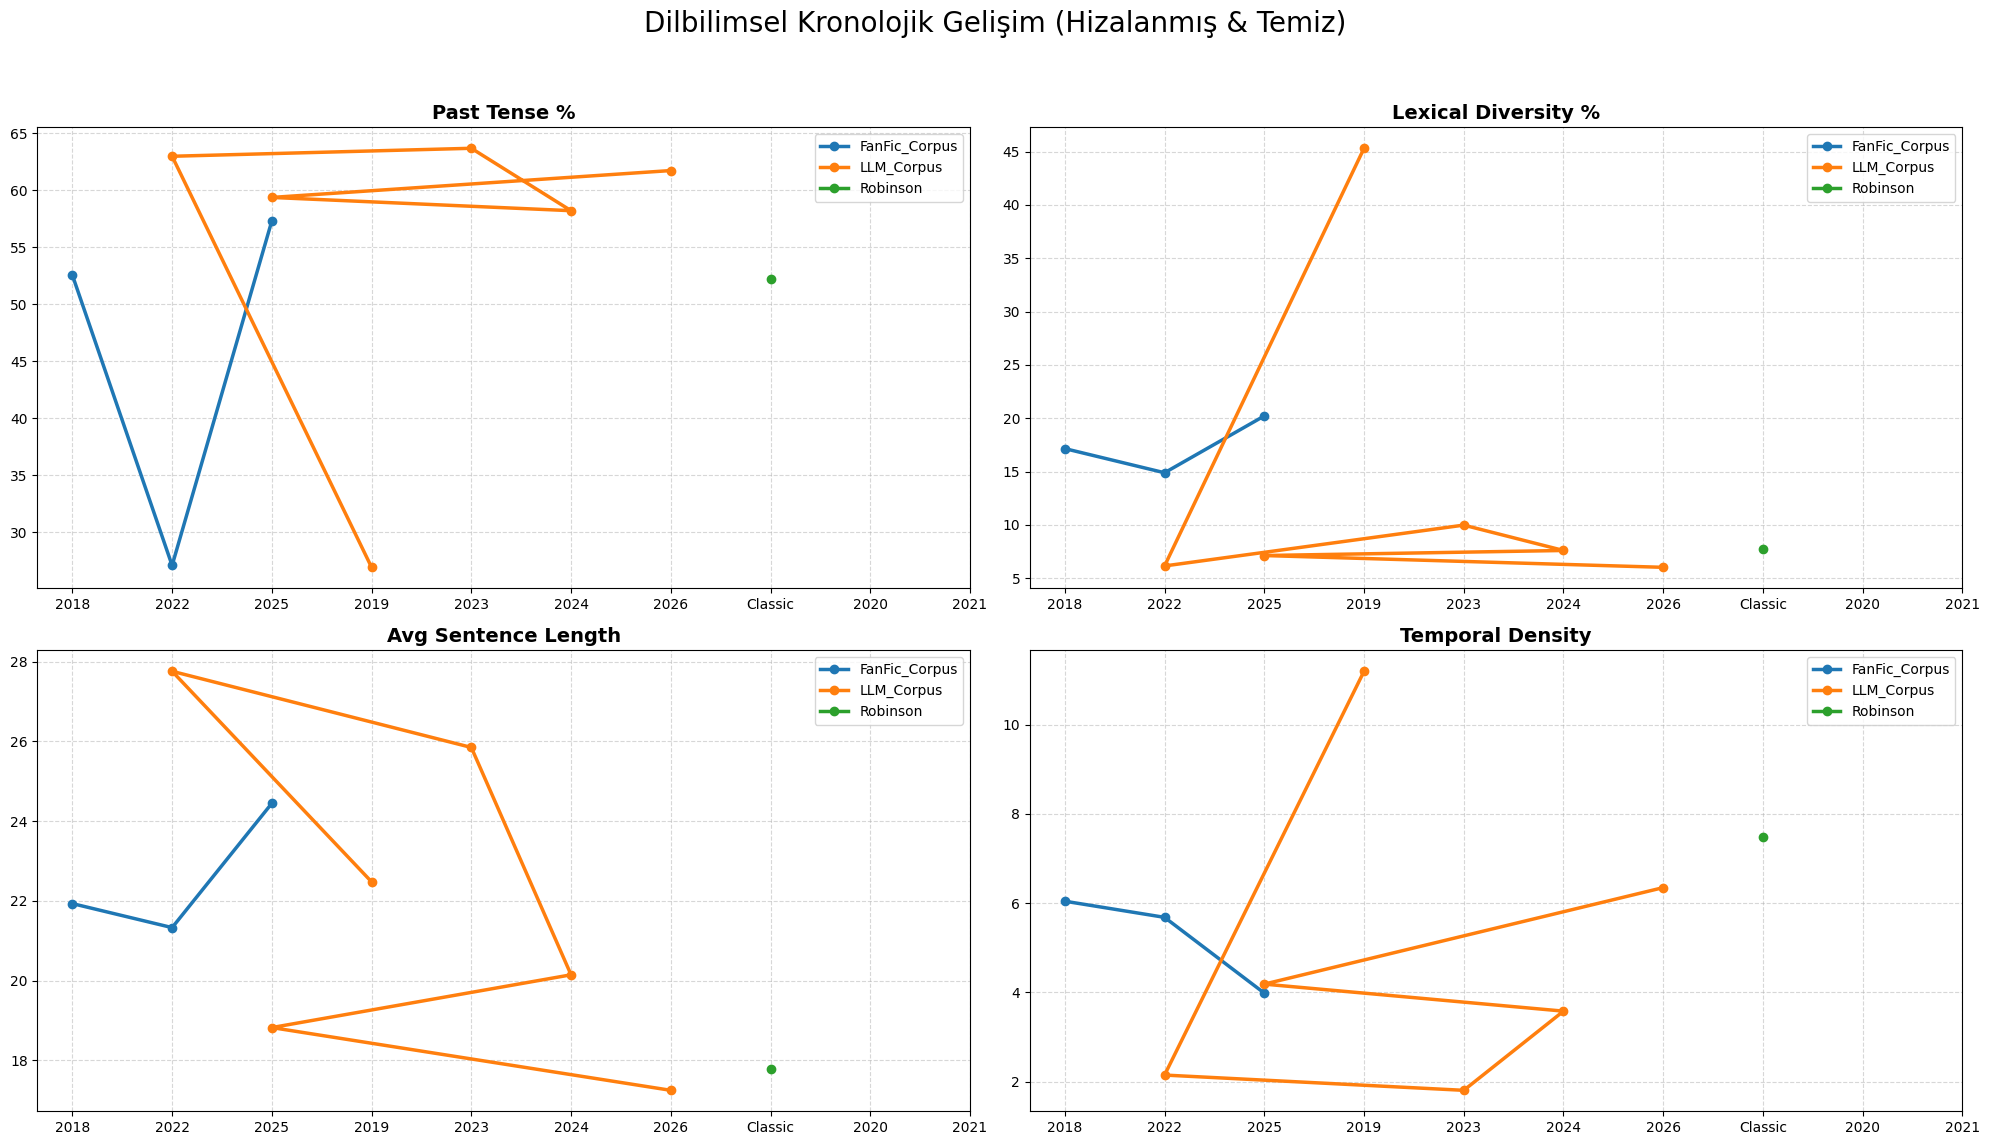

In [ ]:
import os
import re
import spacy
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Drive ve NLP
if not os.path.exists('/content/drive'): drive.mount('/content/drive')
try:
    nlp = spacy.load("en_core_web_md", disable=["ner", "lemmatizer"])
except:
    !python -m spacy download en_core_web_md
    nlp = spacy.load("en_core_web_md", disable=["ner", "lemmatizer"])

# Parametreler
BASE_PATH = '/content/drive/MyDrive/Text_files'
CORPUS_FOLDERS = ['FanFic_Corpus', 'LLM_Corpus', 'Robinson']
my_temp_keywords = ["first", "then", "after", "finally", "suddenly", "meanwhile", "later", "before", "next"]

def get_year_label(path_str, corpus):
    if "Robinson" in corpus: return "Classic"
    match = re.search(r"(201[8-9]|202[0-7])", path_str)
    return match.group(1) if match else None

def analyze_final():
    data = {c: {} for c in CORPUS_FOLDERS}
    for corpus in CORPUS_FOLDERS:
        root_path = os.path.join(BASE_PATH, corpus)
        if not os.path.exists(root_path): continue
        print(f"📂 {corpus} analiz ediliyor...")
        for root, _, files in os.walk(root_path):
            y_label = get_year_label(root, corpus)
            for file in files:
                if file.endswith(".txt"):
                    final_y = y_label if y_label else get_year_label(file, corpus)
                    if not final_y: continue
                    try:
                        with open(os.path.join(root, file), 'r', encoding='utf-8', errors='ignore') as f:
                            doc = nlp(f.read()[:200000])
                            words = [t.text.lower() for t in doc if not t.is_punct and not t.is_space]
                            if not words: continue
                            if final_y not in data[corpus]:
                                data[corpus][final_y] = {"past":0, "verbs":0, "words":0, "u":set(), "s_len":[], "tmp":0}
                            d = data[corpus][final_y]
                            d["past"] += sum(1 for t in doc if t.pos_ in ["VERB", "AUX"] and (t.tag_ in ["VBD", "VBN"] or t.text.lower() in ["was","were","had"]))
                            d["verbs"] += sum(1 for t in doc if t.pos_ in ["VERB", "AUX"])
                            d["words"] += len(words)
                            d["u"].update(words)
                            d["s_len"].extend([len(sent) for sent in doc.sents])
                            d["tmp"] += sum(1 for w in words if w in my_temp_keywords)
                    except: continue
    return data

res = analyze_final()

# --- GRAFİK: MANUEL SIRALAMA VE HİZALAMA ---
# Önce tüm yılları toplayıp BENİM İSTEDİĞİM sırada diziyoruz
full_timeline = ["Classic", "2018", "2019", "2020", "2021", "2022", "2023", "2024", "2025", "2026"]

if res:
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    metrics = [
        ("Past Tense %", lambda d: (d['past']/d['verbs']*100) if d['verbs']>0 else 0),
        ("Lexical Diversity %", lambda d: (len(d['u'])/d['words']*100) if d['words']>0 else 0),
        ("Avg Sentence Length", lambda d: np.mean(d['s_len']) if d['s_len'] else 0),
        ("Temporal Density", lambda d: (d['tmp']/d['words']*1000) if d['words']>0 else 0)
    ]

    for i, (title, func) in enumerate(metrics):
        ax = axes[i//2, i%2]
        for corpus in CORPUS_FOLDERS:
            # Çizgi çekerken sadece timeline listesindeki sırayla veriyi alıyoruz
            x_plot, y_plot = [], []
            for year in full_timeline:
                if year in res[corpus]:
                    x_plot.append(year)
                    y_plot.append(func(res[corpus][year]))

            if x_plot:
                # Çizgileri timeline sırasına göre plot ediyoruz
                ax.plot(x_plot, y_plot, marker='o', label=corpus, linewidth=2.5)

        ax.set_title(title, fontweight='bold', fontsize=14)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend()
        # X eksenindeki tüm yılların yerini sabitle
        ax.set_xticks(full_timeline)

    plt.suptitle("Dilbilimsel Kronolojik Gelişim (Hizalanmış & Temiz)", fontsize=20, y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

📂 FanFic_Corpus analiz ediliyor...
📂 LLM_Corpus analiz ediliyor...
📂 Robinson analiz ediliyor...


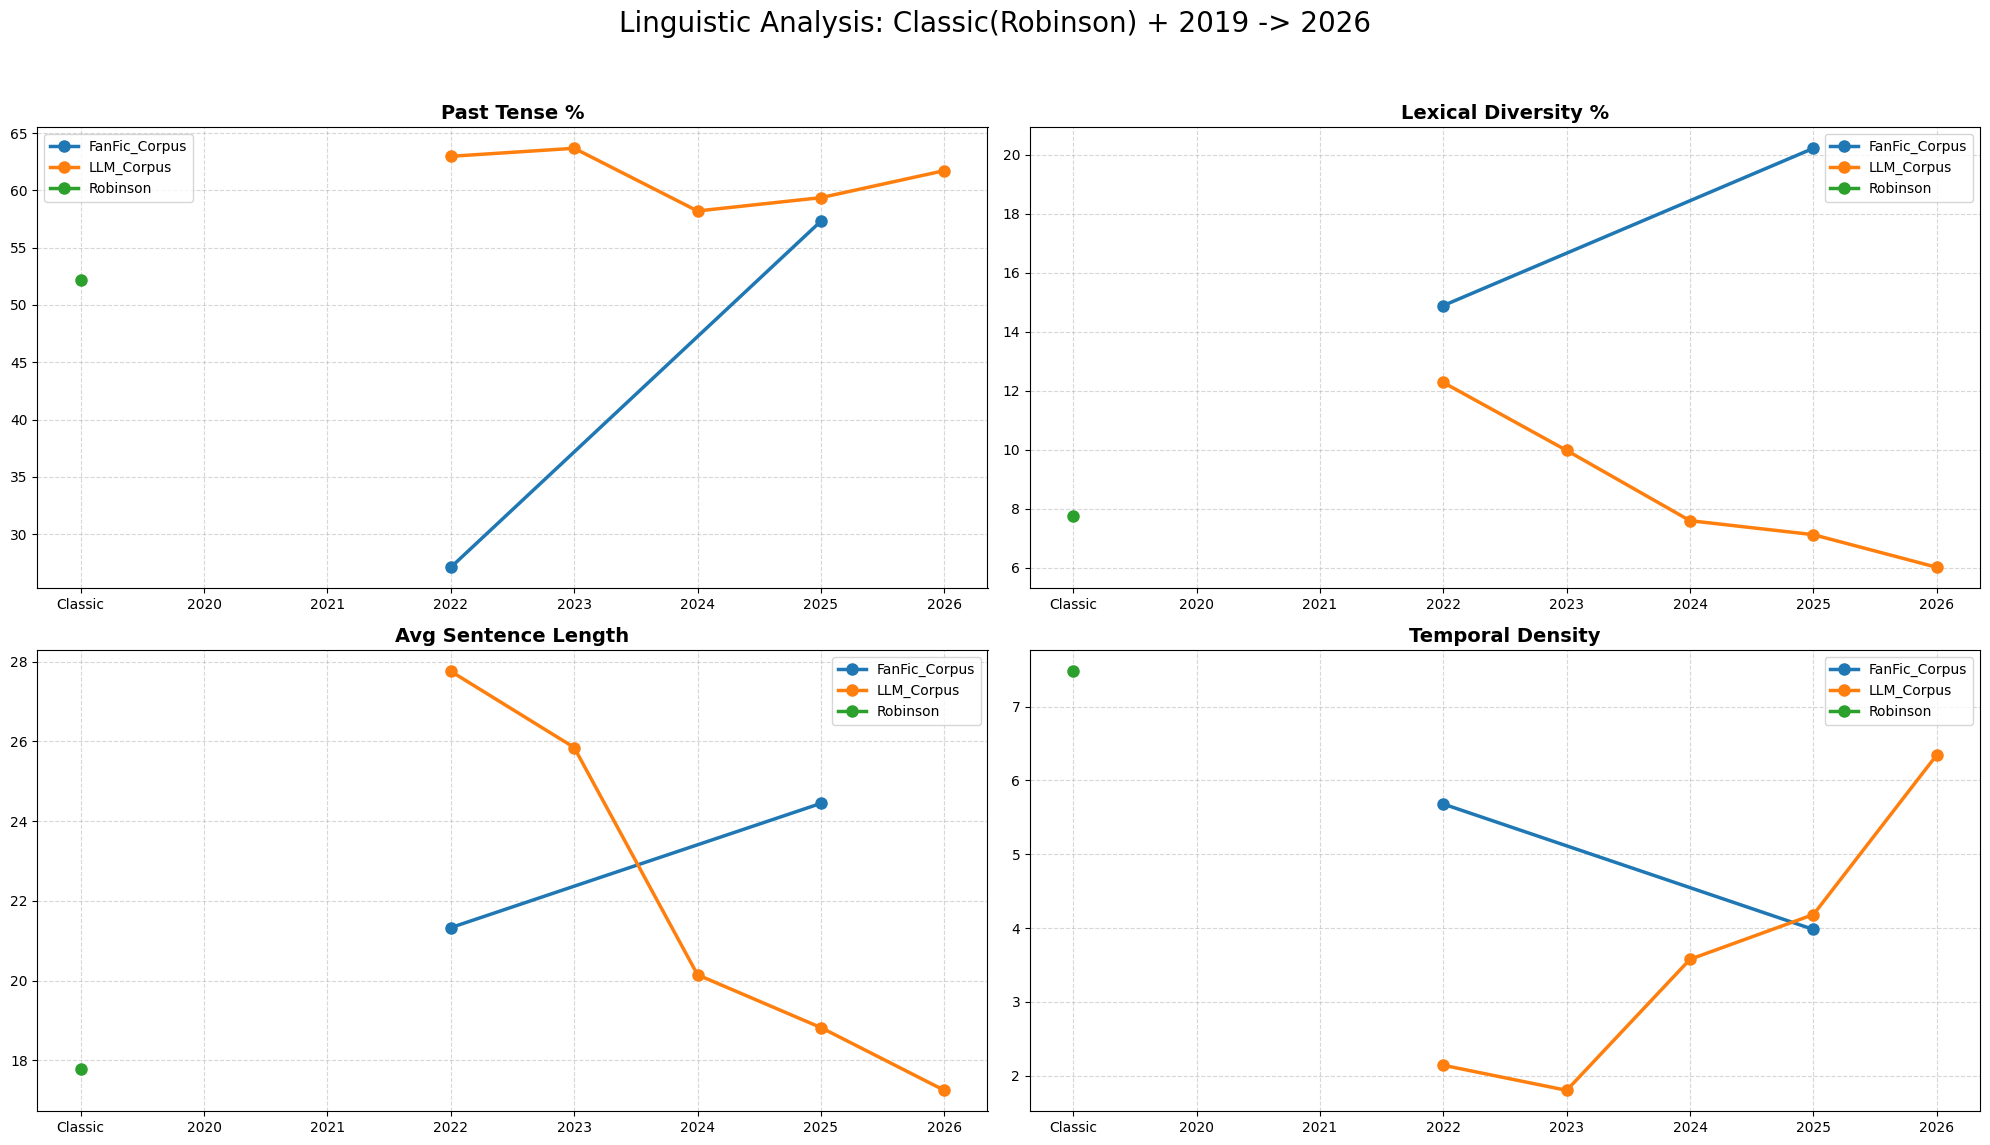

In [ ]:
import os
import re
import spacy
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Hazırlık
if not os.path.exists('/content/drive'): drive.mount('/content/drive')
try:
    nlp = spacy.load("en_core_web_md", disable=["ner", "lemmatizer"])
except:
    !python -m spacy download en_core_web_md
    nlp = spacy.load("en_core_web_md", disable=["ner", "lemmatizer"])

BASE_PATH = '/content/drive/MyDrive/Text_files'
CORPUS_FOLDERS = ['FanFic_Corpus', 'LLM_Corpus', 'Robinson']
my_temp_keywords = ["first", "then", "after", "finally", "suddenly", "meanwhile", "later", "before", "next"]

# --- SIRALAMA SÖZLÜĞÜ (Mapping) ---
# Bu sözlük hem sırayı hem de aradaki boşluğun kapanmasını sağlar
timeline_map = {
    "Classic": 0, "2020": 1, "2021": 2,
    "2022": 3, "2023": 4, "2024": 5, "2025": 6, "2026": 7
}
# Ters sözlük (Grafik etiketleri için)
inv_map = {v: k for k, v in timeline_map.items()}

def get_year_label(path_str, corpus):
    if "Robinson" in corpus: return "Classic"
    match = re.search(r"(201[8-9]|202[0-7])", path_str)
    return match.group(1) if match else None

def analyze_final_v3():
    data = {c: {} for c in CORPUS_FOLDERS}
    for corpus in CORPUS_FOLDERS:
        root_path = os.path.join(BASE_PATH, corpus)
        if not os.path.exists(root_path): continue
        print(f"📂 {corpus} analiz ediliyor...")
        for root, _, files in os.walk(root_path):
            y_label = get_year_label(root, corpus)
            for file in files:
                if file.endswith(".txt"):
                    final_y = y_label if y_label else get_year_label(file, corpus)
                    if final_y not in timeline_map: continue

                    try:
                        with open(os.path.join(root, file), 'r', encoding='utf-8', errors='ignore') as f:
                            doc = nlp(f.read()[:200000])
                            words = [t.text.lower() for t in doc if not t.is_punct and not t.is_space]
                            if not words: continue

                            if final_y not in data[corpus]:
                                data[corpus][final_y] = {"past":0, "verbs":0, "words":0, "u":set(), "s_len":[], "tmp":0}

                            d = data[corpus][final_y]
                            d["past"] += sum(1 for t in doc if t.pos_ in ["VERB", "AUX"] and (t.tag_ in ["VBD", "VBN"] or t.text.lower() in ["was","were","had"]))
                            d["verbs"] += sum(1 for t in doc if t.pos_ in ["VERB", "AUX"])
                            d["words"] += len(words)
                            d["u"].update(words)
                            d["s_len"].extend([len(sent) for sent in doc.sents])
                            d["tmp"] += sum(1 for w in words if w in my_temp_keywords)
                    except: continue
    return data

results = analyze_final_v3()

# --- GRAFİK ÇİZİMİ ---
if results:
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    metrics = [
        ("Past Tense %", lambda d: (d['past']/d['verbs']*100) if d['verbs']>0 else 0),
        ("Lexical Diversity %", lambda d: (len(d['u'])/d['words']*100) if d['words']>0 else 0),
        ("Avg Sentence Length", lambda d: np.mean(d['s_len']) if d['s_len'] else 0),
        ("Temporal Density", lambda d: (d['tmp']/d['words']*1000) if d['words']>0 else 0)
    ]

    for i, (title, func) in enumerate(metrics):
        ax = axes[i//2, i%2]
        for corpus in CORPUS_FOLDERS:
            # Mevcut yılları bul ve sayısal değerlerine (0-9) göre sırala
            years_in_corpus = [y for y in results[corpus].keys() if y in timeline_map]
            sorted_years = sorted(years_in_corpus, key=lambda x: timeline_map[x])

            if not sorted_years: continue

            # X değerleri olarak 0, 1, 2... gibi indeksleri veriyoruz
            x_indices = [timeline_map[y] for y in sorted_years]
            y_values = [func(results[corpus][y]) for y in sorted_years]

            ax.plot(x_indices, y_values, marker='o', label=corpus, linewidth=2.5, markersize=8)

        ax.set_title(title, fontweight='bold', fontsize=14)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend()

        # X eksenindeki rakamları (0,1,2...) tekrar metne (Classic, 2018...) çeviriyoruz
        ax.set_xticks(list(inv_map.keys()))
        ax.set_xticklabels(list(inv_map.values()), rotation=0)

    plt.suptitle("Linguistic Analysis: Classic(Robinson) + 2019 -> 2026", fontsize=20, y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

📂 FanFic_Corpus tüm zamanlar için analiz ediliyor...
📂 LLM_Corpus tüm zamanlar için analiz ediliyor...
📂 Robinson tüm zamanlar için analiz ediliyor...


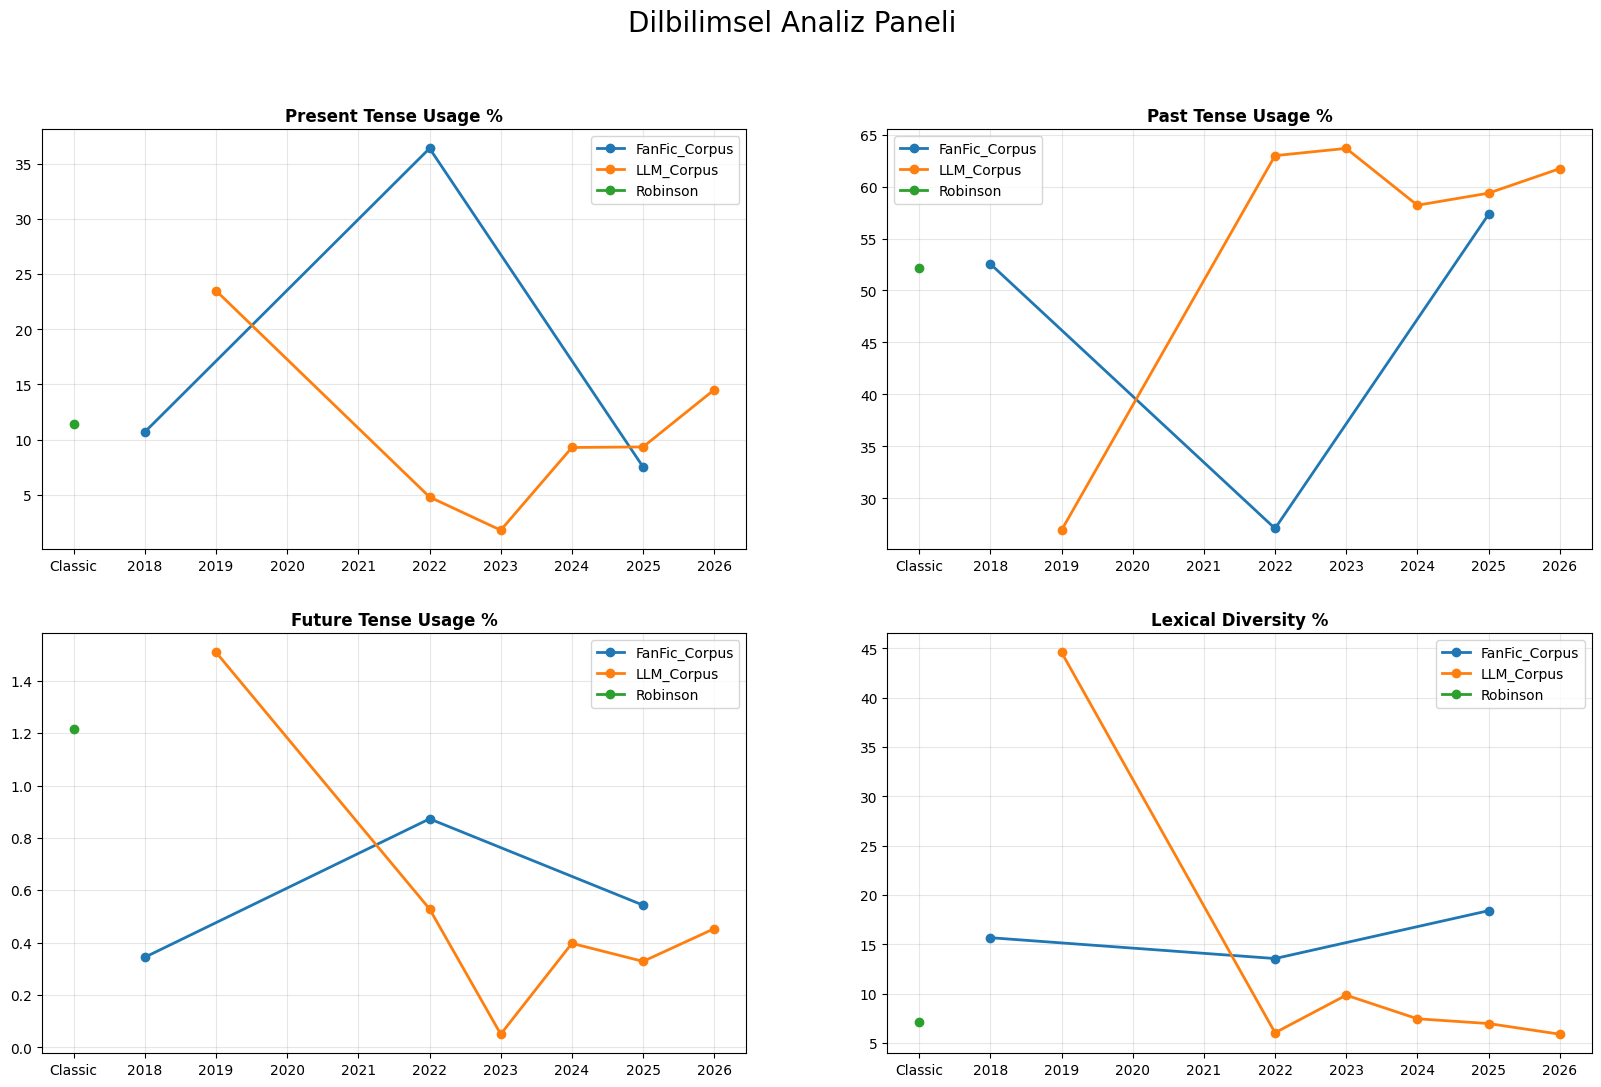


--- Zaman Karşılaştırması Grafikleri Çiziliyor ---


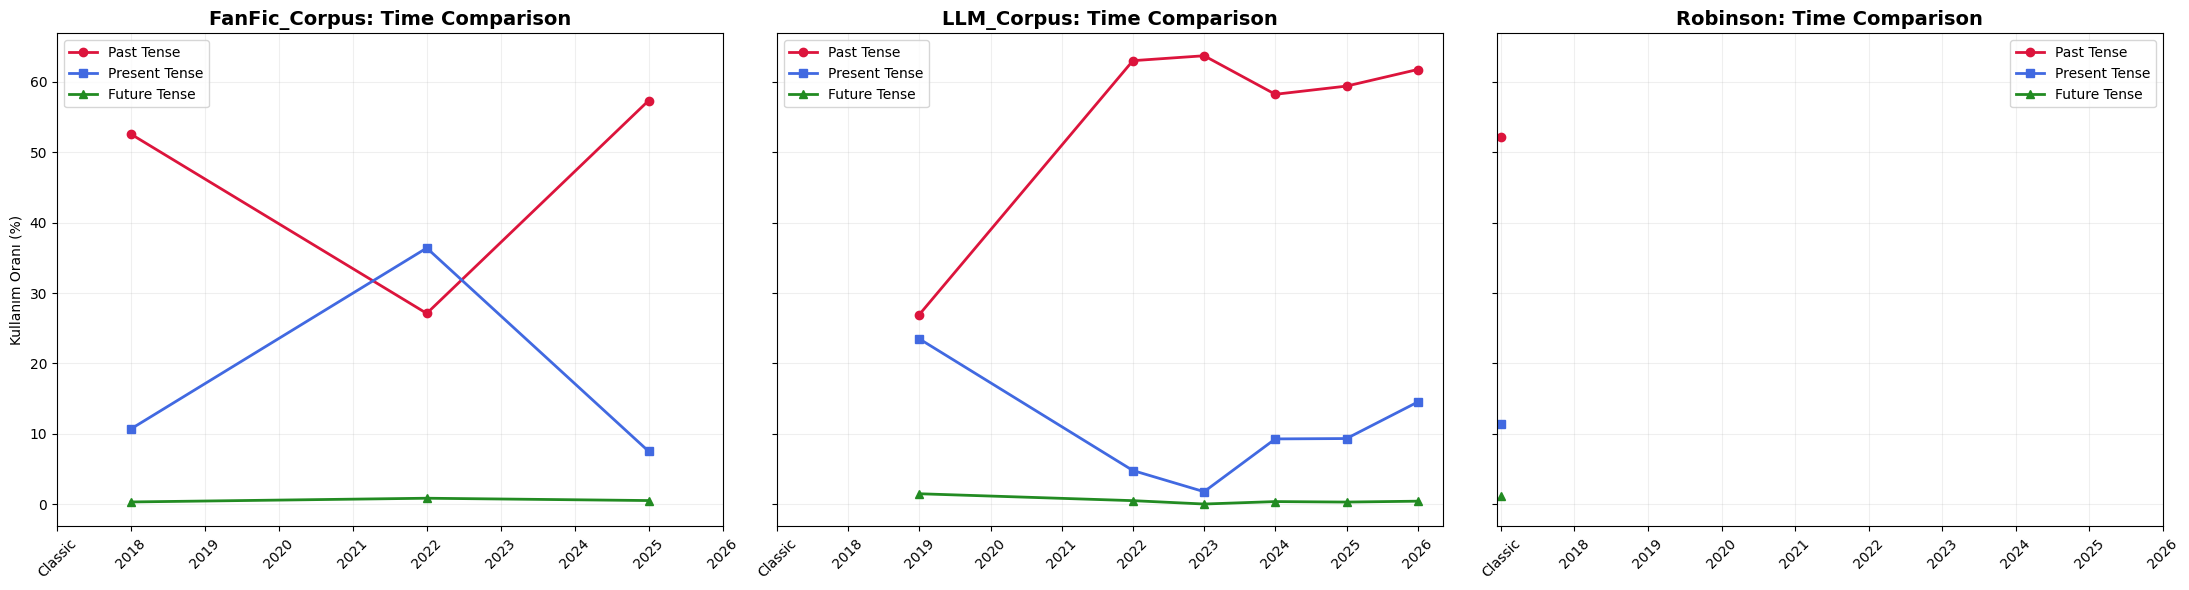

In [ ]:
import os
import re
import spacy
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Drive ve NLP
if not os.path.exists('/content/drive'): drive.mount('/content/drive')
try:
    nlp = spacy.load("en_core_web_md", disable=["ner", "lemmatizer"])
except:
    !python -m spacy download en_core_web_md
    nlp = spacy.load("en_core_web_md", disable=["ner", "lemmatizer"])

# Parametreler (Sıralamayı bozmamak için çiviledik)
BASE_PATH = '/content/drive/MyDrive/Text_files'
CORPUS_FOLDERS = ['FanFic_Corpus', 'LLM_Corpus', 'Robinson']
my_temp_keywords = ["first", "then", "after", "finally", "suddenly", "meanwhile", "later", "before", "next"]

timeline_map = {
    "Classic": 0, "2018": 1, "2019": 2, "2020": 3, "2021": 4,
    "2022": 5, "2023": 6, "2024": 7, "2025": 8, "2026": 9
}
inv_map = {v: k for k, v in timeline_map.items()}

def get_year_label(path_str, corpus):
    if "Robinson" in corpus: return "Classic"
    match = re.search(r"(201[8-9]|202[0-7])", path_str)
    return match.group(1) if match else None

def full_linguistic_analysis():
    data = {c: {} for c in CORPUS_FOLDERS}
    for corpus in CORPUS_FOLDERS:
        root_path = os.path.join(BASE_PATH, corpus)
        if not os.path.exists(root_path): continue
        print(f"📂 {corpus} tüm zamanlar için analiz ediliyor...")

        for root, _, files in os.walk(root_path):
            y_label = get_year_label(root, corpus)
            for file in files:
                if file.endswith(".txt"):
                    final_y = y_label if y_label else get_year_label(file, corpus)
                    if final_y not in timeline_map: continue

                    try:
                        with open(os.path.join(root, file), 'r', encoding='utf-8', errors='ignore') as f:
                            doc = nlp(f.read()[:200000])

                            p_count = 0 # Past
                            pr_count = 0 # Present
                            f_count = 0 # Future
                            v_count = 0 # Total Verbs

                            for t in doc:
                                if t.pos_ in ["VERB", "AUX"]:
                                    v_count += 1
                                    # Past
                                    if t.tag_ in ["VBD", "VBN"] or t.text.lower() in ["was","were","had"]:
                                        p_count += 1
                                    # Present (VBP: base, VBZ: 3rd person singular)
                                    elif t.tag_ in ["VBP", "VBZ"] or t.text.lower() in ["am","is","are","has"]:
                                        pr_count += 1
                                    # Future
                                    if t.text.lower() in ["will", "shall", "'ll"]:
                                        f_count += 1
                                    if t.lemma_ == "go" and t.dep_ == "aux": # going to
                                        f_count += 1

                            if final_y not in data[corpus]:
                                data[corpus][final_y] = {"past":0, "present":0, "future":0, "verbs":0, "words":0, "u":set()}

                            d = data[corpus][final_y]
                            d["past"] += p_count
                            d["present"] += pr_count
                            d["future"] += f_count
                            d["verbs"] += v_count
                            d["words"] += len([tk for tk in doc if not tk.is_punct])
                            d["u"].update([tk.text.lower() for tk in doc if not tk.is_punct])
                    except: continue
    return data

results = full_linguistic_analysis()

# --- GRAFİK 1: AYRI METRİKLER (4'LÜ PANEL) ---
if results:
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    metrics = [
        ("Present Tense Usage %", lambda d: (d['present']/d['verbs']*100) if d['verbs']>0 else 0),
        ("Past Tense Usage %", lambda d: (d['past']/d['verbs']*100) if d['verbs']>0 else 0),
        ("Future Tense Usage %", lambda d: (d['future']/d['verbs']*100) if d['verbs']>0 else 0),
        ("Lexical Diversity %", lambda d: (len(d['u'])/d['words']*100) if d['words']>0 else 0)
    ]

    for i, (title, func) in enumerate(metrics):
        ax = axes[i//2, i%2]
        for corpus in CORPUS_FOLDERS:
            sorted_years = sorted([y for y in results[corpus].keys()], key=lambda x: timeline_map[x])
            if not sorted_years: continue

            ax.plot([timeline_map[y] for y in sorted_years], [func(results[corpus][y]) for y in sorted_years],
                    marker='o', label=corpus, linewidth=2)

        ax.set_title(title, fontweight='bold')
        ax.set_xticks(list(inv_map.keys()))
        ax.set_xticklabels(list(inv_map.values()))
        ax.grid(True, alpha=0.3); ax.legend()

    plt.suptitle("Dilbilimsel Analiz Paneli", fontsize=20, y=0.98)
    plt.show()

    # --- GRAFİK 2: ZAMAN KARŞILAŞTIRMASI (ÜÇÜ BİR ARADA) ---
    print("\n--- Zaman Karşılaştırması Grafikleri Çiziliyor ---")
    fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=True)

    for idx, corpus in enumerate(CORPUS_FOLDERS):
        ax = axes[idx]
        sorted_years = sorted([y for y in results[corpus].keys()], key=lambda x: timeline_map[x])
        if not sorted_years: continue

        x_vals = [timeline_map[y] for y in sorted_years]
        p_vals = [(results[corpus][y]['past']/results[corpus][y]['verbs']*100) for y in sorted_years]
        pr_vals = [(results[corpus][y]['present']/results[corpus][y]['verbs']*100) for y in sorted_years]
        f_vals = [(results[corpus][y]['future']/results[corpus][y]['verbs']*100) for y in sorted_years]

        ax.plot(x_vals, p_vals, marker='o', label='Past Tense', color='crimson', linewidth=2)
        ax.plot(x_vals, pr_vals, marker='s', label='Present Tense', color='royalblue', linewidth=2)
        ax.plot(x_vals, f_vals, marker='^', label='Future Tense', color='forestgreen', linewidth=2)

        ax.set_title(f"{corpus}: Time Comparison", fontsize=14, fontweight='bold')
        ax.set_xticks(list(inv_map.keys()))
        ax.set_xticklabels(list(inv_map.values()), rotation=45)
        ax.grid(True, alpha=0.2)
        if idx == 0: ax.set_ylabel("Kullanım Oranı (%)")
        ax.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
import os
import re
import spacy
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.cluster import KMeans
from google.colab import drive

# 1. Drive Bağlantısı
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- YOL AYARLARI ---
BASE_PATH = '/content/drive/MyDrive/Text_files'
FANFIC_PATH = os.path.join(BASE_PATH, 'FanFic_Corpus') # Fanfic'lerin olduğu klasör
OUTPUT_FOLDER = os.path.join(BASE_PATH, 'ANALYSIS_RESULTS')
COMBINED_FILE = os.path.join(BASE_PATH, 'fanfiction_all_texts.txt')
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# --- ADIM 1: DOSYALARI BİRLEŞTİRME ---
def combine_fanfics():
    print("Metinler birleştiriliyor...")
    combined_content = []

    # Sadece FanFic_Corpus içindeki txt dosyalarını topla
    for root, dirs, files in os.walk(FANFIC_PATH):
        for file in files:
            if file.endswith(".txt"):
                with open(os.path.join(root, file), 'r', encoding='utf-8', errors='ignore') as f:
                    combined_content.append(f"--- FILE: {file} ---\n") # Dosya ayracı
                    combined_content.append(f.read())
                    combined_content.append("\n\n")

    with open(COMBINED_FILE, 'w', encoding='utf-8') as f_out:
        f_out.write("".join(combined_content))
    print(f"✅ Tüm metinler birleştirildi: {COMBINED_FILE}")

combine_fanfics()

# --- ADIM 2: ANALİZ ---
# NLP Modelini Yükle
try:
    nlp = spacy.load("en_core_web_md")
except:
    !python -m spacy download en_core_web_md
    nlp = spacy.load("en_core_web_md")

# Kelime listelerin (Aynen korundu)
first_keywords = ["at first", "at that moment", "at the beginning", "at the onset", "before", "commence", "choose", "first", "first of all", "from this point", "in the first place", "one day", "one evening", "one morning", "starting with", "to begin"]
next_keywords = ["a moment later", "after", "after a few days", "after a while", "after that", "afterwards", "all of a sudden", "as soon as", "at that very moment", "at times", "before long", "consequently", "during", "earlier", "eventually", "following", "formerly", "from time to time", "gradually", "henceforth", "in addition", "in the meantime", "in the past", "in time", "in turn", "later", "later on", "meanwhile", "momentarily", "next", "next week", "not a moment too soon", "not long after", "not long ago", "now", "occasionally", "once", "past", "periodically", "preceding", "presently", "previously", "prior to", "rarely", "right after", "second", "seldom", "shortly", "shortly after this", "since", "some of the time", "soon", "soon after", "suddenly", "then", "therefore", "third", "tomorrow", "up until that time", "when", "whenever", "yesterday"]
last_keywords = ["after a long time", "afterward", "at last", "at the end", "finally", "hereafter", "in conclusion", "in the end", "last of all", "lastly", "thereafter", "to conclude", "to finish", "ultimately", "until", "one day"]
temporal_keywords = list(set(first_keywords + next_keywords + last_keywords))
categories = {"First": first_keywords, "Next": next_keywords, "Last": last_keywords}

def get_ultimate_verb(token):
    curr = token
    for _ in range(10):
        if curr.head == curr: break
        if curr.head.pos_ == "VERB": return curr.head
        curr = curr.head
    return None

def run_combined_analysis():
    # Sadece birleştirilmiş dosyayı hedef alıyoruz
    file_path = COMBINED_FILE
    fname = "fanfiction_all_texts"

    print(f"🚀 Birleştirilmiş dosya analiz ediliyor: {fname}...")

    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            text_raw = f.read()

        # Metin çok uzunsa SpaCy sınırı aşabilir, sınırı gerekirse yükseltiyoruz
        nlp.max_length = max(1000000, len(text_raw) + 100)
        doc = nlp(text_raw)
        clean_text = text_raw.lower()

        # --- Analiz Bölümleri (Senin kodunla aynı) ---
        # 1. Frekans
        kw_counts = {w: len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in temporal_keywords}
        kw_counts = {k: v for k, v in kw_counts.items() if v > 0}
        sorted_kw = dict(sorted(kw_counts.items(), key=lambda x: x[1], reverse=True)[:15])

        # 2. Kategori
        cat_counts = {cat: sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in set(kws)) for cat, kws in categories.items()}

        # 3. Dispersion
        word_positions = []
        top_words_for_disp = list(sorted_kw.keys())[:12]
        for w in top_words_for_disp:
            for m in re.finditer(rf'\b{re.escape(w)}\b', clean_text):
                word_positions.append({'Word': w, 'Pos': m.start()})

        # 4. Tense
        t_counts = {"Past": 0, "Pres(S)": 0, "Pres(C)": 0, "Future": 0}
        f_idx = set()
        for t in doc:
            if t.tag_ == "MD" and t.lemma_.lower() in ["will", "shall"]:
                f_idx.add(t.i); t_counts["Future"] += 1
            if t.text.lower() == "going" and t.tag_ == "VBG":
                for j in range(t.i + 1, min(t.i + 3, len(doc))):
                    if doc[j].text.lower() == "to": f_idx.update([t.i, j]); t_counts["Future"] += 1; break
        for t in doc:
            if t.i in f_idx or t.pos_ not in ["VERB", "AUX"]: continue
            if t.tag_ in ["VBD", "VBN"] or t.text.lower() in ["was", "were", "had"]: t_counts["Past"] += 1
            elif t.tag_ == "VBG": t_counts["Pres(C)"] += 1
            elif t.tag_ in ["VBP", "VBZ", "VB"]: t_counts["Pres(S)"] += 1

        # 5. Network & 6. Density Flow (Çizim kodları buraya gelecek...)
        # ... (Grafik çizim kısmı senin kodundakiyle aynı şekilde devam eder) ...

        # Grafik çizim kodunu buraya ekleyip plt.show() veya plt.savefig() diyebilirsin.
        print("✅ Analiz tamamlandı, Dashboard hazır.")

    except Exception as e:
        print(f"Hata oluştu: {e}")

# Fonksiyonu çalıştır
run_combined_analysis()

Metinler birleştiriliyor...
✅ Tüm metinler birleştirildi: /content/drive/MyDrive/Text_files/fanfiction_all_texts.txt
🚀 Birleştirilmiş dosya analiz ediliyor: fanfiction_all_texts...
✅ Analiz tamamlandı, Dashboard hazır.


🚀 Dashboard hazırlanıyor: fanfiction_all_texts...


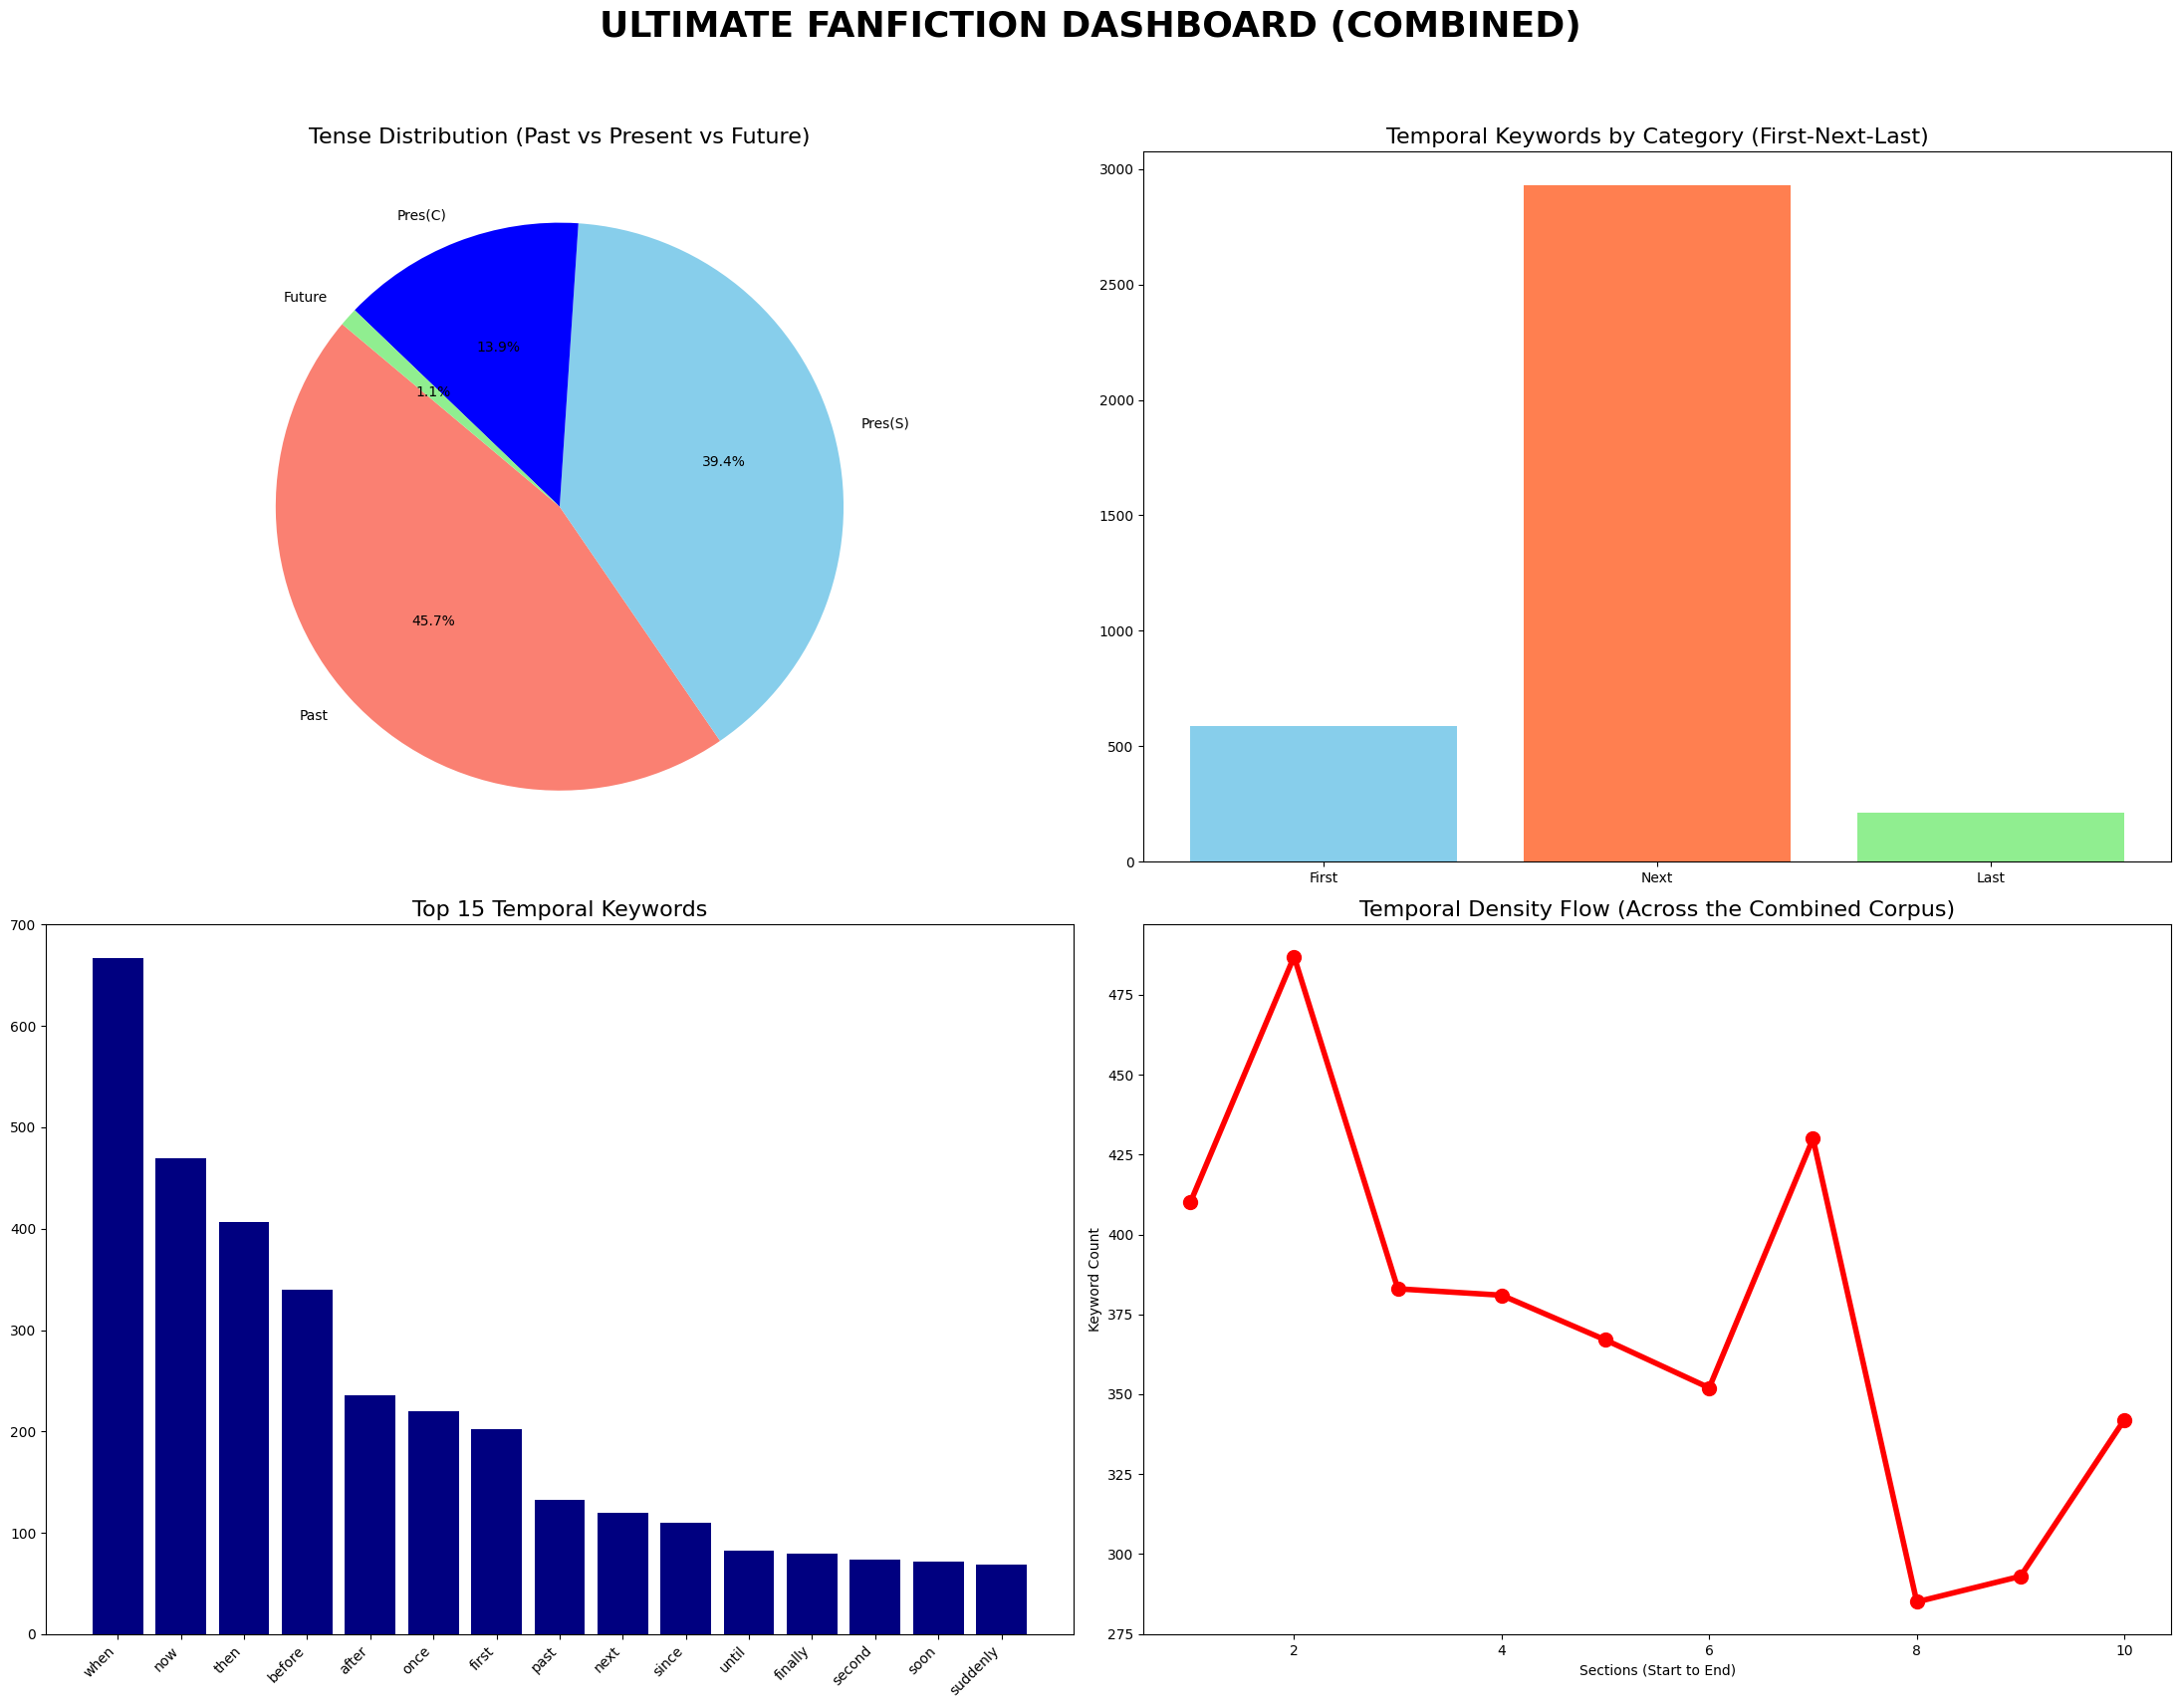

✅ Dashboard ekrana basıldı ve kaydedildi: /content/drive/MyDrive/Text_files/ANALYSIS_RESULTS/COMBINED_DASHBOARD.png


In [ ]:
# --- DASHBOARD'U EKRANA BASAN FİNAL KOD ---

def run_combined_analysis_with_visuals():
    file_path = COMBINED_FILE
    fname = "fanfiction_all_texts"
    print(f"🚀 Dashboard hazırlanıyor: {fname}...")

    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            text_raw = f.read()

        nlp.max_length = max(1000000, len(text_raw) + 100)
        doc = nlp(text_raw)
        clean_text = text_raw.lower()

        # 1. Tense Hesaplama
        t_counts = {"Past": 0, "Pres(S)": 0, "Pres(C)": 0, "Future": 0}
        f_idx = set()
        for t in doc:
            if t.tag_ == "MD" and t.lemma_.lower() in ["will", "shall"]:
                f_idx.add(t.i); t_counts["Future"] += 1
            if t.text.lower() == "going" and t.tag_ == "VBG":
                for j in range(t.i + 1, min(t.i + 3, len(doc))):
                    if doc[j].text.lower() == "to": f_idx.update([t.i, j]); t_counts["Future"] += 1; break
        for t in doc:
            if t.i in f_idx or t.pos_ not in ["VERB", "AUX"]: continue
            if t.tag_ in ["VBD", "VBN"] or t.text.lower() in ["was", "were", "had"]: t_counts["Past"] += 1
            elif t.tag_ == "VBG": t_counts["Pres(C)"] += 1
            elif t.tag_ in ["VBP", "VBZ", "VB"]: t_counts["Pres(S)"] += 1

        # 2. Kategori ve Kelime Frekansı
        kw_counts = {w: len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in temporal_keywords}
        sorted_kw = dict(sorted({k: v for k, v in kw_counts.items() if v > 0}.items(), key=lambda x: x[1], reverse=True)[:15])
        cat_counts = {cat: sum(len(re.findall(rf'\b{re.escape(w)}\b', clean_text)) for w in set(kws)) for cat, kws in categories.items()}

        # --- GÖRSELLEŞTİRME (DASHBOARD ÇİZİMİ) ---
        fig = plt.figure(figsize=(22, 18))
        fig.suptitle(f"ULTIMATE FANFICTION DASHBOARD (COMBINED)", fontsize=26, fontweight='bold', y=0.98)

        # A. Tense Dağılımı (Pasta Grafiği - Daha şık durur)
        ax1 = plt.subplot(2, 2, 1)
        ax1.pie(t_counts.values(), labels=t_counts.keys(), autopct='%1.1f%%', colors=['salmon', 'skyblue', 'blue', 'lightgreen'], startangle=140)
        ax1.set_title("Tense Distribution (Past vs Present vs Future)", fontsize=16)

        # B. Temporal Kategori Bar
        ax2 = plt.subplot(2, 2, 2)
        ax2.bar(cat_counts.keys(), cat_counts.values(), color=['skyblue', 'coral', 'lightgreen'])
        ax2.set_title("Temporal Keywords by Category (First-Next-Last)", fontsize=16)

        # C. En Çok Geçen 15 Zaman Kelimesi
        ax3 = plt.subplot(2, 2, 3)
        ax3.bar(sorted_kw.keys(), sorted_kw.values(), color='navy')
        ax3.set_title("Top 15 Temporal Keywords", fontsize=16)
        plt.setp(ax3.get_xticklabels(), rotation=45, ha='right')

        # D. Yoğunluk Akışı (Zaman içinde kelime kullanımı nasıl değişiyor?)
        ax4 = plt.subplot(2, 2, 4)
        chunks = 10
        words_only = [t.text.lower() for t in doc if not t.is_punct and not t.is_space]
        sz = max(1, len(words_only)//chunks)
        flow = [sum(len(re.findall(rf'\b{re.escape(w)}\b', " ".join(words_only[i*sz:(i+1)*sz]))) for w in temporal_keywords) for i in range(chunks)]
        ax4.plot(range(1, chunks+1), flow, marker='o', color='red', linewidth=4, markersize=10)
        ax4.set_title("Temporal Density Flow (Across the Combined Corpus)", fontsize=16)
        ax4.set_xlabel("Sections (Start to End)")
        ax4.set_ylabel("Keyword Count")

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])

        # Hem göster hem kaydet
        save_path = os.path.join(OUTPUT_FOLDER, "COMBINED_DASHBOARD.png")
        plt.savefig(save_path)
        plt.show() # İşte Dashboard'u burası getiriyor!

        print(f"✅ Dashboard ekrana basıldı ve kaydedildi: {save_path}")

    except Exception as e:
        print(f"Hata: {e}")

# Çalıştır
run_combined_analysis_with_visuals()

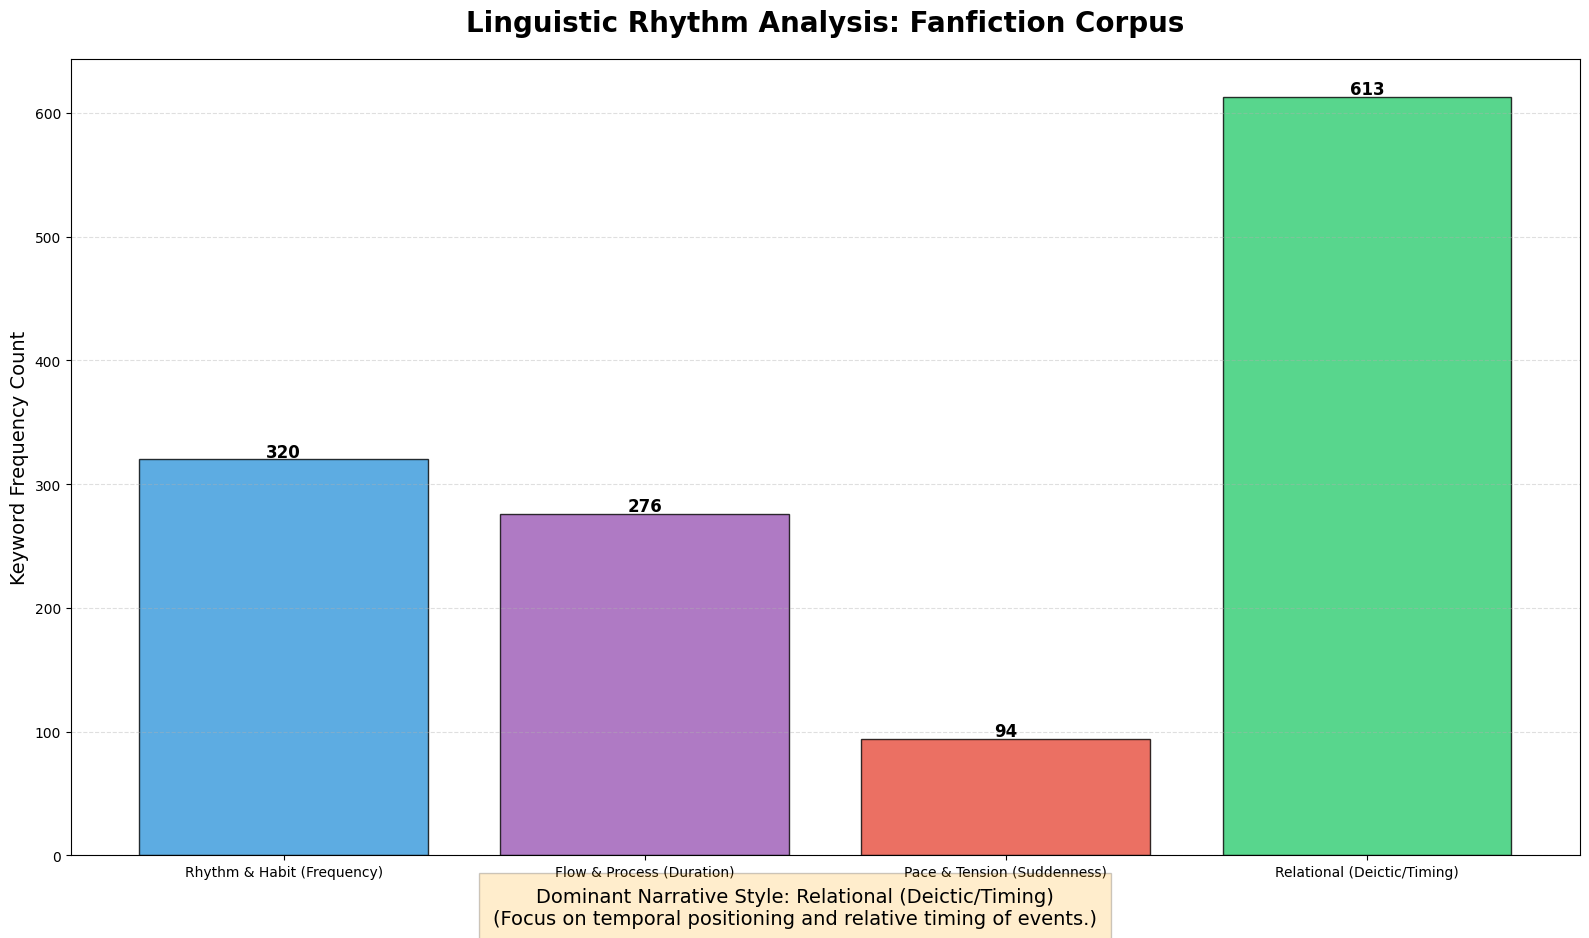

In [ ]:
import os
import re
import spacy
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Hazırlık
if not os.path.exists('/content/drive'): drive.mount('/content/drive')
try:
    nlp = spacy.load("en_core_web_md", disable=["ner", "parser"])
except:
    !python -m spacy download en_core_web_md
    nlp = spacy.load("en_core_web_md", disable=["ner", "parser"])

# --- YENİ LİNGUISTIC KÜMELEME SÖZLÜĞÜ ---
advanced_categories = {
    "Rhythm & Habit (Frequency)": [
        "occasionally", "seldom", "rarely", "at times", "from time to time",
        "periodically", "whenever", "once", "sometimes", "often"
    ],
    "Flow & Process (Duration)": [
        "gradually", "during", "since", "until", "meanwhile", "in the meantime",
        "as soon as", "shortly", "after a while", "for a long time"
    ],
    "Pace & Tension (Suddenness)": [
        "suddenly", "all of a sudden", "at that very moment", "not a moment too soon",
        "right after", "instantly", "abruptly"
    ],
    "Relational (Deictic/Timing)": [
        "formerly", "previously", "earlier", "tomorrow", "yesterday",
        "now", "presently", "soon", "in the past", "before long"
    ]
}

def run_advanced_rhythm_analysis():
    # Birleştirilmiş dosyayı oku
    COMBINED_FILE = '/content/drive/MyDrive/Text_files/fanfiction_all_texts.txt'

    if not os.path.exists(COMBINED_FILE):
        print("Hata: fanfiction_all_texts.txt bulunamadı!")
        return

    with open(COMBINED_FILE, 'r', encoding='utf-8', errors='ignore') as f:
        text = f.read().lower()

    # Sayım Yap
    results = {}
    for cat, keywords in advanced_categories.items():
        count = 0
        for kw in keywords:
            # Tam kelime eşleşmesi için regex
            count += len(re.findall(rf'\b{re.escape(kw)}\b', text))
        results[cat] = count

    # --- DASHBOARD: LINGUISTIC RHYTHM ---
    plt.figure(figsize=(16, 10))

    # 1. Bar Chart: Genel Dağılım
    colors = ['#3498db', '#9b59b6', '#e74c3c', '#2ecc71']
    plt.bar(results.keys(), results.values(), color=colors, edgecolor='black', alpha=0.8)

    # Değerleri barların üzerine yaz
    for i, v in enumerate(results.values()):
        plt.text(i, v + 2, str(v), ha='center', fontweight='bold', fontsize=12)

    plt.title("Linguistic Rhythm Analysis: Fanfiction Corpus", fontsize=20, fontweight='bold', pad=20)
    plt.ylabel("Keyword Frequency Count", fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.4)

    # 2. Stilistik Yorum Ekleme
    max_cat = max(results, key=results.get)
    description = ""
    if "Suddenness" in max_cat:
        description = "Narrative is high-paced, focus on action and unexpected events."
    elif "Duration" in max_cat:
        description = "Narrative is descriptive, focus on atmosphere and processes."
    elif "Frequency" in max_cat:
        description = "Focus on habits, routines, and iterative character actions."
    else:
        description = "Focus on temporal positioning and relative timing of events."

    plt.figtext(0.5, 0.02, f"Dominant Narrative Style: {max_cat}\n({description})",
                ha="center", fontsize=14, bbox={"facecolor":"orange", "alpha":0.2, "pad":10})

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

# Analizi Başlat
run_advanced_rhythm_analysis()

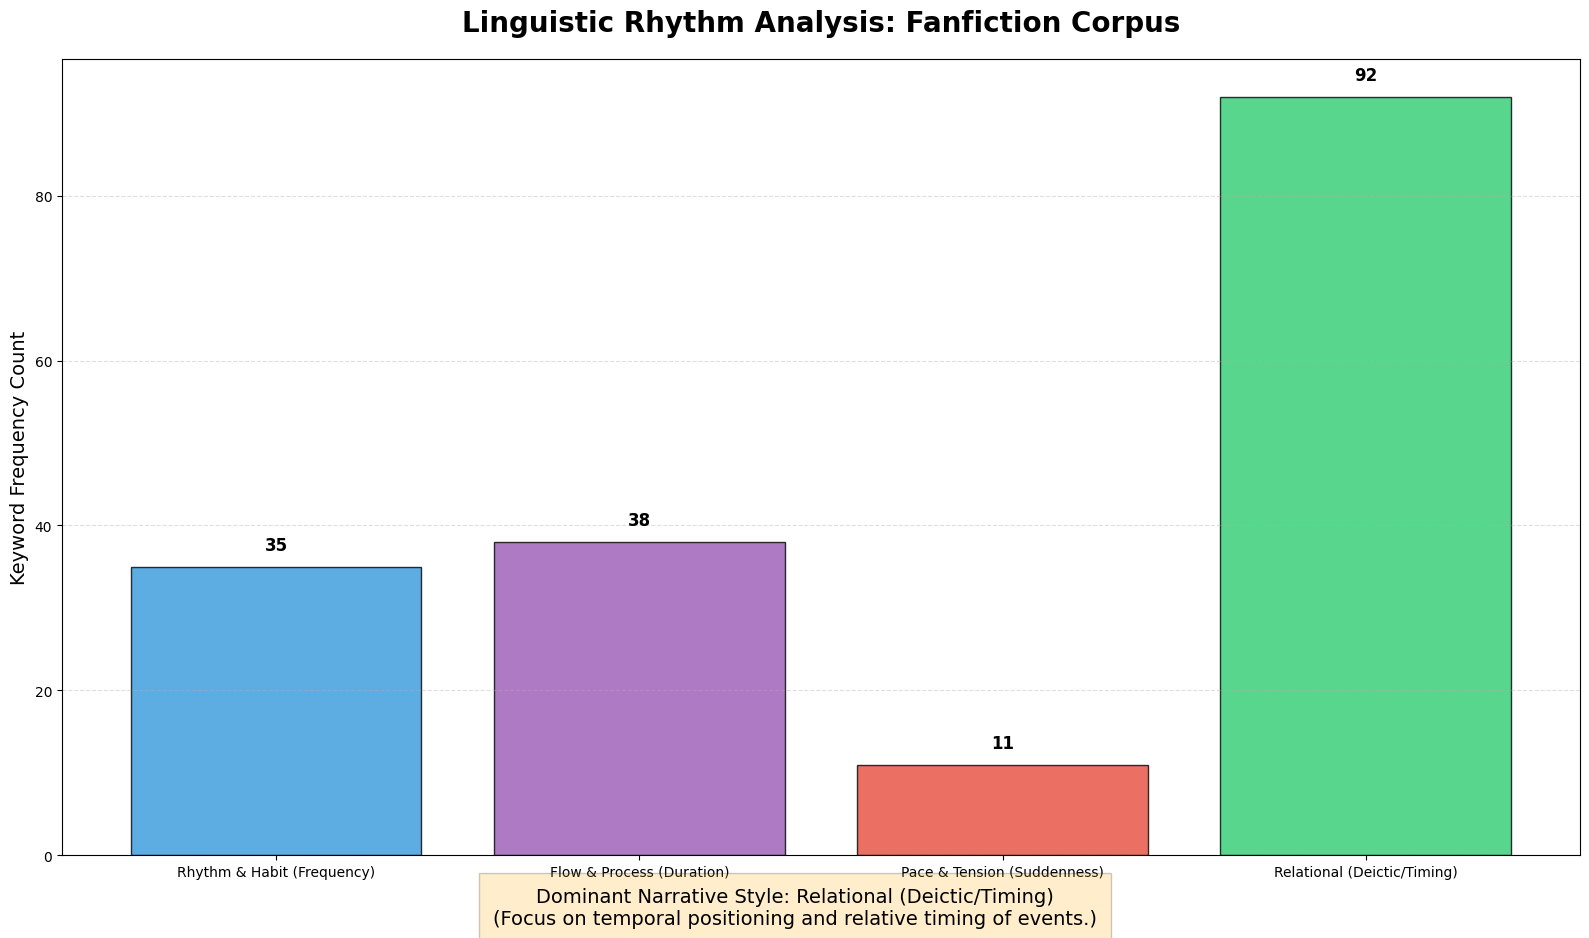

In [ ]:
import os
import re
import spacy
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Hazırlık
if not os.path.exists('/content/drive'): drive.mount('/content/drive')
try:
    nlp = spacy.load("en_core_web_md", disable=["ner", "parser"])
except:
    !python -m spacy download en_core_web_md
    nlp = spacy.load("en_core_web_md", disable=["ner", "parser"])

# --- YENİ LİNGUISTIC KÜMELEME SÖZLÜĞÜ ---
advanced_categories = {
    "Rhythm & Habit (Frequency)": [
        "occasionally", "seldom", "rarely", "at times", "from time to time",
        "periodically", "whenever", "once", "sometimes", "often"
    ],
    "Flow & Process (Duration)": [
        "gradually", "during", "since", "until", "meanwhile", "in the meantime",
        "as soon as", "shortly", "after a while", "for a long time"
    ],
    "Pace & Tension (Suddenness)": [
        "suddenly", "all of a sudden", "at that very moment", "not a moment too soon",
        "right after", "instantly", "abruptly"
    ],
    "Relational (Deictic/Timing)": [
        "formerly", "previously", "earlier", "tomorrow", "yesterday",
        "now", "presently", "soon", "in the past", "before long"
    ]
}

def run_advanced_rhythm_analysis():
    # Birleştirilmiş dosyayı oku
    COMBINED_FILE = '/content/drive/MyDrive/Text_files/Robinson/robinson_combined.txt'

    if not os.path.exists(COMBINED_FILE):
        print("Hata: fanfiction_all_texts.txt bulunamadı!")
        return

    with open(COMBINED_FILE, 'r', encoding='utf-8', errors='ignore') as f:
        text = f.read().lower()

    # Sayım Yap
    results = {}
    for cat, keywords in advanced_categories.items():
        count = 0
        for kw in keywords:
            # Tam kelime eşleşmesi için regex
            count += len(re.findall(rf'\b{re.escape(kw)}\b', text))
        results[cat] = count

    # --- DASHBOARD: LINGUISTIC RHYTHM ---
    plt.figure(figsize=(16, 10))

    # 1. Bar Chart: Genel Dağılım
    colors = ['#3498db', '#9b59b6', '#e74c3c', '#2ecc71']
    plt.bar(results.keys(), results.values(), color=colors, edgecolor='black', alpha=0.8)

    # Değerleri barların üzerine yaz
    for i, v in enumerate(results.values()):
        plt.text(i, v + 2, str(v), ha='center', fontweight='bold', fontsize=12)

    plt.title("Linguistic Rhythm Analysis: Fanfiction Corpus", fontsize=20, fontweight='bold', pad=20)
    plt.ylabel("Keyword Frequency Count", fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.4)

    # 2. Stilistik Yorum Ekleme
    max_cat = max(results, key=results.get)
    description = ""
    if "Suddenness" in max_cat:
        description = "Narrative is high-paced, focus on action and unexpected events."
    elif "Duration" in max_cat:
        description = "Narrative is descriptive, focus on atmosphere and processes."
    elif "Frequency" in max_cat:
        description = "Focus on habits, routines, and iterative character actions."
    else:
        description = "Focus on temporal positioning and relative timing of events."

    plt.figtext(0.5, 0.02, f"Dominant Narrative Style: {max_cat}\n({description})",
                ha="center", fontsize=14, bbox={"facecolor":"orange", "alpha":0.2, "pad":10})

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

# Analizi Başlat
run_advanced_rhythm_analysis()

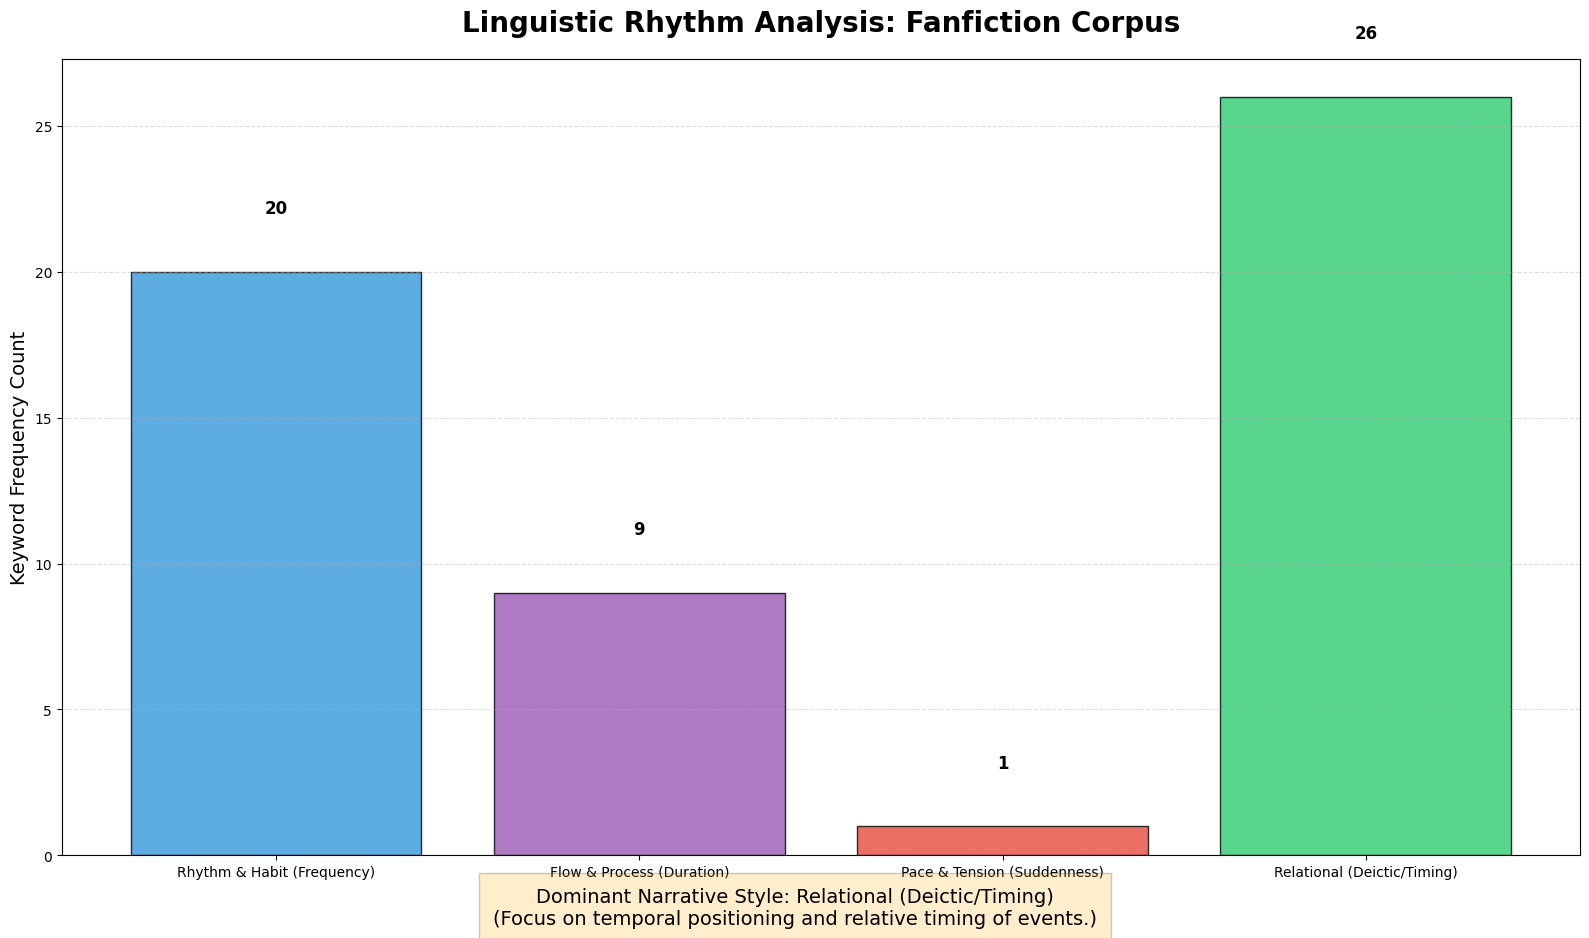

In [ ]:
import os
import re
import spacy
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Hazırlık
if not os.path.exists('/content/drive'): drive.mount('/content/drive')
try:
    nlp = spacy.load("en_core_web_md", disable=["ner", "parser"])
except:
    !python -m spacy download en_core_web_md
    nlp = spacy.load("en_core_web_md", disable=["ner", "parser"])

# --- YENİ LİNGUISTIC KÜMELEME SÖZLÜĞÜ ---
advanced_categories = {
    "Rhythm & Habit (Frequency)": [
        "occasionally", "seldom", "rarely", "at times", "from time to time",
        "periodically", "whenever", "once", "sometimes", "often"
    ],
    "Flow & Process (Duration)": [
        "gradually", "during", "since", "until", "meanwhile", "in the meantime",
        "as soon as", "shortly", "after a while", "for a long time"
    ],
    "Pace & Tension (Suddenness)": [
        "suddenly", "all of a sudden", "at that very moment", "not a moment too soon",
        "right after", "instantly", "abruptly"
    ],
    "Relational (Deictic/Timing)": [
        "formerly", "previously", "earlier", "tomorrow", "yesterday",
        "now", "presently", "soon", "in the past", "before long"
    ]
}

def run_advanced_rhythm_analysis():
    # Birleştirilmiş dosyayı oku
    COMBINED_FILE = '/content/drive/MyDrive/Text_files/LLM_Corpus/GPT-4_all_texts_combined.txt'

    if not os.path.exists(COMBINED_FILE):
        print("Hata: fanfiction_all_texts.txt bulunamadı!")
        return

    with open(COMBINED_FILE, 'r', encoding='utf-8', errors='ignore') as f:
        text = f.read().lower()

    # Sayım Yap
    results = {}
    for cat, keywords in advanced_categories.items():
        count = 0
        for kw in keywords:
            # Tam kelime eşleşmesi için regex
            count += len(re.findall(rf'\b{re.escape(kw)}\b', text))
        results[cat] = count

    # --- DASHBOARD: LINGUISTIC RHYTHM ---
    plt.figure(figsize=(16, 10))

    # 1. Bar Chart: Genel Dağılım
    colors = ['#3498db', '#9b59b6', '#e74c3c', '#2ecc71']
    plt.bar(results.keys(), results.values(), color=colors, edgecolor='black', alpha=0.8)

    # Değerleri barların üzerine yaz
    for i, v in enumerate(results.values()):
        plt.text(i, v + 2, str(v), ha='center', fontweight='bold', fontsize=12)

    plt.title("Linguistic Rhythm Analysis: Fanfiction Corpus", fontsize=20, fontweight='bold', pad=20)
    plt.ylabel("Keyword Frequency Count", fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.4)

    # 2. Stilistik Yorum Ekleme
    max_cat = max(results, key=results.get)
    description = ""
    if "Suddenness" in max_cat:
        description = "Narrative is high-paced, focus on action and unexpected events."
    elif "Duration" in max_cat:
        description = "Narrative is descriptive, focus on atmosphere and processes."
    elif "Frequency" in max_cat:
        description = "Focus on habits, routines, and iterative character actions."
    else:
        description = "Focus on temporal positioning and relative timing of events."

    plt.figtext(0.5, 0.02, f"Dominant Narrative Style: {max_cat}\n({description})",
                ha="center", fontsize=14, bbox={"facecolor":"orange", "alpha":0.2, "pad":10})

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

# Analizi Başlat
run_advanced_rhythm_analysis()

In [ ]:
import numpy as np
import re

def calculate_full_analysis(text, keywords):
    # 1. Tüm anahtar kelimelerin pozisyonlarını bul
    word_positions = []
    clean_text = text.lower()

    for w in keywords:
        for m in re.finditer(rf'\b{re.escape(w)}\b', clean_text):
            word_positions.append(m.start())

    # Sırala
    positions = sorted(word_positions)

    if len(positions) < 3:
        return 0, 0, 0

    # 2. Mesafeleri hesapla
    inter_event_distances = np.diff(positions)

    # 3. İstatistikler
    mu = np.mean(inter_event_distances)
    sigma = np.std(inter_event_distances)

    # 4. Burstiness (B)
    b_score = (sigma - mu) / (sigma + mu)

    return b_score, mu, sigma

# Kullanım:
b_score, m, s = calculate_full_analysis(text_raw, temporal_keywords)
print(f"Burstiness: {b_score:.4f}")

# Dosyayı oku ve text_raw değişkenine ata
with open('/content/drive/MyDrive/Text_files/fanfiction_all_texts.txt', 'r', encoding='utf-8') as f:
    text_raw = f.read()

# Şimdi fonksiyonu çağırabilirsin
b_score, m, s = calculate_full_analysis(text_raw, temporal_keywords)
print(f"✅ Analiz Tamamlandı!")
print(f"Burstiness Skoru: {b_score:.4f}")
print(f"Ortalama Mesafe: {m:.2f}")

NameError: name 'text_raw' is not defined

In [ ]:
import numpy as np
import re

# 1. Fonksiyonu Tanımla
def calculate_burstiness_final(text, keywords):
    word_positions = []
    clean_text = text.lower()

    # Kelimelerin geçtiği yerleri (karakter pozisyonu) bul
    for w in keywords:
        for m in re.finditer(rf'\b{re.escape(w)}\b', clean_text):
            word_positions.append(m.start())

    positions = sorted(word_positions)

    if len(positions) < 3:
        return None, 0, 0, 0

    # Olaylar arası mesafeler
    inter_event_distances = np.diff(positions)
    mu = np.mean(inter_event_distances)
    sigma = np.std(inter_event_distances)

    # Burstiness Formülü
    b_score = (sigma - mu) / (sigma + mu)

    return b_score, mu, sigma, len(positions)

# 2. Anahtar Kelimeleri Tanımla (Senin listenden)
temporal_keywords = ["at first", "at that moment", "at the beginning", "before", "after", "suddenly", "then", "soon", "finally", "eventually", "later", "now", "yesterday", "tomorrow", "meanwhile", "once", "when", "whenever"]

# 3. Dosyayı Oku ve Analiz Et
file_name = '/content/drive/MyDrive/Text_files/fanfiction_all_texts.txt'

try:
    with open(file_name, 'r', encoding='utf-8') as f:
        text_raw = f.read()

    b_score, m, s, count = calculate_burstiness_final(text_raw, temporal_keywords)

    if b_score is not None:
        print(f"📊 ANALİZ SONUÇLARI ({file_name})")
        print("-" * 40)
        print(f"✅ Toplam Zaman İfadesi: {count}")
        print(f"✅ Ortalama Mesafe (Karakter): {m:.2f}")
        print(f"✅ Standart Sapma: {s:.2f}")
        print(f"🚀 BURSTINESS SKORU (B): {b_score:.4f}")
        print("-" * 40)
        if b_score > 0:
            print("Yorum: Metin 'patlamalı' bir yapıda. Zaman ifadeleri belirli yerlerde kümelenmiş.")
        else:
            print("Yorum: Metin düzenli veya rastgele bir yapıda. Zaman ifadeleri dengeli dağılmış.")
    else:
        print("Hata: Metinde yeterli anahtar kelime bulunamadı.")

except FileNotFoundError:
    print(f"Hata: '{file_name}' dosyası bulunamadı. Lütfen dosya adının doğru olduğundan emin ol.")

📊 ANALİZ SONUÇLARI (/content/drive/MyDrive/Text_files/fanfiction_all_texts.txt)
----------------------------------------
✅ Toplam Zaman İfadesi: 2706
✅ Ortalama Mesafe (Karakter): 557.23
✅ Standart Sapma: 706.07
🚀 BURSTINESS SKORU (B): 0.1178
----------------------------------------
Yorum: Metin 'patlamalı' bir yapıda. Zaman ifadeleri belirli yerlerde kümelenmiş.


🚀 Üç dosya için analiz başlatılıyor...
✅ FanFiction (fanfiction_all_texts.txt) analiz edildi. Skor: 0.1168
✅ Robinson (robinson_combined.txt) analiz edildi. Skor: 0.0458
✅ GPT (gpt_4_1_all_texts_2025.txt) analiz edildi. Skor: 0.0285


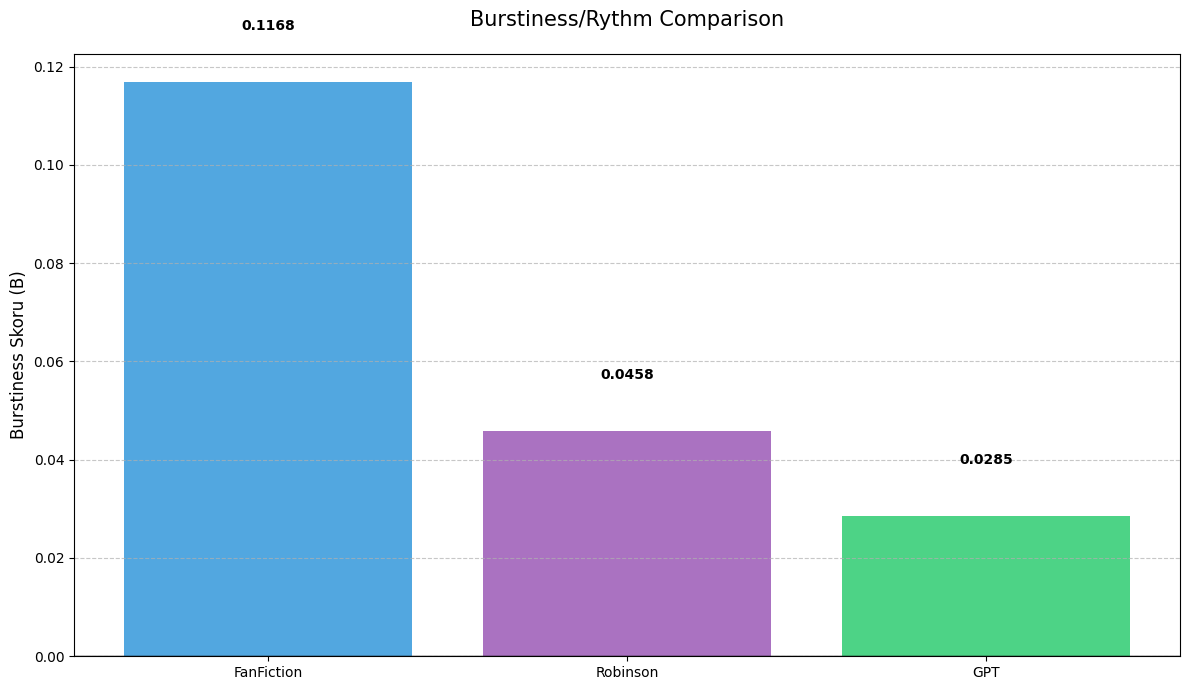

In [ ]:
import numpy as np
import re
import os
import matplotlib.pyplot as plt

# 1. Analiz Fonksiyonu
def calculate_burstiness(text, keywords):
    word_positions = []
    clean_text = text.lower()
    for w in keywords:
        for m in re.finditer(rf'\b{re.escape(w.lower())}\b', clean_text):
            word_positions.append(m.start())

    positions = sorted(word_positions)
    if len(positions) < 3:
        return 0

    inter_event_distances = np.diff(positions)
    mu = np.mean(inter_event_distances)
    sigma = np.std(inter_event_distances)

    # Burstiness Formülü: (sigma - mu) / (sigma + mu)
    return (sigma - mu) / (sigma + mu)

# 2. Senin Geniş Temporal Keyword Listen
temporal_keywords = ["at first", "before", "after", "suddenly", "then", "soon", "finally", "now", "when", "later", "meanwhile", "at that moment", "eventually"]

# 3. Screenshot'taki Dosya Yolları
base_path = '/content/drive/MyDrive/Text_files/'
files = {
    "FanFiction": "fanfiction_all_texts.txt",
    "Robinson": "robinson_combined.txt",
    "GPT": "gpt_4_1_all_texts_2025.txt"
}

results = {}

# 4. Döngüyle Analiz
print("🚀 Üç dosya için analiz başlatılıyor...")
for label, f_name in files.items():
    full_path = os.path.join(base_path, f_name)
    if os.path.exists(full_path):
        with open(full_path, 'r', encoding='utf-8', errors='ignore') as f:
            content = f.read()
            score = calculate_burstiness(content, temporal_keywords)
            results[label] = score
            print(f"✅ {label} ({f_name}) analiz edildi. Skor: {score:.4f}")
    else:
        print(f"❌ Hata: {f_name} yolu bulunamadı! Lütfen Drive'ı kontrol et.")

# 5. Görselleştirme
if results:
    plt.figure(figsize=(12, 7))
    colors = ['#3498db', '#9b59b6', '#2ecc71'] # Mavi, Mor, Yeşil

    bars = plt.bar(results.keys(), results.values(), color=colors, alpha=0.85)

    plt.axhline(0, color='black', linewidth=1)
    plt.title('Burstiness/Rythm Comparison', fontsize=15, pad=20)
    plt.ylabel('Burstiness Skoru (B)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Skorları barların üzerine ekle
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + (0.01 if yval > 0 else -0.02),
                 f'{yval:.4f}', ha='center', va='bottom' if yval > 0 else 'top', fontweight='bold')

    plt.tight_layout()
    plt.show()